In [1]:
#!/usr/bin/env python3

import os
import re
import csv
import subprocess
import pandas as pd

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
NUCMER_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/containment_mm2/nucmer"
GRAPH_DIR = os.path.join(NUCMER_DIR, "graph_cov90_noclose")
CONTAINMENT_FILE = os.path.join(GRAPH_DIR, "containment_NUC_levelup_strictlen.tsv")

PLASMID_FASTA_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/raw_fastas"
SAMTOOLS = "/home/nacho/mambaforge/envs/samtools/bin/samtools"

WINDOW_HW = 1000

OUTDIR = os.path.join(BASE_DIR, f"TRACEABLE_hyper_{WINDOW_HW}")
WINDOWS_DIR = os.path.join(OUTDIR, "windows")
MASTER_TSV = os.path.join(OUTDIR, "breakpoints_master.tsv")
MULTIFASTA = os.path.join(OUTDIR, "breakpoints_windows.fa")

os.makedirs(WINDOWS_DIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def parse_cov90_line(line):
    toks = re.split(r"\s+", line.strip())
    if len(toks) < 14:
        return None
    try:
        return {
            "s1": int(toks[0]),
            "e1": int(toks[1]),
            "s2": int(toks[2]),
            "e2": int(toks[3]),
            "len1": int(toks[4]),
            "len2": int(toks[5]),
            "lenR": int(toks[7]),
            "lenQ": int(toks[8]),
            "ref": toks[11],
            "qry": toks[12],
            "raw": line.strip()
        }
    except Exception:
        return None

def get_cov90_path(src):
    p1 = os.path.join(NUCMER_DIR, src)
    if os.path.exists(p1):
        return p1
    p2 = os.path.join(GRAPH_DIR, os.path.basename(src))
    if os.path.exists(p2):
        return p2
    raise FileNotFoundError(f"No encuentro cov90 para: {src}")

def get_fasta_path(chrom):
    for fname in os.listdir(PLASMID_FASTA_DIR):
        if fname.endswith((".fna", ".fa", ".fasta")) and fname.startswith(chrom):
            return os.path.join(PLASMID_FASTA_DIR, fname)
    return None

def get_length_from_fasta(fasta):
    fai = fasta + ".fai"
    if not os.path.exists(fai):
        subprocess.run([SAMTOOLS, "faidx", fasta], check=True)
    with open(fai) as f:
        return int(f.readline().split("\t")[1])

def circular_window(center, L, hw):
    start = center - hw
    end = center + hw

    if start >= 1 and end <= L:
        return [(start, end)]

    if start < 1:
        return [(L + start + 1, L), (1, end)]

    if end > L:
        return [(start, L), (1, end - L)]

    return None

def fetch_sequence(fasta, chrom, parts):
    seq = []
    for s, e in parts:
        region = f"{chrom}:{s}-{e}"
        out = subprocess.check_output([SAMTOOLS, "faidx", fasta, region]).decode()
        seq.append("".join(out.split("\n")[1:]))
    return "".join(seq)

# ============================================================
# MAIN
# ============================================================

rows = []
pair_id = 0
bp_index = 0

with open(CONTAINMENT_FILE) as f:
    rdr = csv.DictReader(f, delimiter="\t")
    for row in rdr:
        big_len = int(row["big_len"])
        cov_path = get_cov90_path(row["source_file"])

        found = False
        with open(cov_path) as fh:
            for lineno, line in enumerate(fh, 1):
                parsed = parse_cov90_line(line)
                if not parsed:
                    continue

                if parsed["lenR"] == big_len:
                    chrom = parsed["ref"]
                    s = min(parsed["s1"], parsed["e1"])
                    e = max(parsed["s1"], parsed["e1"])
                elif parsed["lenQ"] == big_len:
                    chrom = parsed["qry"]
                    s = min(parsed["s2"], parsed["e2"])
                    e = max(parsed["s2"], parsed["e2"])
                else:
                    continue

                fasta = get_fasta_path(chrom)
                if fasta is None:
                    print(f"[WARN] No FASTA for {chrom}")
                    break

                real_L = get_length_from_fasta(fasta)

                # start breakpoint
                for bp_kind, pos in [("start", s), ("end", e)]:
                    parts = circular_window(pos, real_L, WINDOW_HW)
                    if not parts:
                        continue

                    seq = fetch_sequence(fasta, chrom, parts)

                    header = (
                        f"pair={pair_id}|bp={bp_index}|plasmid={chrom}"
                        f"|kind={bp_kind}|pos={pos}|hw={WINDOW_HW}"
                    )

                    fa_path = os.path.join(WINDOWS_DIR, f"bp_{bp_index}.fa")
                    with open(fa_path, "w") as out:
                        out.write(f">{header}\n{seq}\n")

                    rows.append({
                        "pair_id": pair_id,
                        "bp_index": bp_index,
                        "plasmid": chrom,
                        "breakpoint_pos": pos,
                        "bp_kind": bp_kind,
                        "plasmid_len": real_L,
                        "window_hw": WINDOW_HW,
                        "source_file": row["source_file"],
                        "containment_query": row["query_id"],
                        "containment_target": row["target_id"],
                        "cov_line_number": lineno,
                        "fasta_header": header,
                        "fasta_path": fa_path,
                    })

                    bp_index += 1

                pair_id += 1
                found = True
                break

        if not found:
            print(f"[WARN] No valid alignment found for {row['query_id']} vs {row['target_id']} in {cov_path}")

# ============================================================
# SAVE MASTER TABLE
# ============================================================

master = pd.DataFrame(rows)
master.to_csv(MASTER_TSV, sep="\t", index=False)

# ============================================================
# SAVE MULTIFASTA
# ============================================================

with open(MULTIFASTA, "w") as out:
    for _, r in master.sort_values("bp_index").iterrows():
        with open(r["fasta_path"]) as f:
            out.write(f.read())

print("Done.")
print("Breakpoints:", len(master))
print("Pairs:", master["pair_id"].nunique())
print("Wrote:", MASTER_TSV)
print("Wrote:", MULTIFASTA)
print("Windows dir:", WINDOWS_DIR)
print("\nCheck:")
print(master.head())

Done.
Breakpoints: 3234
Pairs: 1617
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/breakpoints_master.tsv
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/breakpoints_windows.fa
Windows dir: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/windows

Check:
   pair_id  bp_index        plasmid  breakpoint_pos bp_kind  plasmid_len  \
0        0         0  NZ_CP068038.1               1   start         5597   
1        0         1  NZ_CP068038.1            5190     end         5597   
2        1         2  NZ_CP017798.1           92937   start       171477   
3        1         3  NZ_CP017798.1           94923     end       171477   
4        2         4  NZ_CP018827.1            5112   start       259837   

   window_hw              source_file containment_query containment_target  \
0       1000  level1_vs_gt1.cov90.tsv        AP024697.1      NZ_CP068038.1  

In [3]:
#!/usr/bin/env python3

import os
import subprocess
import pandas as pd
from multiprocessing import Pool, cpu_count

# ============================================================
# CONFIG
# ============================================================

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000"
MASTER_TSV = os.path.join(BASE, "breakpoints_master.tsv")
OUTDIR = os.path.join(BASE, "pairwise_blast")
OUT_TSV = os.path.join(BASE, "pairwise_hits.tsv")

BLASTN = "/home/nacho/mambaforge/envs/blast/bin/blastn"
N_CORES = max(1, cpu_count() - 2)

OUTFMT = "6 qseqid sseqid qstart qend sstart send length pident mismatch gapopen evalue bitscore"

os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def run_one(job):
    pair_id, plasmid, fa_start, fa_end, start_header, end_header, bp_start, bp_end = job

    out_file = os.path.join(OUTDIR, f"pair_{pair_id:05d}.blast.tsv")

    cmd = [
        BLASTN,
        "-query", fa_start,
        "-subject", fa_end,
        "-task", "blastn",
        "-dust", "no",
        "-soft_masking", "false",
        "-outfmt", OUTFMT
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        return [{
            "pair_id": pair_id,
            "plasmid": plasmid,
            "bp_start_index": bp_start,
            "bp_end_index": bp_end,
            "start_header": start_header,
            "end_header": end_header,
            "status": "error",
            "qseqid": None,
            "sseqid": None,
            "qstart": None,
            "qend": None,
            "sstart": None,
            "send": None,
            "length": None,
            "pident": None,
            "mismatch": None,
            "gapopen": None,
            "evalue": None,
            "bitscore": None,
            "blast_file": out_file,
            "stderr": result.stderr.strip()
        }]

    with open(out_file, "w") as f:
        f.write(result.stdout)

    rows = []
    if result.stdout.strip():
        for line in result.stdout.strip().split("\n"):
            toks = line.split("\t")
            rows.append({
                "pair_id": pair_id,
                "plasmid": plasmid,
                "bp_start_index": bp_start,
                "bp_end_index": bp_end,
                "start_header": start_header,
                "end_header": end_header,
                "status": "ok",
                "qseqid": toks[0],
                "sseqid": toks[1],
                "qstart": int(toks[2]),
                "qend": int(toks[3]),
                "sstart": int(toks[4]),
                "send": int(toks[5]),
                "length": int(toks[6]),
                "pident": float(toks[7]),
                "mismatch": int(toks[8]),
                "gapopen": int(toks[9]),
                "evalue": toks[10],
                "bitscore": float(toks[11]),
                "blast_file": out_file,
                "stderr": ""
            })
    else:
        rows.append({
            "pair_id": pair_id,
            "plasmid": plasmid,
            "bp_start_index": bp_start,
            "bp_end_index": bp_end,
            "start_header": start_header,
            "end_header": end_header,
            "status": "ok",
            "qseqid": None,
            "sseqid": None,
            "qstart": None,
            "qend": None,
            "sstart": None,
            "send": None,
            "length": None,
            "pident": None,
            "mismatch": None,
            "gapopen": None,
            "evalue": None,
            "bitscore": None,
            "blast_file": out_file,
            "stderr": ""
        })

    return rows

# ============================================================
# LOAD MASTER
# ============================================================

m = pd.read_csv(MASTER_TSV, sep="\t")

# sanity
counts = m.groupby("pair_id").size()
if not (counts == 2).all():
    raise ValueError("Hay pair_id que no tienen exactamente 2 ventanas.")

# separar start / end
m_start = m[m["bp_kind"] == "start"].copy()
m_end = m[m["bp_kind"] == "end"].copy()

pairs = m_start.merge(
    m_end,
    on=["pair_id", "plasmid"],
    suffixes=("_start", "_end")
)

print("Pairs to BLAST:", len(pairs))
print(pairs[["pair_id", "plasmid", "bp_index_start", "bp_index_end"]].head())

# ============================================================
# BUILD JOBS
# ============================================================

jobs = []
for _, r in pairs.iterrows():
    jobs.append((
        int(r["pair_id"]),
        r["plasmid"],
        r["fasta_path_start"],
        r["fasta_path_end"],
        r["fasta_header_start"],
        r["fasta_header_end"],
        int(r["bp_index_start"]),
        int(r["bp_index_end"]),
    ))

# ============================================================
# RUN BLAST
# ============================================================

print(f"Running {len(jobs)} jobs on {N_CORES} cores...")

all_rows = []
with Pool(N_CORES) as pool:
    for res in pool.map(run_one, jobs):
        all_rows.extend(res)

df = pd.DataFrame(all_rows)
df.to_csv(OUT_TSV, sep="\t", index=False)

print("Done.")
print("Wrote:", OUT_TSV)

print("\nStatus summary:")
print(df["status"].value_counts(dropna=False))

print("\nExample hits:")
print(df.head())

Pairs to BLAST: 1617
   pair_id        plasmid  bp_index_start  bp_index_end
0        0  NZ_CP068038.1               0             1
1        1  NZ_CP017798.1               2             3
2        2  NZ_CP018827.1               4             5
3        3  NZ_CP023800.1               6             7
4        4  NZ_CP096212.1               8             9
Running 1617 jobs on 30 cores...
Done.
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/pairwise_hits.tsv

Status summary:
status
ok    10517
Name: count, dtype: int64

Example hits:
   pair_id        plasmid  bp_start_index  bp_end_index  \
0        0  NZ_CP068038.1               0             1   
1        0  NZ_CP068038.1               0             1   
2        0  NZ_CP068038.1               0             1   
3        0  NZ_CP068038.1               0             1   
4        0  NZ_CP068038.1               0             1   

                                        start_header  \
0  

In [4]:

import os
import pandas as pd
from Bio import SeqIO

# ============================================================
# CONFIG
# ============================================================

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000"

MASTER_TSV = os.path.join(BASE, "breakpoints_master.tsv")
PAIRWISE_HITS = os.path.join(BASE, "pairwise_hits.tsv")

OUT_TSV = os.path.join(BASE, "homologous_tracts.tsv")
OUT_FASTA = os.path.join(BASE, "homologous_tracts.fa")

# filtros iniciales
MIN_LEN = 100
MIN_PID = 95.0

# ============================================================
# LOAD INPUTS
# ============================================================

master = pd.read_csv(MASTER_TSV, sep="\t")
hits = pd.read_csv(PAIRWISE_HITS, sep="\t")

# quedarse solo con hits reales
hits = hits[
    hits["length"].notna() &
    (hits["length"] >= MIN_LEN) &
    (hits["pident"] >= MIN_PID)
].copy()

hits["length"] = hits["length"].astype(int)
hits["qstart"] = hits["qstart"].astype(int)
hits["qend"] = hits["qend"].astype(int)
hits["sstart"] = hits["sstart"].astype(int)
hits["send"] = hits["send"].astype(int)

print("Filtered hits:", len(hits))

# ============================================================
# FASTA CACHE
# ============================================================

seq_cache = {}

def load_seq(fasta_path):
    if fasta_path not in seq_cache:
        rec = next(SeqIO.parse(fasta_path, "fasta"))
        seq_cache[fasta_path] = str(rec.seq)
    return seq_cache[fasta_path]

# ============================================================
# MAP bp_index -> fasta_path / metadata
# ============================================================

bp_meta = master.set_index("bp_index").to_dict(orient="index")

# ============================================================
# EXTRACT HOMOLOGOUS TRACTS
# ============================================================

rows = []
fasta_records = []

tract_id = 0

for _, r in hits.iterrows():
    bp_start = int(r["bp_start_index"])
    bp_end = int(r["bp_end_index"])

    meta_start = bp_meta[bp_start]
    meta_end = bp_meta[bp_end]

    seq_start_full = load_seq(meta_start["fasta_path"])
    seq_end_full = load_seq(meta_end["fasta_path"])

    # coords en query/start window
    q1, q2 = sorted([int(r["qstart"]), int(r["qend"])])
    # coords en subject/end window
    s1, s2 = sorted([int(r["sstart"]), int(r["send"])])

    seq_start = seq_start_full[q1-1:q2]
    seq_end = seq_end_full[s1-1:s2]

    tract_name = (
        f"tract={tract_id}|pair={int(r['pair_id'])}|plasmid={r['plasmid']}"
        f"|bp_start={bp_start}|bp_end={bp_end}|len={int(r['length'])}|pid={r['pident']:.3f}"
    )

    rows.append({
        "tract_id": tract_id,
        "pair_id": int(r["pair_id"]),
        "plasmid": r["plasmid"],
        "bp_start_index": bp_start,
        "bp_end_index": bp_end,
        "bp_start_pos": meta_start["breakpoint_pos"],
        "bp_end_pos": meta_end["breakpoint_pos"],
        "qstart": q1,
        "qend": q2,
        "sstart": s1,
        "send": s2,
        "length": int(r["length"]),
        "pident": float(r["pident"]),
        "bitscore": float(r["bitscore"]),
        "seq_start": seq_start,
        "seq_end": seq_end,
        "start_header": r["start_header"],
        "end_header": r["end_header"],
        "tract_name": tract_name,
    })

    fasta_records.append(f">{tract_name}|side=start\n{seq_start}\n")
    fasta_records.append(f">{tract_name}|side=end\n{seq_end}\n")

    tract_id += 1

tracts = pd.DataFrame(rows)
tracts.to_csv(OUT_TSV, sep="\t", index=False)

with open(OUT_FASTA, "w") as f:
    for rec in fasta_records:
        f.write(rec)

print("Done.")
print("Tracts:", len(tracts))
print("Wrote:", OUT_TSV)
print("Wrote:", OUT_FASTA)

print("\nExample:")
print(tracts.head())

Filtered hits: 908
Done.
Tracts: 908
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/homologous_tracts.tsv
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/homologous_tracts.fa

Example:
   tract_id  pair_id        plasmid  bp_start_index  bp_end_index  \
0         0        0  NZ_CP068038.1               0             1   
1         1        1  NZ_CP017798.1               2             3   
2         2        4  NZ_CP096212.1               8             9   
3         3        4  NZ_CP096212.1               8             9   
4         4        5     AP027448.1              10            11   

   bp_start_pos  bp_end_pos  qstart  qend  sstart  send  length  pident  \
0             1        5190       1  1592     410  2001    1592   100.0   
1         92937       94923       1   791    1021  1811     791   100.0   
2        235981      237978     192  1001    1001  1810     810   100.0   
3    

In [5]:
import pandas as pd

tracts = pd.read_csv("/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/homologous_tracts.tsv", sep="\t")

print(tracts.head())
print(tracts["length"].describe())

print("\nPair 58:")
print(tracts[tracts["pair_id"] == 58][["pair_id","plasmid","length","pident","seq_start","seq_end"]].head())

print("\nPair 250:")
print(tracts[tracts["pair_id"] == 250][["pair_id","plasmid","length","pident","seq_start","seq_end"]].head())

print("\nPair 920:")
print(tracts[tracts["pair_id"] == 920][["pair_id","plasmid","length","pident","seq_start","seq_end"]].head())

   tract_id  pair_id        plasmid  bp_start_index  bp_end_index  \
0         0        0  NZ_CP068038.1               0             1   
1         1        1  NZ_CP017798.1               2             3   
2         2        4  NZ_CP096212.1               8             9   
3         3        4  NZ_CP096212.1               8             9   
4         4        5     AP027448.1              10            11   

   bp_start_pos  bp_end_pos  qstart  qend  sstart  send  length  pident  \
0             1        5190       1  1592     410  2001    1592   100.0   
1         92937       94923       1   791    1021  1811     791   100.0   
2        235981      237978     192  1001    1001  1810     810   100.0   
3        235981      237978       1   193    1274  1466     193   100.0   
4             1       14578       1  1163     839  2001    1163   100.0   

   bitscore                                          seq_start  \
0    2872.0  TTGCTAATGTTAATTCAATAACATATAAAGAGGTGTTTAATCTAAT...   
1 

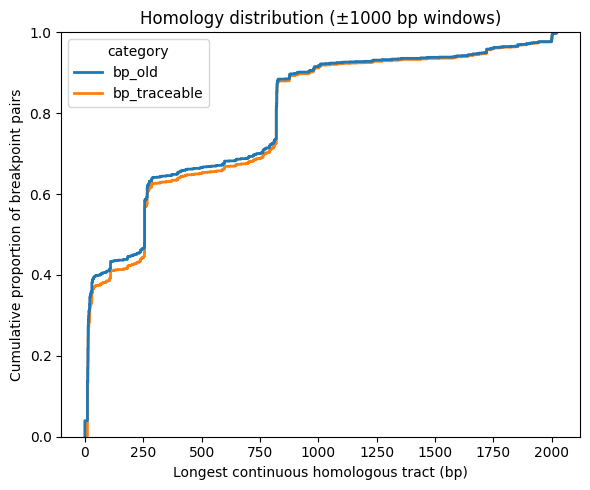

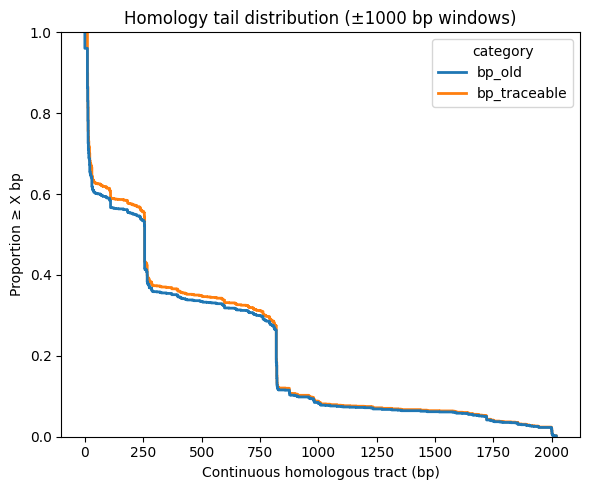


Old bp summary:
count    1617.000000
mean      413.043290
std       504.285963
min         0.000000
25%        14.000000
50%       256.000000
75%       820.000000
max      2020.000000
Name: best_len, dtype: float64

New traceable bp summary:
count    1553.000000
mean      430.065035
std       507.411011
min        11.000000
25%        15.000000
50%       256.000000
75%       820.000000
max      2020.000000
Name: best_len, dtype: float64


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# INPUTS
# ============================================================

TRACEABLE_HITS = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/pairwise_hits.tsv"
OLD_SUMMARY = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/ALIGNBREAKPOINTS/FULL_hyper_blast_bestlen_summary.tsv"

hw = 1000
min_len = 0  # si quieres filtrar, por ejemplo 100

# ============================================================
# 1. NEW PIPELINE: BEST LEN PER PAIR
# ============================================================

new = pd.read_csv(TRACEABLE_HITS, sep="\t")

new = new[
    new["length"].notna() &
    (new["status"] == "ok")
].copy()

new["length"] = pd.to_numeric(new["length"], errors="coerce")
new["pident"] = pd.to_numeric(new["pident"], errors="coerce")

if min_len > 0:
    new = new[new["length"] >= min_len].copy()

new_best = (
    new.groupby("pair_id", as_index=False)
       .agg(
           best_len=("length", "max"),
           best_pident=("pident", "max")
       )
)

new_best["category"] = "bp_traceable"

# ============================================================
# 2. OLD PIPELINE: BP ONLY, SAME WINDOW
# ============================================================

old = pd.read_csv(OLD_SUMMARY, sep="\t")
old = old[(old["window_hw"] == hw) & (old["category"] == "bp")].copy()
old["category"] = "bp_old"

# ============================================================
# 3. COMBINE
# ============================================================

plot_df = pd.concat([
    old[["best_len", "category"]],
    new_best[["best_len", "category"]]
], ignore_index=True)

# ============================================================
# 4. ECDF
# ============================================================

plt.figure(figsize=(6,5))

sns.ecdfplot(
    data=plot_df,
    x="best_len",
    hue="category",
    linewidth=2
)

plt.xlabel("Longest continuous homologous tract (bp)")
plt.ylabel("Cumulative proportion of breakpoint pairs")
plt.title(f"Homology distribution (±{hw} bp windows)")
plt.tight_layout()
plt.show()

# ============================================================
# 5. TAIL ECDF
# ============================================================

plt.figure(figsize=(6,5))

sns.ecdfplot(
    data=plot_df,
    x="best_len",
    hue="category",
    complementary=True,
    linewidth=2
)

plt.xlabel("Continuous homologous tract (bp)")
plt.ylabel("Proportion ≥ X bp")
plt.title(f"Homology tail distribution (±{hw} bp windows)")
plt.tight_layout()
plt.show()

# ============================================================
# 6. QUICK NUMERIC CHECK
# ============================================================

print("\nOld bp summary:")
print(old["best_len"].describe())

print("\nNew traceable bp summary:")
print(new_best["best_len"].describe())

In [8]:
import re
import pandas as pd

CLSTR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/homologous_tracts_cdhit_95.fa.clstr"

rows = []
cluster_id = None

with open(CLSTR) as f:
    for line in f:
        line = line.strip()

        if line.startswith(">Cluster"):
            cluster_id = int(line.split()[1])
            continue

        m = re.search(r">(.+?)\.\.\.", line)
        if not m:
            continue

        header = m.group(1)

        # parse fields
        tract = re.search(r"tract=(\d+)", header)
        pair = re.search(r"pair=(\d+)", header)
        plasmid = re.search(r"plasmid=([^|]+)", header)
        side = re.search(r"side=(\w+)", header)

        rows.append({
            "cluster": cluster_id,
            "tract_id": int(tract.group(1)) if tract else None,
            "pair_id": int(pair.group(1)) if pair else None,
            "plasmid": plasmid.group(1) if plasmid else None,
            "side": side.group(1) if side else None,
        })

cl = pd.DataFrame(rows)

# tamaños
cluster_sizes = (
    cl.groupby("cluster")
      .size()
      .sort_values(ascending=False)
      .reset_index(name="n")
)

print(cluster_sizes.head(10))

   cluster    n
0       73  602
1      105  410
2      101  124
3       94   60
4       78   58
5       75   58
6      120   24
7       67   24
8       18   24
9        1   20


In [10]:
valid_pairs = check[check["n_sides"] == 2][["cluster", "pair_id"]]

cl_valid = cl.merge(valid_pairs, on=["cluster", "pair_id"])

In [11]:
cluster_plasmid = (
    cl_valid[["cluster", "plasmid", "pair_id"]]
    .drop_duplicates()
)

cluster_sizes_clean = (
    cluster_plasmid.groupby("cluster")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="n_pairs")
)

print(cluster_sizes_clean.head(10))

   cluster  n_pairs
0       73      268
1      105      205
2      101       62
3       94       30
4       75       25
5       78       25
6       18       12
7      120       12
8       67       12
9        1       10


In [12]:
# unir cluster con tracts
cl_len = cl_valid.merge(
    tracts[["tract_id", "pair_id", "length"]],
    on=["tract_id", "pair_id"],
    how="left"
)

# resumen por cluster
cluster_len = (
    cl_len.groupby("cluster")["length"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
    .sort_values("count", ascending=False)
)

print(cluster_len.head(10))

     cluster  count         mean  median   min   max
70        73    602   745.169435   820.0   108   829
102      105    410   257.043902   256.0   253   292
98       101    124   270.241935   267.0   244   352
91        94     60   133.800000   110.0   110   467
72        75     58   636.448276   775.0   193   825
75        78     58   613.551724   648.0   137   803
18        18     24   810.083333   814.0   505  1941
117      120     24   118.666667   106.5   106   180
64        67     24   981.750000   982.0   980   983
1          1     20  2001.000000  2001.0  2001  2001


In [14]:
import pandas as pd

# ------------------------------------------
# CONFIG
# ------------------------------------------

TOP_N = 10
OUT_LIST = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/top_clusters_plasmids.list"

# ------------------------------------------
# TOP CLUSTERS
# ------------------------------------------

top_clusters = cluster_sizes.head(TOP_N)["cluster"].tolist()

print("Top clusters:", top_clusters)

# ------------------------------------------
# PLASMIDS IN TOP CLUSTERS
# ------------------------------------------

top_plasmids = (
    cl[cl["cluster"].isin(top_clusters)]["plasmid"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("N plasmids:", len(top_plasmids))
print(top_plasmids[:20])

# ------------------------------------------
# SAVE LIST
# ------------------------------------------

with open(OUT_LIST, "w") as f:
    for p in top_plasmids:
        f.write(p + "\n")

print("Written:", OUT_LIST)

Top clusters: [73, 105, 101, 94, 78, 75, 120, 67, 18, 1]
N plasmids: 425
['AP022086.1', 'CP011314.1', 'CP027485.1', 'CP030425.1', 'CP030690.1', 'CP031284.1', 'CP035776.1', 'CP040445.1', 'CP048414.1', 'CP048861.1', 'CP049455.1', 'CP049466.1', 'CP049469.1', 'CP049992.1', 'CP049995.1', 'CP050000.1', 'CP050006.1', 'CP050008.1', 'CP050278.1', 'CP050282.1']
Written: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/top_clusters_plasmids.list


In [15]:
import os
import pandas as pd

# ============================================================
# INPUTS
# ============================================================

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000"
TRACTS_FILE = f"{BASE}/homologous_tracts.tsv"
BAKTA_DIR = f"{BASE}/full_plasmids_for_bakta/bakta_results"
OUT_TSV = f"{BASE}/top3_clusters_window_context.tsv"

TOP_N = 3
N_NEIGH = 5

# ============================================================
# LOAD TRACTS
# ============================================================

tracts = pd.read_csv(TRACTS_FILE, sep="\t")

# ============================================================
# TOP 3 CLUSTERS
# ============================================================

top_clusters = cluster_sizes.head(TOP_N)["cluster"].tolist()
print("Top clusters:", top_clusters)

cl_top = cl[cl["cluster"].isin(top_clusters)].copy()

# nos quedamos con una fila por cluster-tract-pair-plasmid
cl_top = cl_top.drop_duplicates(["cluster", "tract_id", "pair_id", "plasmid"])

# unir con tabla de tracts
x = cl_top.merge(
    tracts,
    on=["tract_id", "pair_id", "plasmid"],
    how="left"
)

# ============================================================
# HELPERS
# ============================================================

def parse_attrs(attr):
    d = {}
    for item in str(attr).split(";"):
        if "=" in item:
            k, v = item.split("=", 1)
            d[k] = v
    return d

def load_gff3(gff_path):
    rows = []
    with open(gff_path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) != 9:
                continue
            seqid, source, feature, start, end, score, strand, phase, attrs = parts
            attrs_d = parse_attrs(attrs)
            rows.append({
                "seqid": seqid,
                "feature": feature,
                "start": int(start),
                "end": int(end),
                "strand": strand,
                "gene": attrs_d.get("gene", ""),
                "product": attrs_d.get("product", ""),
                "locus_tag": attrs_d.get("locus_tag", ""),
            })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df = df[df["feature"].str.lower() == "cds"].copy()
    return df.sort_values("start").reset_index(drop=True)

def overlap_len(a1, a2, b1, b2):
    s = max(a1, b1)
    e = min(a2, b2)
    return max(0, e - s + 1)

def annotate_region(hit_start, hit_end, cds, n_neigh=5):
    cds = cds.copy()

    cds["overlap_bp"] = cds.apply(
        lambda r: overlap_len(hit_start, hit_end, r["start"], r["end"]),
        axis=1
    )

    ov = cds[cds["overlap_bp"] > 0].sort_values("overlap_bp", ascending=False)

    out = {
        "context": "",
        "gene": "",
        "product": "",
        "locus_tag": "",
        "overlap_bp": 0,
        "left_context": "",
        "right_context": "",
    }

    if not ov.empty:
        best = ov.iloc[0]
        full_inside = (hit_start >= best["start"]) and (hit_end <= best["end"])
        out["context"] = "inside_CDS" if full_inside else "overlap_CDS"
        out["gene"] = best["gene"]
        out["product"] = best["product"]
        out["locus_tag"] = best["locus_tag"]
        out["overlap_bp"] = int(best["overlap_bp"])

        idx = cds.index.get_loc(best.name)
    else:
        out["context"] = "intergenic"
        right_idx = cds[cds["start"] > hit_end].index.min()

        if pd.isna(right_idx):
            idx = len(cds) - 1
        else:
            idx = cds.index.get_loc(right_idx)

    left = cds.iloc[max(0, idx - n_neigh):idx]
    right = cds.iloc[idx+1:idx+1+n_neigh]

    out["left_context"] = "; ".join(
        (r["gene"] or r["locus_tag"]) + "|" + r["product"]
        for _, r in left.iterrows()
    )
    out["right_context"] = "; ".join(
        (r["gene"] or r["locus_tag"]) + "|" + r["product"]
        for _, r in right.iterrows()
    )

    return out

# ============================================================
# ANNOTATE EACH TRACT IN EACH WINDOW
# ============================================================

rows = []

for _, r in x.iterrows():
    plasmid = r["plasmid"]
    gff_path = os.path.join(BAKTA_DIR, plasmid, f"{plasmid}.gff3")

    if not os.path.exists(gff_path):
        continue

    cds = load_gff3(gff_path)
    if cds.empty:
        continue

    # coordenadas en el plásmido para la copia de la ventana start
    start_hit_start = int(r["bp_start_pos"] + r["qstart"] - 1)
    start_hit_end   = int(r["bp_start_pos"] + r["qend"] - 1)

    # coordenadas en el plásmido para la copia de la ventana end
    end_hit_start = int(r["bp_end_pos"] + r["sstart"] - 1)
    end_hit_end   = int(r["bp_end_pos"] + r["send"] - 1)

    start_ann = annotate_region(start_hit_start, start_hit_end, cds, n_neigh=N_NEIGH)
    end_ann   = annotate_region(end_hit_start, end_hit_end, cds, n_neigh=N_NEIGH)

    rows.append({
        "cluster": r["cluster"],
        "tract_id": r["tract_id"],
        "pair_id": r["pair_id"],
        "plasmid": plasmid,
        "tract_len": r["length"],
        "pident": r["pident"],

        "start_hit_start": start_hit_start,
        "start_hit_end": start_hit_end,
        "start_context": start_ann["context"],
        "start_gene": start_ann["gene"],
        "start_product": start_ann["product"],
        "start_locus_tag": start_ann["locus_tag"],
        "start_overlap_bp": start_ann["overlap_bp"],
        "start_left_context": start_ann["left_context"],
        "start_right_context": start_ann["right_context"],

        "end_hit_start": end_hit_start,
        "end_hit_end": end_hit_end,
        "end_context": end_ann["context"],
        "end_gene": end_ann["gene"],
        "end_product": end_ann["product"],
        "end_locus_tag": end_ann["locus_tag"],
        "end_overlap_bp": end_ann["overlap_bp"],
        "end_left_context": end_ann["left_context"],
        "end_right_context": end_ann["right_context"],
    })

final = pd.DataFrame(rows).sort_values(["cluster", "pair_id", "tract_id"])
final.to_csv(OUT_TSV, sep="\t", index=False)

print("Saved:", OUT_TSV)
print(final.head())
print("Rows:", len(final))

Top clusters: [73, 105, 101]
Saved: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/top3_clusters_window_context.tsv
   cluster  tract_id  pair_id        plasmid  tract_len   pident  \
0       73        79       96  NZ_CP017086.1        822  100.000   
1       73        80       97     CP067912.1        722   99.723   
2       73        81       98     CP067912.1        722   99.723   
3       73        86      114    NC_021656.1        437  100.000   
4       73        91      140     AP022086.1        820  100.000   

   start_hit_start  start_hit_end start_context start_gene  ...  \
0            32503          33324   overlap_CDS       traX  ...   
1            26170          26891    intergenic             ...   
2            26170          26891    intergenic             ...   
3             1380           1816    inside_CDS             ...   
4            40294          41113   overlap_CDS  aph(6)-Id  ...   

                               

In [20]:
import os
import pandas as pd

# ============================================================
# INPUTS
# ============================================================

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000"
TRACTS_FILE = f"{BASE}/homologous_tracts.tsv"
MASTER_FILE = f"{BASE}/breakpoints_master.tsv"
BAKTA_DIR = f"{BASE}/full_plasmids_for_bakta/bakta_results"
OUT_TSV = f"{BASE}/top3_clusters_window_context_long_fixed.tsv"

TOP_N = 3
N_NEIGH = 5
WINDOW_HW = 1000

# ============================================================
# LOAD
# ============================================================

tracts = pd.read_csv(TRACTS_FILE, sep="\t")
master = pd.read_csv(MASTER_FILE, sep="\t")

top_clusters = cluster_sizes.head(TOP_N)["cluster"].tolist()
print("Top clusters:", top_clusters)

cl_top = cl[cl["cluster"].isin(top_clusters)].copy()
cl_top = cl_top.drop_duplicates(["cluster", "tract_id", "pair_id", "plasmid"])

x = cl_top.merge(
    tracts,
    on=["tract_id", "pair_id", "plasmid"],
    how="left"
)

# añadir metadata de breakpoints desde master
start_meta = master[["bp_index", "plasmid", "breakpoint_pos", "plasmid_len"]].rename(
    columns={
        "bp_index": "bp_start_index",
        "breakpoint_pos": "bp_start_pos",
        "plasmid_len": "plasmid_len_start",
    }
)

end_meta = master[["bp_index", "plasmid", "breakpoint_pos", "plasmid_len"]].rename(
    columns={
        "bp_index": "bp_end_index",
        "breakpoint_pos": "bp_end_pos",
        "plasmid_len": "plasmid_len_end",
    }
)

x = x.merge(start_meta, on=["bp_start_index", "plasmid"], how="left")
x = x.merge(end_meta, on=["bp_end_index", "plasmid"], how="left")

# ============================================================
# RESOLVE COLUMN NAMES ROBUSTLY
# ============================================================

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        f"No encuentro ninguna de estas columnas: {candidates}\n"
        f"Columnas disponibles:\n{df.columns.tolist()}"
    )

bp_start_pos_col = pick_col(x, ["bp_start_pos_x", "bp_start_pos", "bp_start_pos_y"])
bp_end_pos_col   = pick_col(x, ["bp_end_pos_x", "bp_end_pos", "bp_end_pos_y"])
plasmid_len_col  = pick_col(x, ["plasmid_len", "plasmid_len_start", "plasmid_len_end"])

print("Using columns:")
print("bp_start_pos_col =", bp_start_pos_col)
print("bp_end_pos_col   =", bp_end_pos_col)
print("plasmid_len_col  =", plasmid_len_col)

print("\nPreview of resolved columns:")
print(x[[bp_start_pos_col, bp_end_pos_col, plasmid_len_col]].head())

# ============================================================
# HELPERS
# ============================================================

def parse_attrs(attr):
    d = {}
    for item in str(attr).split(";"):
        if "=" in item:
            k, v = item.split("=", 1)
            d[k] = v
    return d

def load_gff3(gff_path):
    rows = []
    with open(gff_path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) != 9:
                continue
            seqid, source, feature, start, end, score, strand, phase, attrs = parts
            attrs_d = parse_attrs(attrs)
            rows.append({
                "seqid": seqid,
                "feature": feature,
                "start": int(start),
                "end": int(end),
                "strand": strand,
                "gene": attrs_d.get("gene", ""),
                "product": attrs_d.get("product", ""),
                "locus_tag": attrs_d.get("locus_tag", ""),
            })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df = df[df["feature"].str.lower() == "cds"].copy()
    return df.sort_values("start").reset_index(drop=True)

def overlap_len(a1, a2, b1, b2):
    s = max(a1, b1)
    e = min(a2, b2)
    return max(0, e - s + 1)

def window_pos_to_plasmid(bp_pos, plasmid_len, window_pos, hw):
    # posición 1-based dentro de la ventana -> posición 1-based en el plásmido
    return ((int(bp_pos) - hw - 1 + (int(window_pos) - 1)) % int(plasmid_len)) + 1

def map_interval_from_window(bp_pos, plasmid_len, wstart, wend, hw):
    p1 = window_pos_to_plasmid(bp_pos, plasmid_len, int(wstart), hw)
    p2 = window_pos_to_plasmid(bp_pos, plasmid_len, int(wend), hw)
    return p1, p2

def annotate_region(hit_start, hit_end, cds, plasmid_len, n_neigh=5):
    cds = cds.copy()

    # intervalo circular: puede envolver origen si hit_start > hit_end
    if hit_start <= hit_end:
        cds["overlap_bp"] = cds.apply(
            lambda r: overlap_len(hit_start, hit_end, r["start"], r["end"]),
            axis=1
        )
    else:
        cds["overlap_bp"] = cds.apply(
            lambda r: overlap_len(hit_start, plasmid_len, r["start"], r["end"]) +
                      overlap_len(1, hit_end, r["start"], r["end"]),
            axis=1
        )

    ov = cds[cds["overlap_bp"] > 0].sort_values("overlap_bp", ascending=False)

    out = {
        "context": "",
        "gene": "",
        "product": "",
        "locus_tag": "",
        "overlap_bp": 0,
        "left_context": "",
        "right_context": "",
    }

    if not ov.empty:
        best = ov.iloc[0]
        out["context"] = "inside_CDS" if int(best["overlap_bp"]) == (
            (hit_end - hit_start + 1) if hit_start <= hit_end else (plasmid_len - hit_start + 1 + hit_end)
        ) else "overlap_CDS"
        out["gene"] = best["gene"]
        out["product"] = best["product"]
        out["locus_tag"] = best["locus_tag"]
        out["overlap_bp"] = int(best["overlap_bp"])
        idx = cds.index.get_loc(best.name)
    else:
        out["context"] = "intergenic"
        right_idx = cds[cds["start"] > min(hit_start, hit_end)].index.min()
        if pd.isna(right_idx):
            idx = len(cds) - 1
        else:
            idx = cds.index.get_loc(right_idx)

    left = cds.iloc[max(0, idx - n_neigh):idx]
    right = cds.iloc[idx+1:idx+1+n_neigh]

    out["left_context"] = "; ".join(
        (r["gene"] or r["locus_tag"]) + "|" + r["product"]
        for _, r in left.iterrows()
    )
    out["right_context"] = "; ".join(
        (r["gene"] or r["locus_tag"]) + "|" + r["product"]
        for _, r in right.iterrows()
    )

    return out

# ============================================================
# ANNOTATE EACH COPY IN EACH WINDOW
# ============================================================

rows = []

for _, r in x.iterrows():
    plasmid = r["plasmid"]
    gff_path = os.path.join(BAKTA_DIR, plasmid, f"{plasmid}.gff3")

    if not os.path.exists(gff_path):
        continue

    cds = load_gff3(gff_path)
    if cds.empty:
        continue

    L = int(r[plasmid_len_col])

    # START window copy
    start_hit_start, start_hit_end = map_interval_from_window(
        r[bp_start_pos_col], L, r["qstart"], r["qend"], WINDOW_HW
    )
    start_ann = annotate_region(start_hit_start, start_hit_end, cds, L, n_neigh=N_NEIGH)

    rows.append({
        "cluster": r["cluster"],
        "tract_id": r["tract_id"],
        "pair_id": r["pair_id"],
        "plasmid": plasmid,
        "window_side": "start",
        "tract_len": r["length"],
        "pident": r["pident"],
        "hit_start": start_hit_start,
        "hit_end": start_hit_end,
        "context": start_ann["context"],
        "gene": start_ann["gene"],
        "product": start_ann["product"],
        "locus_tag": start_ann["locus_tag"],
        "overlap_bp": start_ann["overlap_bp"],
        "left_context": start_ann["left_context"],
        "right_context": start_ann["right_context"],
    })

    # END window copy
    end_hit_start, end_hit_end = map_interval_from_window(
        r[bp_end_pos_col], L, r["sstart"], r["send"], WINDOW_HW
    )
    end_ann = annotate_region(end_hit_start, end_hit_end, cds, L, n_neigh=N_NEIGH)

    rows.append({
        "cluster": r["cluster"],
        "tract_id": r["tract_id"],
        "pair_id": r["pair_id"],
        "plasmid": plasmid,
        "window_side": "end",
        "tract_len": r["length"],
        "pident": r["pident"],
        "hit_start": end_hit_start,
        "hit_end": end_hit_end,
        "context": end_ann["context"],
        "gene": end_ann["gene"],
        "product": end_ann["product"],
        "locus_tag": end_ann["locus_tag"],
        "overlap_bp": end_ann["overlap_bp"],
        "left_context": end_ann["left_context"],
        "right_context": end_ann["right_context"],
    })

final = pd.DataFrame(rows).sort_values(["cluster", "pair_id", "tract_id", "window_side"])
final.to_csv(OUT_TSV, sep="\t", index=False)

print("\nSaved:", OUT_TSV)
print(final.head(10))
print("Rows:", len(final))

Top clusters: [73, 105, 101]
Using columns:
bp_start_pos_col = bp_start_pos_x
bp_end_pos_col   = bp_end_pos_x
plasmid_len_col  = plasmid_len_start

Preview of resolved columns:
   bp_start_pos_x  bp_end_pos_x  plasmid_len_start
0           31672         41434              59035
1           25170         31433              50921
2           25170         31433              50921
3             381         34388              48790
4           40114         44499             281370

Saved: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/top3_clusters_window_context_long_fixed.tsv
   cluster  tract_id  pair_id        plasmid window_side  tract_len   pident  \
1       73        79       96  NZ_CP017086.1         end        822  100.000   
0       73        79       96  NZ_CP017086.1       start        822  100.000   
3       73        80       97     CP067912.1         end        722   99.723   
2       73        80       97     CP067912.1       start 

In [21]:
import pandas as pd

f = pd.read_csv("/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/top3_clusters_window_context_long_fixed.tsv", sep="\t")

wide = (
    f.pivot_table(
        index=["cluster", "tract_id", "pair_id", "plasmid"],
        columns="window_side",
        values=["hit_start", "hit_end", "gene", "product", "locus_tag"],
        aggfunc="first"
    )
    .reset_index()
)

same_coords = (
    (wide[("hit_start", "start")] == wide[("hit_start", "end")]) &
    (wide[("hit_end", "start")] == wide[("hit_end", "end")])
)

same_gene = (
    (wide[("gene", "start")].fillna("") == wide[("gene", "end")].fillna("")) &
    (wide[("product", "start")].fillna("") == wide[("product", "end")].fillna(""))
)

print("Total tracts:", len(wide))
print("Same coordinates:", same_coords.sum())
print("Same gene/product:", same_gene.sum())
print("Same both:", (same_coords & same_gene).sum())

weird = wide[same_coords & same_gene].copy()
weird.head(20)

Total tracts: 568
Same coordinates: 249
Same gene/product: 474
Same both: 249


cluster tract_id pair_id     plasmid  gene       hit_end         \
window_side                                        end start     end  start   
301             101       14      23  CP030425.1  None  None   12796  12796   
302             101       15      24  CP030690.1  None  None   16928  16928   
303             101       16      25  CP049455.1  None  None    7478   7478   
304             101       17      26  CP049466.1  None  None    2677   2677   
305             101       18      27  CP049469.1  None  None    2609   2609   
306             101       19      28  CP049992.1  None  None   12961  12961   
307             101       20      29  CP049995.1  None  None   16076  16076   
308             101       21      30  CP050006.1  None  None    7130   7130   
310             101       23      32  CP051920.1  None  None   13329  13329   
311             101       24      33  CP051930.1  None  None   16413  16413   
312             101       25      34  CP051951.1  None  None   44336  44336   
314             101       27      36  CP127761.1  None  None    9096   9096   
315             101       28      37  CP127779.1  None  None   16001  16001   
317             101       30      39  CP141402.1  repA  repA    4257   4257   
318             101       31      40  CP141424.1  repA  repA   27675  27675   
319             101       32      41  CP141439.1  None  None    7808   7808   
321             101       34      43  CP141447.1  None  None   14837  14837   
322             101       35      44  CP141483.1  None  None   11407  11407   
323             101       36      45  CP141500.1  None  None    9770   9770   
324             101       37      46  CP141503.1  None  None    9499   9499   

            hit_start            locus_tag                \
window_side       end  start           end         start   
301             12530  12530  FFDAGP_00090  FFDAGP_00090   
302             16662  16662  NIPAAP_00115  NIPAAP_00115   
303              7212   7212  DJBBMH_00070  DJBBMH_00070   
304              2411   2411  FNJDGF_00020  FNJDGF_00020   
305              2343   2343  LOOCDJ_00020  LOOCDJ_00020   
306             12695  12695  EGGPCE_00095  EGGPCE_00095   
307             15810  15810  GJGCAL_00085  GJGCAL_00085   
308              6864   6864  ICIPLK_00035  ICIPLK_00035   
310             13063  13063  OLFFKD_00080  OLFFKD_00080   
311             16147  16147  AKMNDH_00095  AKMNDH_00095   
312             44070  44070  EKPLAP_00245  EKPLAP_00245   
314              8830   8830  KBLHDK_00060  KBLHDK_00060   
315             15726  15726  FDEMBD_00095  FDEMBD_00095   
317              3987   3987  HNNEGK_00040  HNNEGK_00040   
318             27406  27406  AFGPPB_00230  AFGPPB_00230   
319              7539   7539  CHBNLP_00080  CHBNLP_00080   
321             14567  14567  PONBGE_00125  PONBGE_00125   
322             11140  11140  GPBKIN_00130  GPBKIN_00130   
323              9502   9502  CMPFIE_00100  CMPFIE_00100   
324              9233   9233  IELOKP_00120  IELOKP_00120   

                                        product  \
window_side                                 end   
301             Replication initiator protein A   
302             Replication initiator protein A   
303             Replication initiator protein A   
304             Replication initiator protein A   
305             Replication initiator protein A   
306             Replication initiator protein A   
307             Replication initiator protein A   
308             Replication initiator protein A   
310             Replication initiator protein A   
311             Replication initiator protein A   
312             Replication initiator protein A   
314             Replication initiator protein A   
315             Replication initiator protein A   
317          Truncated replication protein RepA   
318          Truncated replication protein RepA   
319             Replication initiator protein A   
321                         replic

In [22]:
import pandas as pd

MASTER = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/breakpoints_master.tsv"
m = pd.read_csv(MASTER, sep="\t")

pairs = (
    m.pivot_table(
        index=["pair_id", "plasmid", "plasmid_len", "window_hw"],
        columns="bp_kind",
        values="breakpoint_pos",
        aggfunc="first"
    )
    .reset_index()
)

def circular_distance(a, b, L):
    d = abs(a - b)
    return min(d, L - d)

pairs["bp_dist"] = pairs.apply(lambda r: circular_distance(r["start"], r["end"], r["plasmid_len"]), axis=1)
pairs["windows_must_overlap"] = pairs["bp_dist"] <= 2 * pairs["window_hw"]

print(pairs["windows_must_overlap"].value_counts())
pairs.head()

windows_must_overlap
False    1245
True      372
Name: count, dtype: int64


bp_kind,pair_id,plasmid,plasmid_len,window_hw,end,start,bp_dist,windows_must_overlap
0,0,NZ_CP068038.1,5597,1000,5190,1,408,True
1,1,NZ_CP017798.1,171477,1000,94923,92937,1986,True
2,2,NZ_CP018827.1,259837,1000,8385,5112,3273,False
3,3,NZ_CP023800.1,202540,1000,24549,21276,3273,False
4,4,NZ_CP096212.1,291523,1000,237978,235981,1997,True


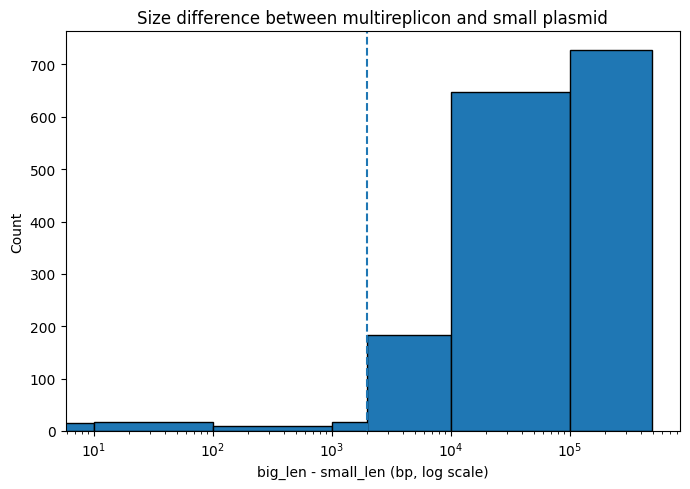

Total: 1617
<= 2000 bp: 59 (3.65%)
> 2000 bp: 1558 (96.35%)


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/containment_mm2/nucmer/graph_cov90_noclose/containment_NUC_levelup_strictlen.tsv"

df = pd.read_csv(FILE, sep="\t")
df["size_diff_bp"] = df["big_len"] - df["small_len"]
df = df[df["size_diff_bp"] >= 0].copy()

cutoff = 2000

# bins por décadas + corte explícito en 2000
# 0-10, 11-100, 101-1000, 1001-2000, 2001-10000, ...
bins = [0, 10, 100, 1000, 2000]
maxv = int(df["size_diff_bp"].max())

edge = 10000
while edge < maxv:
    bins.append(edge)
    edge *= 10
if bins[-1] < maxv:
    bins.append(maxv)

bins = sorted(set(bins))

plt.figure(figsize=(7,5))
plt.hist(df["size_diff_bp"], bins=bins, edgecolor="black")
plt.xscale("log")
plt.axvline(cutoff, linestyle="--", linewidth=1.5)
plt.xlabel("big_len - small_len (bp, log scale)")
plt.ylabel("Count")
plt.title("Size difference between multireplicon and small plasmid")
plt.tight_layout()
plt.show()

# resumen del corte
n_total = len(df)
n_le = (df["size_diff_bp"] <= cutoff).sum()
n_gt = (df["size_diff_bp"] > cutoff).sum()

print(f"Total: {n_total}")
print(f"<= {cutoff} bp: {n_le} ({n_le/n_total:.2%})")
print(f"> {cutoff} bp: {n_gt} ({n_gt/n_total:.2%})")

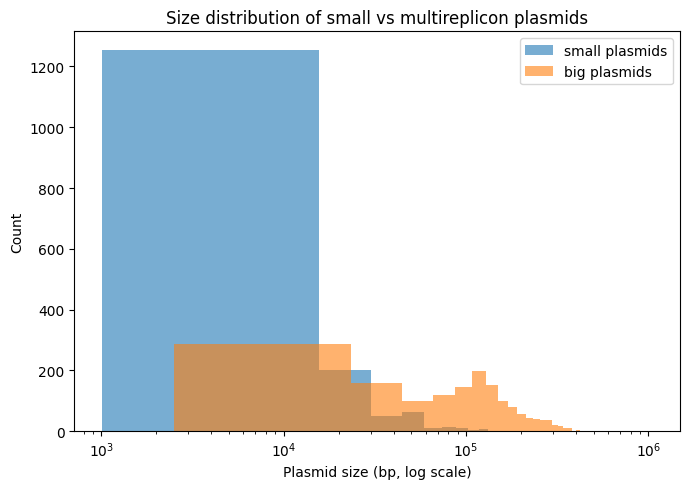


SMALL plasmids:
count      1617.000000
mean      12795.087817
std       26849.753777
min        1008.000000
25%        2638.000000
50%        5153.000000
75%       11425.000000
max      727711.000000
Name: small_len, dtype: float64

BIG plasmids:
count    1.617000e+03
mean     1.152252e+05
std      9.130049e+04
min      2.511000e+03
25%      3.791700e+04
50%      1.069580e+05
75%      1.620930e+05
max      1.051520e+06
Name: big_len, dtype: float64


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/containment_mm2/nucmer/graph_cov90_noclose/containment_NUC_levelup_strictlen.tsv"

df = pd.read_csv(FILE, sep="\t")

# columnas
small = df["small_len"]
big = df["big_len"]

plt.figure(figsize=(7,5))

# histogramas superpuestos
plt.hist(small, bins=50, alpha=0.6, label="small plasmids")
plt.hist(big, bins=50, alpha=0.6, label="big plasmids")

plt.xscale("log")
plt.xlabel("Plasmid size (bp, log scale)")
plt.ylabel("Count")
plt.title("Size distribution of small vs multireplicon plasmids")
plt.legend()
plt.tight_layout()
plt.show()

# estadísticas rápidas
print("\nSMALL plasmids:")
print(small.describe())

print("\nBIG plasmids:")
print(big.describe())

In [30]:
import pandas as pd

# ============================================================
# INPUTS
# ============================================================

BASE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000"
TRACTS_FILE = f"{BASE}/homologous_tracts.tsv"

WINDOW_HW = 1000
BREAKPOINT_WINPOS = WINDOW_HW + 1   # 1001

tracts = pd.read_csv(TRACTS_FILE, sep="\t")

# top 3 clusters desde tu tabla cl / cluster_sizes ya cargadas
top_clusters = cluster_sizes.head(3)["cluster"].tolist()

cl_top = cl[cl["cluster"].isin(top_clusters)].copy()
cl_top = cl_top.drop_duplicates(["cluster", "tract_id", "pair_id", "plasmid"])

x = cl_top.merge(
    tracts,
    on=["tract_id", "pair_id", "plasmid"],
    how="left"
)

# ============================================================
# HELPERS
# ============================================================

def interval_to_breakpoint_metrics(start, end, bp=1001):
    start = int(start)
    end = int(end)

    inside = (start <= bp <= end)
    min_dist = 0 if inside else min(abs(start - bp), abs(end - bp))
    center = (start + end) / 2
    center_signed = center - bp

    return pd.Series({
        "bp_inside": inside,
        "dist_min_to_bp": min_dist,
        "dist_start_to_bp": start - bp,
        "dist_end_to_bp": end - bp,
        "dist_center_to_bp": center_signed
    })

# ============================================================
# START WINDOW
# ============================================================

start_metrics = x.apply(
    lambda r: interval_to_breakpoint_metrics(r["qstart"], r["qend"], BREAKPOINT_WINPOS),
    axis=1
).add_prefix("start_")

# ============================================================
# END WINDOW
# ============================================================

end_metrics = x.apply(
    lambda r: interval_to_breakpoint_metrics(r["sstart"], r["send"], BREAKPOINT_WINPOS),
    axis=1
).add_prefix("end_")

# ============================================================
# FINAL TABLE
# ============================================================

dist = pd.concat([x, start_metrics, end_metrics], axis=1)

out = dist[[
    "cluster", "tract_id", "pair_id", "plasmid", "length", "pident",
    "qstart", "qend", "sstart", "send",
    "start_bp_inside", "start_dist_min_to_bp", "start_dist_start_to_bp", "start_dist_end_to_bp", "start_dist_center_to_bp",
    "end_bp_inside", "end_dist_min_to_bp", "end_dist_start_to_bp", "end_dist_end_to_bp", "end_dist_center_to_bp"
]].copy()

OUT_TSV = f"{BASE}/top3_clusters_distance_to_breakpoint.tsv"
out.to_csv(OUT_TSV, sep="\t", index=False)

print("Saved:", OUT_TSV)
print(out.head(20))

Saved: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/top3_clusters_distance_to_breakpoint.tsv
    cluster  tract_id  pair_id        plasmid  length   pident  qstart  qend  \
0        73        79       96  NZ_CP017086.1     822  100.000     832  1653   
1        73        80       97     CP067912.1     722   99.723    1001  1722   
2        73        81       98     CP067912.1     722   99.723    1001  1722   
3        73        86      114    NC_021656.1     437  100.000    1000  1436   
4        73        91      140     AP022086.1     820  100.000     181  1000   
5        73        93      142     CP027485.1     820  100.000     181  1000   
6        73        98      147     CP052139.1     820  100.000     181  1000   
7        73       104      153     CP082572.1     820  100.000     181  1000   
8        73       105      154     CP088403.1     820   99.878     181  1000   
9        73       106      155     CP088651.1     820   99.878  

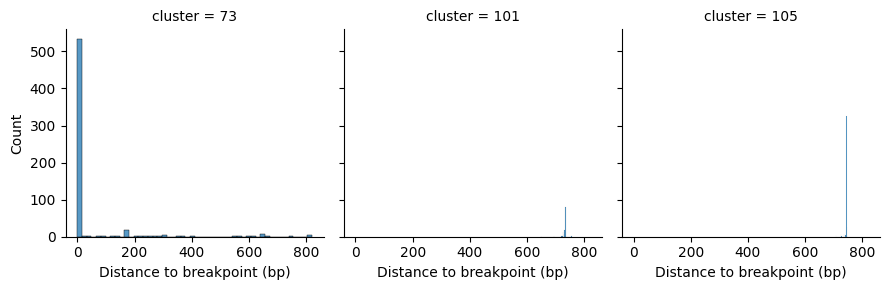

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_1000/top3_clusters_distance_to_breakpoint.tsv"

df = pd.read_csv(FILE, sep="\t")

# usamos distancia mínima (más robusto)
plot_df = df.copy()

# reshape: start + end como observaciones independientes
plot_df = pd.concat([
    plot_df[["cluster", "start_dist_min_to_bp"]].rename(columns={"start_dist_min_to_bp": "dist"}),
    plot_df[["cluster", "end_dist_min_to_bp"]].rename(columns={"end_dist_min_to_bp": "dist"})
])

# --------------------------------------------------
# FACET GRID
# --------------------------------------------------

g = sns.FacetGrid(plot_df, col="cluster", col_wrap=3, sharex=True, sharey=True)
g.map_dataframe(sns.histplot, x="dist", bins=50)

for ax in g.axes.flatten():
    ax.set_xlabel("Distance to breakpoint (bp)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [33]:
#!/usr/bin/env python3

import os
import re
import csv
import shutil
import subprocess
from multiprocessing import Pool, cpu_count

import pandas as pd
from Bio import SeqIO
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
NUCMER_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/containment_mm2/nucmer"
GRAPH_DIR = os.path.join(NUCMER_DIR, "graph_cov90_noclose")
CONTAINMENT_FILE = os.path.join(GRAPH_DIR, "containment_NUC_levelup_strictlen.tsv")

PLASMID_FASTA_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/raw_fastas"
SAMTOOLS = "/home/nacho/mambaforge/envs/samtools/bin/samtools"
BLASTN = "/home/nacho/mambaforge/envs/blast/bin/blastn"       # AJUSTA SI HACE FALTA
CDHITEST = "/home/nacho/mambaforge/envs/cd-hit/bin/cd-hit-est" # AJUSTA SI HACE FALTA

WINDOW_HW = 500
BREAKPOINT_WINPOS = WINDOW_HW + 1
MIN_LEN = 100
MIN_PID = 95.0
TOP_N = 3
CDHIT_ID = 0.95
CDHIT_WORD = 10

N_CORES = max(1, cpu_count() - 2)

OUTDIR = os.path.join(BASE_DIR, f"TRACEABLE_hyper_{WINDOW_HW}")
WINDOWS_DIR = os.path.join(OUTDIR, "windows")
BLAST_DIR = os.path.join(OUTDIR, "pairwise_blast")

MASTER_TSV = os.path.join(OUTDIR, "breakpoints_master.tsv")
MULTIFASTA = os.path.join(OUTDIR, "breakpoints_windows.fa")
PAIRWISE_TSV = os.path.join(OUTDIR, "pairwise_hits.tsv")
TRACTS_TSV = os.path.join(OUTDIR, "homologous_tracts.tsv")
TRACTS_FASTA = os.path.join(OUTDIR, "homologous_tracts.fa")
TRACTS_UNIQUE_FASTA = os.path.join(OUTDIR, "tracts_unique.fa")

CDHIT_OUT_FASTA = os.path.join(OUTDIR, "homologous_tracts_cdhit_95.fa")
CDHIT_OUT_CLSTR = CDHIT_OUT_FASTA + ".clstr"

CLUSTERS_MEMBERS_TSV = os.path.join(OUTDIR, "clusters_members.tsv")
CLUSTERS_SIZES_TSV = os.path.join(OUTDIR, "clusters_sizes.tsv")
TOP_DIST_TSV = os.path.join(OUTDIR, "top3_clusters_distance_to_breakpoint.tsv")
TOP_DIST_PNG = os.path.join(OUTDIR, "top3_clusters_distance_to_breakpoint.png")

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(WINDOWS_DIR, exist_ok=True)
os.makedirs(BLAST_DIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def parse_cov90_line(line):
    toks = re.split(r"\s+", line.strip())
    if len(toks) < 14:
        return None
    try:
        return {
            "s1": int(toks[0]),
            "e1": int(toks[1]),
            "s2": int(toks[2]),
            "e2": int(toks[3]),
            "len1": int(toks[4]),
            "len2": int(toks[5]),
            "lenR": int(toks[7]),
            "lenQ": int(toks[8]),
            "ref": toks[11],
            "qry": toks[12],
            "raw": line.strip(),
        }
    except Exception:
        return None

def get_cov90_path(src):
    p1 = os.path.join(NUCMER_DIR, src)
    if os.path.exists(p1):
        return p1
    p2 = os.path.join(GRAPH_DIR, os.path.basename(src))
    if os.path.exists(p2):
        return p2
    raise FileNotFoundError(f"No encuentro cov90 para: {src}")

def get_fasta_path(chrom):
    for fname in os.listdir(PLASMID_FASTA_DIR):
        if fname.endswith((".fna", ".fa", ".fasta")) and fname.startswith(chrom):
            return os.path.join(PLASMID_FASTA_DIR, fname)
    return None

def get_length_from_fasta(fasta):
    fai = fasta + ".fai"
    if not os.path.exists(fai):
        subprocess.run([SAMTOOLS, "faidx", fasta], check=True)
    with open(fai) as f:
        return int(f.readline().split("\t")[1])

def circular_window(center, L, hw):
    start = center - hw
    end = center + hw

    if start >= 1 and end <= L:
        return [(start, end)]
    if start < 1:
        return [(L + start + 1, L), (1, end)]
    if end > L:
        return [(start, L), (1, end - L)]
    return None

def fetch_sequence(fasta, chrom, parts):
    seq = []
    for s, e in parts:
        region = f"{chrom}:{s}-{e}"
        out = subprocess.check_output([SAMTOOLS, "faidx", fasta, region]).decode()
        seq.append("".join(out.split("\n")[1:]))
    return "".join(seq)

def run_blast_job(job):
    pair_id, plasmid, fa_start, fa_end, start_header, end_header, bp_start, bp_end = job
    out_file = os.path.join(BLAST_DIR, f"pair_{pair_id:05d}.blast.tsv")

    cmd = [
        BLASTN,
        "-query", fa_start,
        "-subject", fa_end,
        "-task", "blastn",
        "-dust", "no",
        "-soft_masking", "false",
        "-outfmt", "6 qseqid sseqid qstart qend sstart send length pident mismatch gapopen evalue bitscore",
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        return [{
            "pair_id": pair_id,
            "plasmid": plasmid,
            "bp_start_index": bp_start,
            "bp_end_index": bp_end,
            "start_header": start_header,
            "end_header": end_header,
            "status": "error",
            "qseqid": None,
            "sseqid": None,
            "qstart": None,
            "qend": None,
            "sstart": None,
            "send": None,
            "length": None,
            "pident": None,
            "mismatch": None,
            "gapopen": None,
            "evalue": None,
            "bitscore": None,
            "blast_file": out_file,
            "stderr": result.stderr.strip(),
        }]

    with open(out_file, "w") as f:
        f.write(result.stdout)

    rows = []
    if result.stdout.strip():
        for line in result.stdout.strip().split("\n"):
            toks = line.split("\t")
            rows.append({
                "pair_id": pair_id,
                "plasmid": plasmid,
                "bp_start_index": bp_start,
                "bp_end_index": bp_end,
                "start_header": start_header,
                "end_header": end_header,
                "status": "ok",
                "qseqid": toks[0],
                "sseqid": toks[1],
                "qstart": int(toks[2]),
                "qend": int(toks[3]),
                "sstart": int(toks[4]),
                "send": int(toks[5]),
                "length": int(toks[6]),
                "pident": float(toks[7]),
                "mismatch": int(toks[8]),
                "gapopen": int(toks[9]),
                "evalue": toks[10],
                "bitscore": float(toks[11]),
                "blast_file": out_file,
                "stderr": "",
            })
    else:
        rows.append({
            "pair_id": pair_id,
            "plasmid": plasmid,
            "bp_start_index": bp_start,
            "bp_end_index": bp_end,
            "start_header": start_header,
            "end_header": end_header,
            "status": "ok",
            "qseqid": None,
            "sseqid": None,
            "qstart": None,
            "qend": None,
            "sstart": None,
            "send": None,
            "length": None,
            "pident": None,
            "mismatch": None,
            "gapopen": None,
            "evalue": None,
            "bitscore": None,
            "blast_file": out_file,
            "stderr": "",
        })
    return rows

def interval_to_breakpoint_metrics(start, end, bp):
    start = int(start)
    end = int(end)
    inside = (start <= bp <= end)
    min_dist = 0 if inside else min(abs(start - bp), abs(end - bp))
    center = (start + end) / 2
    center_signed = center - bp
    return {
        "bp_inside": inside,
        "dist_min_to_bp": min_dist,
        "dist_start_to_bp": start - bp,
        "dist_end_to_bp": end - bp,
        "dist_center_to_bp": center_signed,
    }

def parse_cluster_header(header):
    tract = re.search(r"tract=(\d+)", header)
    pair = re.search(r"pair=(\d+)", header)
    plasmid = re.search(r"plasmid=([^|]+)", header)
    return {
        "tract_id": int(tract.group(1)) if tract else None,
        "pair_id": int(pair.group(1)) if pair else None,
        "plasmid": plasmid.group(1) if plasmid else None,
    }

# ============================================================
# 1. BUILD TRACEABLE WINDOWS
# ============================================================

print("\n[1/7] Building traceable windows...")

rows = []
pair_id = 0
bp_index = 0

with open(CONTAINMENT_FILE) as f:
    rdr = csv.DictReader(f, delimiter="\t")
    for row in rdr:
        big_len = int(row["big_len"])
        cov_path = get_cov90_path(row["source_file"])

        found = False
        with open(cov_path) as fh:
            for lineno, line in enumerate(fh, 1):
                parsed = parse_cov90_line(line)
                if not parsed:
                    continue

                if parsed["lenR"] == big_len:
                    chrom = parsed["ref"]
                    s = min(parsed["s1"], parsed["e1"])
                    e = max(parsed["s1"], parsed["e1"])
                elif parsed["lenQ"] == big_len:
                    chrom = parsed["qry"]
                    s = min(parsed["s2"], parsed["e2"])
                    e = max(parsed["s2"], parsed["e2"])
                else:
                    continue

                fasta = get_fasta_path(chrom)
                if fasta is None:
                    print(f"[WARN] No FASTA for {chrom}")
                    break

                real_L = get_length_from_fasta(fasta)

                for bp_kind, pos in [("start", s), ("end", e)]:
                    parts = circular_window(pos, real_L, WINDOW_HW)
                    if not parts:
                        continue

                    seq = fetch_sequence(fasta, chrom, parts)
                    header = f"pair={pair_id}|bp={bp_index}|plasmid={chrom}|kind={bp_kind}|pos={pos}|hw={WINDOW_HW}"

                    fa_path = os.path.join(WINDOWS_DIR, f"bp_{bp_index}.fa")
                    with open(fa_path, "w") as out:
                        out.write(f">{header}\n{seq}\n")

                    rows.append({
                        "pair_id": pair_id,
                        "bp_index": bp_index,
                        "plasmid": chrom,
                        "breakpoint_pos": pos,
                        "bp_kind": bp_kind,
                        "plasmid_len": real_L,
                        "window_hw": WINDOW_HW,
                        "source_file": row["source_file"],
                        "containment_query": row["query_id"],
                        "containment_target": row["target_id"],
                        "cov_line_number": lineno,
                        "fasta_header": header,
                        "fasta_path": fa_path,
                    })
                    bp_index += 1

                pair_id += 1
                found = True
                break

        if not found:
            print(f"[WARN] No valid alignment for {row['query_id']} vs {row['target_id']}")

master = pd.DataFrame(rows)
master.to_csv(MASTER_TSV, sep="\t", index=False)

with open(MULTIFASTA, "w") as out:
    for _, r in master.sort_values("bp_index").iterrows():
        with open(r["fasta_path"]) as f:
            out.write(f.read())

print(f"Breakpoints: {len(master)} | Pairs: {master['pair_id'].nunique()}")
print(f"Wrote: {MASTER_TSV}")
print(f"Wrote: {MULTIFASTA}")

# ============================================================
# 2. BLAST START VS END FOR EACH PAIR
# ============================================================

print("\n[2/7] Running pairwise BLAST...")

m_start = master[master["bp_kind"] == "start"].copy()
m_end = master[master["bp_kind"] == "end"].copy()

pairs = m_start.merge(
    m_end,
    on=["pair_id", "plasmid"],
    suffixes=("_start", "_end")
)

jobs = []
for _, r in pairs.iterrows():
    jobs.append((
        int(r["pair_id"]),
        r["plasmid"],
        r["fasta_path_start"],
        r["fasta_path_end"],
        r["fasta_header_start"],
        r["fasta_header_end"],
        int(r["bp_index_start"]),
        int(r["bp_index_end"]),
    ))

all_rows = []
with Pool(N_CORES) as pool:
    for res in pool.map(run_blast_job, jobs):
        all_rows.extend(res)

pairwise = pd.DataFrame(all_rows)
pairwise.to_csv(PAIRWISE_TSV, sep="\t", index=False)

print(pairwise["status"].value_counts(dropna=False))
print(f"Wrote: {PAIRWISE_TSV}")

# ============================================================
# 3. EXTRACT HOMOLOGOUS TRACTS
# ============================================================

print("\n[3/7] Extracting homologous tracts...")

hits = pairwise[
    pairwise["length"].notna() &
    (pairwise["length"] >= MIN_LEN) &
    (pairwise["pident"] >= MIN_PID)
].copy()

hits["length"] = hits["length"].astype(int)
hits["qstart"] = hits["qstart"].astype(int)
hits["qend"] = hits["qend"].astype(int)
hits["sstart"] = hits["sstart"].astype(int)
hits["send"] = hits["send"].astype(int)

bp_meta = master.set_index("bp_index").to_dict(orient="index")
seq_cache = {}

def load_seq(path):
    if path not in seq_cache:
        rec = next(SeqIO.parse(path, "fasta"))
        seq_cache[path] = str(rec.seq)
    return seq_cache[path]

rows = []
fasta_records = []
tract_id = 0

for _, r in hits.iterrows():
    bp_start = int(r["bp_start_index"])
    bp_end = int(r["bp_end_index"])

    meta_start = bp_meta[bp_start]
    meta_end = bp_meta[bp_end]

    seq_start_full = load_seq(meta_start["fasta_path"])
    seq_end_full = load_seq(meta_end["fasta_path"])

    q1, q2 = sorted([int(r["qstart"]), int(r["qend"])])
    s1, s2 = sorted([int(r["sstart"]), int(r["send"])])

    seq_start = seq_start_full[q1-1:q2]
    seq_end = seq_end_full[s1-1:s2]

    tract_name = (
        f"tract={tract_id}|pair={int(r['pair_id'])}|plasmid={r['plasmid']}"
        f"|bp_start={bp_start}|bp_end={bp_end}|len={int(r['length'])}|pid={r['pident']:.3f}"
    )

    rows.append({
        "tract_id": tract_id,
        "pair_id": int(r["pair_id"]),
        "plasmid": r["plasmid"],
        "bp_start_index": bp_start,
        "bp_end_index": bp_end,
        "bp_start_pos": meta_start["breakpoint_pos"],
        "bp_end_pos": meta_end["breakpoint_pos"],
        "qstart": q1,
        "qend": q2,
        "sstart": s1,
        "send": s2,
        "length": int(r["length"]),
        "pident": float(r["pident"]),
        "bitscore": float(r["bitscore"]),
        "seq_start": seq_start,
        "seq_end": seq_end,
        "start_header": r["start_header"],
        "end_header": r["end_header"],
        "tract_name": tract_name,
    })

    fasta_records.append(f">{tract_name}|side=start\n{seq_start}\n")
    fasta_records.append(f">{tract_name}|side=end\n{seq_end}\n")

    tract_id += 1

tracts = pd.DataFrame(rows)
tracts.to_csv(TRACTS_TSV, sep="\t", index=False)

with open(TRACTS_FASTA, "w") as f:
    for rec in fasta_records:
        f.write(rec)

print(f"Filtered hits / tracts: {len(tracts)}")
print(f"Wrote: {TRACTS_TSV}")
print(f"Wrote: {TRACTS_FASTA}")

# ============================================================
# 4. UNIQUE TRACTS FASTA + CD-HIT
# ============================================================

print("\n[4/7] Preparing unique tract FASTA and clustering...")

with open(TRACTS_UNIQUE_FASTA, "w") as out:
    for _, r in tracts.iterrows():
        out.write(f">{r['tract_name']}\n{r['seq_start']}\n")

if not shutil.which(CDHITEST) and not os.path.exists(CDHITEST):
    raise FileNotFoundError(f"No encuentro cd-hit-est en {CDHITEST}")

subprocess.run([
    CDHITEST,
    "-i", TRACTS_UNIQUE_FASTA,
    "-o", CDHIT_OUT_FASTA,
    "-c", str(CDHIT_ID),
    "-n", str(CDHIT_WORD),
    "-d", "0",
    "-M", "0",
    "-T", str(N_CORES),
], check=True)

print(f"Wrote: {CDHIT_OUT_FASTA}")
print(f"Wrote: {CDHIT_OUT_CLSTR}")

# ============================================================
# 5. PARSE CLUSTERS
# ============================================================

print("\n[5/7] Parsing clusters...")

cluster_rows = []
cluster_id = None

with open(CDHIT_OUT_CLSTR) as f:
    for line in f:
        line = line.strip()
        if line.startswith(">Cluster"):
            cluster_id = int(line.split()[1])
            continue

        m = re.search(r">(.+?)\.\.\.", line)
        if not m:
            continue

        header = m.group(1)
        info = parse_cluster_header(header)
        cluster_rows.append({
            "cluster": cluster_id,
            "tract_id": info["tract_id"],
            "pair_id": info["pair_id"],
            "plasmid": info["plasmid"],
        })

cl = pd.DataFrame(cluster_rows)
cl.to_csv(CLUSTERS_MEMBERS_TSV, sep="\t", index=False)

cluster_sizes = (
    cl.groupby("cluster")
      .size()
      .sort_values(ascending=False)
      .reset_index(name="n")
)
cluster_sizes.to_csv(CLUSTERS_SIZES_TSV, sep="\t", index=False)

print(cluster_sizes.head(10))
print(f"Wrote: {CLUSTERS_MEMBERS_TSV}")
print(f"Wrote: {CLUSTERS_SIZES_TSV}")

# ============================================================
# 6. DISTANCE TO BREAKPOINT FOR TOP 3 CLUSTERS
# ============================================================

print("\n[6/7] Computing distance to breakpoint for top 3 clusters...")

top_clusters = cluster_sizes.head(TOP_N)["cluster"].tolist()
cl_top = cl[cl["cluster"].isin(top_clusters)].copy()

x = cl_top.merge(
    tracts,
    on=["tract_id", "pair_id", "plasmid"],
    how="left"
)

start_metrics = x.apply(
    lambda r: pd.Series(interval_to_breakpoint_metrics(r["qstart"], r["qend"], BREAKPOINT_WINPOS)),
    axis=1
).add_prefix("start_")

end_metrics = x.apply(
    lambda r: pd.Series(interval_to_breakpoint_metrics(r["sstart"], r["send"], BREAKPOINT_WINPOS)),
    axis=1
).add_prefix("end_")

dist = pd.concat([x, start_metrics, end_metrics], axis=1)

top_dist = dist[[
    "cluster", "tract_id", "pair_id", "plasmid", "length", "pident",
    "qstart", "qend", "sstart", "send",
    "start_bp_inside", "start_dist_min_to_bp", "start_dist_start_to_bp", "start_dist_end_to_bp", "start_dist_center_to_bp",
    "end_bp_inside", "end_dist_min_to_bp", "end_dist_start_to_bp", "end_dist_end_to_bp", "end_dist_center_to_bp"
]].copy()

top_dist.to_csv(TOP_DIST_TSV, sep="\t", index=False)
print(f"Wrote: {TOP_DIST_TSV}")

# ============================================================
# 7. HISTOGRAM BY CLUSTER
# ============================================================

print("\n[7/7] Plotting histograms...")

plot_df = pd.concat([
    top_dist[["cluster", "start_dist_min_to_bp"]].rename(columns={"start_dist_min_to_bp": "dist"}),
    top_dist[["cluster", "end_dist_min_to_bp"]].rename(columns={"end_dist_min_to_bp": "dist"}),
], ignore_index=True)

g = sns.FacetGrid(plot_df, col="cluster", col_wrap=3, sharex=True, sharey=True)
g.map_dataframe(sns.histplot, x="dist", bins=50)

for ax in g.axes.flatten():
    ax.set_xlabel("Distance to breakpoint (bp)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(TOP_DIST_PNG, dpi=300, bbox_inches="tight")
plt.close()

print(f"Wrote: {TOP_DIST_PNG}")

print("\nDONE.")
print(f"Output directory: {OUTDIR}")


[1/7] Building traceable windows...
Breakpoints: 3234 | Pairs: 1617
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_500/breakpoints_master.tsv
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_500/breakpoints_windows.fa

[2/7] Running pairwise BLAST...
status
ok    3291
Name: count, dtype: int64
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_500/pairwise_hits.tsv

[3/7] Extracting homologous tracts...
Filtered hits / tracts: 450
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_500/homologous_tracts.tsv
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_500/homologous_tracts.fa

[4/7] Preparing unique tract FASTA and clustering...
Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 22:00:32
Command: /home/nacho/mambaforge/envs/cd-hit/bin/cd-hit-est -i
         /home/nacho/HDD16/Nacho/Repl

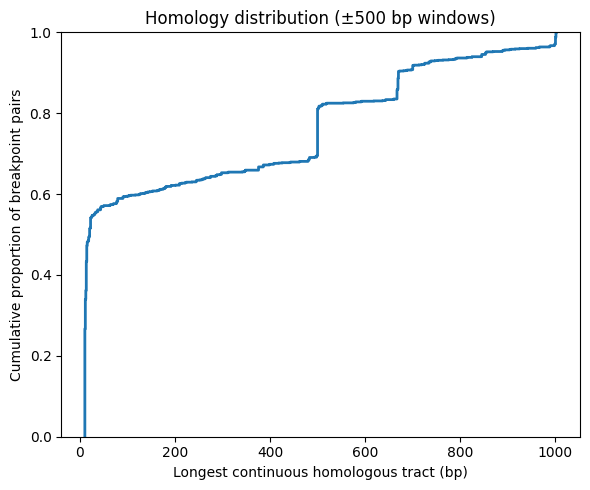

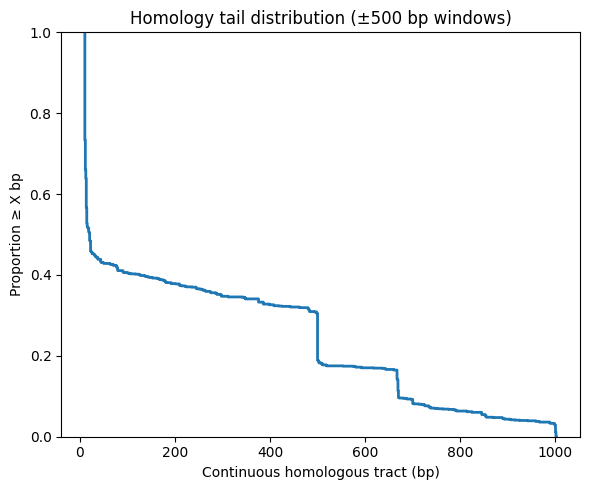

count    1244.000000
mean      240.945338
std       306.742426
min        11.000000
25%        11.000000
50%        21.000000
75%       500.000000
max      1002.000000
Name: best_len, dtype: float64

Top 20 longest tracts:
      pair_id  best_len  best_pident
351       372    1002.0      100.000
376       400    1001.0       99.800
388       414    1001.0       99.800
634       737    1001.0       99.800
551       626    1001.0       99.800
385       411    1001.0       99.800
1047     1253    1001.0       92.857
104       106    1001.0       99.800
1046     1251    1001.0       99.800
350       371    1001.0       99.800
727       866    1001.0       99.800
682       808    1001.0       92.857
728       867    1001.0       92.857
328       347    1001.0       92.857
629       730    1001.0       99.800
363       384    1000.0      100.000
362       383    1000.0      100.000
659       778    1000.0      100.000
1048     1254    1000.0      100.000
517       558    1000.0       99.900


In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# INPUTS
# ============================================================

TRACEABLE_HITS = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_500/pairwise_hits.tsv"
hw = 500
min_len = 0  # cambia si quieres filtrar

# ============================================================
# 1. LOAD NEW PIPELINE
# ============================================================

df = pd.read_csv(TRACEABLE_HITS, sep="\t")

df = df[
    df["length"].notna() &
    (df["status"] == "ok")
].copy()

df["length"] = pd.to_numeric(df["length"], errors="coerce")
df["pident"] = pd.to_numeric(df["pident"], errors="coerce")

if min_len > 0:
    df = df[df["length"] >= min_len].copy()

# mejor HSP por pair
best = (
    df.groupby("pair_id", as_index=False)
      .agg(
          best_len=("length", "max"),
          best_pident=("pident", "max")
      )
)

# ============================================================
# 2. ECDF
# ============================================================

plt.figure(figsize=(6,5))

sns.ecdfplot(
    data=best,
    x="best_len",
    linewidth=2
)

plt.xlabel("Longest continuous homologous tract (bp)")
plt.ylabel("Cumulative proportion of breakpoint pairs")
plt.title(f"Homology distribution (±{hw} bp windows)")
plt.tight_layout()
plt.show()

# ============================================================
# 3. TAIL ECDF
# ============================================================

plt.figure(figsize=(6,5))

sns.ecdfplot(
    data=best,
    x="best_len",
    complementary=True,
    linewidth=2
)

plt.xlabel("Continuous homologous tract (bp)")
plt.ylabel("Proportion ≥ X bp")
plt.title(f"Homology tail distribution (±{hw} bp windows)")
plt.tight_layout()
plt.show()

# ============================================================
# 4. QUICK NUMERIC CHECK
# ============================================================

print(best["best_len"].describe())

print("\nTop 20 longest tracts:")
print(best.sort_values("best_len", ascending=False).head(20))

N tracts: 278

Summary:
count    278.000000
mean     523.726619
std      127.384991
min      104.000000
25%      500.000000
50%      500.000000
75%      667.000000
max      825.000000
Name: length, dtype: float64


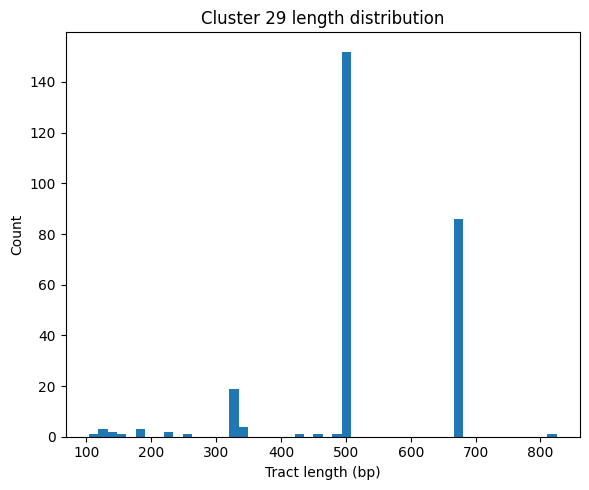

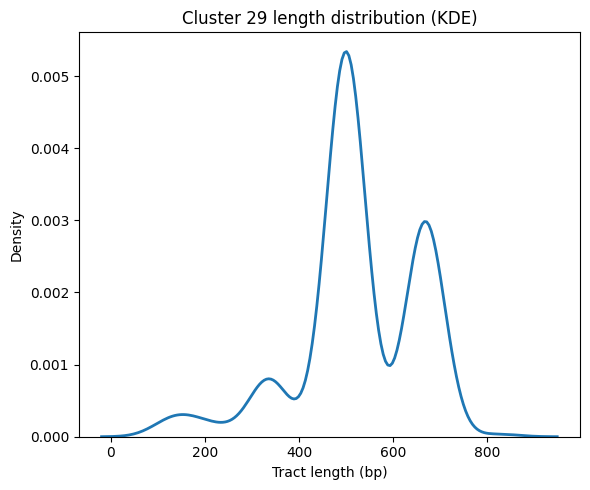


Top 10 longest:
     cluster  tract_id  pair_id        plasmid  length
98        29       238      868  NZ_ON390812.1     825
125       29       266      895  NZ_CP065557.1     672
114       29       255      884  NZ_CP032242.1     670
100       29       241      872     CP050278.1     670
102       29       243      873     CP050282.1     670
147       29       288      914  NZ_CP102642.1     670
138       29       279      906  NZ_CP095248.1     670
120       29       261      892  NZ_CP064243.1     670
122       29       263      893  NZ_CP064260.1     670
127       29       268      896  NZ_CP066906.1     670

Top 10 shortest:
     cluster  tract_id  pair_id        plasmid  length
269       29       420     1181  NZ_CP016812.1     104
64        29        87      313  NZ_MH522419.1     125
258       29       402     1130  NZ_MH522419.1     125
155       29       296      918  NZ_CP107293.1     131
41        29        63      245  NZ_CP082104.1     143
235       29       378     107

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# INPUTS
# ============================================================

TRACTS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_500/homologous_tracts.tsv"
CLUSTERS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_500/clusters_members.tsv"

CLUSTER_ID = 29

# ============================================================
# LOAD
# ============================================================

tracts = pd.read_csv(TRACTS_FILE, sep="\t")
cl = pd.read_csv(CLUSTERS_FILE, sep="\t")

# ============================================================
# SUBSET CLUSTER
# ============================================================

cl29 = cl[cl["cluster"] == CLUSTER_ID].copy()

# unir con longitudes
df = cl29.merge(
    tracts[["tract_id", "pair_id", "length"]],
    on=["tract_id", "pair_id"],
    how="left"
)

print("N tracts:", len(df))

# ============================================================
# SUMMARY
# ============================================================

print("\nSummary:")
print(df["length"].describe())

# ============================================================
# HISTOGRAM
# ============================================================

plt.figure(figsize=(6,5))

plt.hist(df["length"], bins=50)

plt.xlabel("Tract length (bp)")
plt.ylabel("Count")
plt.title(f"Cluster {CLUSTER_ID} length distribution")
plt.tight_layout()
plt.show()

# ============================================================
# KDE (opcional)
# ============================================================

plt.figure(figsize=(6,5))

sns.kdeplot(
    data=df,
    x="length",
    linewidth=2
)

plt.xlabel("Tract length (bp)")
plt.ylabel("Density")
plt.title(f"Cluster {CLUSTER_ID} length distribution (KDE)")
plt.tight_layout()
plt.show()

# ============================================================
# VER EJEMPLOS
# ============================================================

print("\nTop 10 longest:")
print(df.sort_values("length", ascending=False).head(10))

print("\nTop 10 shortest:")
print(df.sort_values("length", ascending=True).head(10))

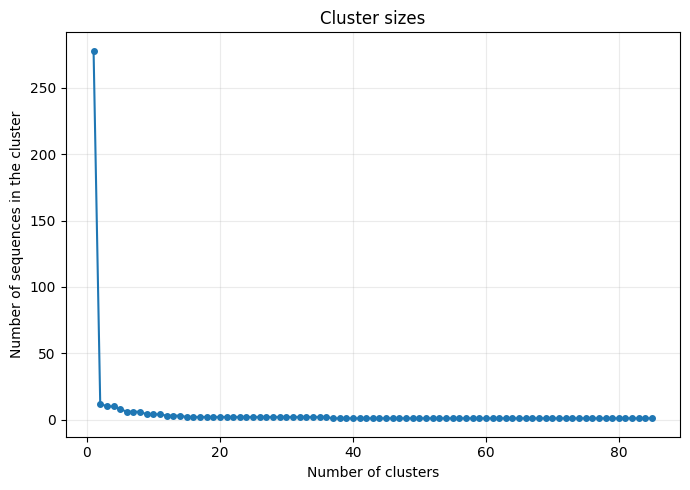

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

CLUSTERS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hyper_500/clusters_members.tsv"

cl = pd.read_csv(CLUSTERS_FILE, sep="\t")

# tamaño de cada cluster
cluster_sizes = (
    cl.groupby("cluster")
      .size()
      .reset_index(name="n_sequences")
      .sort_values("n_sequences", ascending=False)
      .reset_index(drop=True)
)

cluster_sizes["cluster_rank"] = range(1, len(cluster_sizes) + 1)

plt.figure(figsize=(7,5))
plt.plot(
    cluster_sizes["cluster_rank"],
    cluster_sizes["n_sequences"],
    marker="o",
    linewidth=1.5,
    markersize=4
)

plt.xlabel("Number of clusters")
plt.ylabel("Number of sequences in the cluster")
plt.title("Cluster sizes")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [42]:
#!/usr/bin/env python3

import os
import re
import csv
import shutil
import subprocess
from multiprocessing import Pool, cpu_count

import pandas as pd
from Bio import SeqIO
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
NUCMER_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/containment_mm2/nucmer"
GRAPH_DIR = os.path.join(NUCMER_DIR, "graph_cov90_noclose")
CONTAINMENT_FILE = os.path.join(GRAPH_DIR, "containment_NUC_levelup_strictlen.tsv")

PLASMID_FASTA_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/raw_fastas"
SAMTOOLS = "/home/nacho/mambaforge/envs/samtools/bin/samtools"
BLASTN = "/home/nacho/mambaforge/envs/blast/bin/blastn"
CDHITEST = "/home/nacho/mambaforge/envs/cd-hit/bin/cd-hit-est"

WINDOW_HW = 500
BREAKPOINT_WINPOS = WINDOW_HW + 1

# v2: hard cut at 95% identity already in BLAST; no length cutoff for clustering
MIN_LEN = 0
MIN_PID = 95.0

TOP_N = 3
CDHIT_ID = 0.95
CDHIT_WORD = 10

N_CORES = max(1, cpu_count() - 2)

OUTDIR = os.path.join(BASE_DIR, f"TRACEABLE_hardcut_95pid_{WINDOW_HW}")
WINDOWS_DIR = os.path.join(OUTDIR, "windows")
BLAST_DIR = os.path.join(OUTDIR, "pairwise_blast")

MASTER_TSV = os.path.join(OUTDIR, "breakpoints_master.tsv")
MULTIFASTA = os.path.join(OUTDIR, "breakpoints_windows.fa")
PAIRWISE_TSV = os.path.join(OUTDIR, "pairwise_hits.tsv")
TRACTS_TSV = os.path.join(OUTDIR, "homologous_tracts.tsv")
TRACTS_FASTA = os.path.join(OUTDIR, "homologous_tracts.fa")
TRACTS_UNIQUE_FASTA = os.path.join(OUTDIR, "tracts_unique.fa")

CDHIT_OUT_FASTA = os.path.join(OUTDIR, "homologous_tracts_cdhit_95.fa")
CDHIT_OUT_CLSTR = CDHIT_OUT_FASTA + ".clstr"

CLUSTERS_MEMBERS_TSV = os.path.join(OUTDIR, "clusters_members.tsv")
CLUSTERS_SIZES_TSV = os.path.join(OUTDIR, "clusters_sizes.tsv")
TOP_DIST_TSV = os.path.join(OUTDIR, "top3_clusters_distance_to_breakpoint.tsv")
TOP_DIST_PNG = os.path.join(OUTDIR, "top3_clusters_distance_to_breakpoint.png")

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(WINDOWS_DIR, exist_ok=True)
os.makedirs(BLAST_DIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def parse_cov90_line(line):
    toks = re.split(r"\s+", line.strip())
    if len(toks) < 14:
        return None
    try:
        return {
            "s1": int(toks[0]),
            "e1": int(toks[1]),
            "s2": int(toks[2]),
            "e2": int(toks[3]),
            "len1": int(toks[4]),
            "len2": int(toks[5]),
            "lenR": int(toks[7]),
            "lenQ": int(toks[8]),
            "ref": toks[11],
            "qry": toks[12],
            "raw": line.strip(),
        }
    except Exception:
        return None

def get_cov90_path(src):
    p1 = os.path.join(NUCMER_DIR, src)
    if os.path.exists(p1):
        return p1
    p2 = os.path.join(GRAPH_DIR, os.path.basename(src))
    if os.path.exists(p2):
        return p2
    raise FileNotFoundError(f"No encuentro cov90 para: {src}")

def get_fasta_path(chrom):
    for fname in os.listdir(PLASMID_FASTA_DIR):
        if fname.endswith((".fna", ".fa", ".fasta")) and fname.startswith(chrom):
            return os.path.join(PLASMID_FASTA_DIR, fname)
    return None

def get_length_from_fasta(fasta):
    fai = fasta + ".fai"
    if not os.path.exists(fai):
        subprocess.run([SAMTOOLS, "faidx", fasta], check=True)
    with open(fai) as f:
        return int(f.readline().split("\t")[1])

def circular_window(center, L, hw):
    start = center - hw
    end = center + hw

    if start >= 1 and end <= L:
        return [(start, end)]
    if start < 1:
        return [(L + start + 1, L), (1, end)]
    if end > L:
        return [(start, L), (1, end - L)]
    return None

def fetch_sequence(fasta, chrom, parts):
    seq = []
    for s, e in parts:
        region = f"{chrom}:{s}-{e}"
        out = subprocess.check_output([SAMTOOLS, "faidx", fasta, region]).decode()
        seq.append("".join(out.split("\n")[1:]))
    return "".join(seq)

def run_blast_job(job):
    pair_id, plasmid, fa_start, fa_end, start_header, end_header, bp_start, bp_end = job
    out_file = os.path.join(BLAST_DIR, f"pair_{pair_id:05d}.blast.tsv")

    cmd = [
        BLASTN,
        "-query", fa_start,
        "-subject", fa_end,
        "-task", "blastn",
        "-dust", "no",
        "-soft_masking", "false",
        "-perc_identity", str(MIN_PID),  # hard cut at BLAST level
        "-outfmt", "6 qseqid sseqid qstart qend sstart send length pident mismatch gapopen evalue bitscore",
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        return [{
            "pair_id": pair_id,
            "plasmid": plasmid,
            "bp_start_index": bp_start,
            "bp_end_index": bp_end,
            "start_header": start_header,
            "end_header": end_header,
            "status": "error",
            "qseqid": None,
            "sseqid": None,
            "qstart": None,
            "qend": None,
            "sstart": None,
            "send": None,
            "length": None,
            "pident": None,
            "mismatch": None,
            "gapopen": None,
            "evalue": None,
            "bitscore": None,
            "blast_file": out_file,
            "stderr": result.stderr.strip(),
        }]

    with open(out_file, "w") as f:
        f.write(result.stdout)

    rows = []
    if result.stdout.strip():
        for line in result.stdout.strip().split("\n"):
            toks = line.split("\t")
            rows.append({
                "pair_id": pair_id,
                "plasmid": plasmid,
                "bp_start_index": bp_start,
                "bp_end_index": bp_end,
                "start_header": start_header,
                "end_header": end_header,
                "status": "ok",
                "qseqid": toks[0],
                "sseqid": toks[1],
                "qstart": int(toks[2]),
                "qend": int(toks[3]),
                "sstart": int(toks[4]),
                "send": int(toks[5]),
                "length": int(toks[6]),
                "pident": float(toks[7]),
                "mismatch": int(toks[8]),
                "gapopen": int(toks[9]),
                "evalue": toks[10],
                "bitscore": float(toks[11]),
                "blast_file": out_file,
                "stderr": "",
            })
    else:
        rows.append({
            "pair_id": pair_id,
            "plasmid": plasmid,
            "bp_start_index": bp_start,
            "bp_end_index": bp_end,
            "start_header": start_header,
            "end_header": end_header,
            "status": "ok",
            "qseqid": None,
            "sseqid": None,
            "qstart": None,
            "qend": None,
            "sstart": None,
            "send": None,
            "length": None,
            "pident": None,
            "mismatch": None,
            "gapopen": None,
            "evalue": None,
            "bitscore": None,
            "blast_file": out_file,
            "stderr": "",
        })
    return rows

def interval_to_breakpoint_metrics(start, end, bp):
    start = int(start)
    end = int(end)
    inside = (start <= bp <= end)
    min_dist = 0 if inside else min(abs(start - bp), abs(end - bp))
    center = (start + end) / 2
    center_signed = center - bp
    return {
        "bp_inside": inside,
        "dist_min_to_bp": min_dist,
        "dist_start_to_bp": start - bp,
        "dist_end_to_bp": end - bp,
        "dist_center_to_bp": center_signed,
    }

def parse_cluster_header(header):
    tract = re.search(r"tract=(\d+)", header)
    pair = re.search(r"pair=(\d+)", header)
    plasmid = re.search(r"plasmid=([^|]+)", header)
    return {
        "tract_id": int(tract.group(1)) if tract else None,
        "pair_id": int(pair.group(1)) if pair else None,
        "plasmid": plasmid.group(1) if plasmid else None,
    }

# ============================================================
# 1. BUILD TRACEABLE WINDOWS
# ============================================================

print("\n[1/7] Building traceable windows...")

rows = []
pair_id = 0
bp_index = 0

with open(CONTAINMENT_FILE) as f:
    rdr = csv.DictReader(f, delimiter="\t")
    for row in rdr:
        big_len = int(row["big_len"])
        cov_path = get_cov90_path(row["source_file"])

        found = False
        with open(cov_path) as fh:
            for lineno, line in enumerate(fh, 1):
                parsed = parse_cov90_line(line)
                if not parsed:
                    continue

                if parsed["lenR"] == big_len:
                    chrom = parsed["ref"]
                    s = min(parsed["s1"], parsed["e1"])
                    e = max(parsed["s1"], parsed["e1"])
                elif parsed["lenQ"] == big_len:
                    chrom = parsed["qry"]
                    s = min(parsed["s2"], parsed["e2"])
                    e = max(parsed["s2"], parsed["e2"])
                else:
                    continue

                fasta = get_fasta_path(chrom)
                if fasta is None:
                    print(f"[WARN] No FASTA for {chrom}")
                    break

                real_L = get_length_from_fasta(fasta)

                for bp_kind, pos in [("start", s), ("end", e)]:
                    parts = circular_window(pos, real_L, WINDOW_HW)
                    if not parts:
                        continue

                    seq = fetch_sequence(fasta, chrom, parts)
                    header = f"pair={pair_id}|bp={bp_index}|plasmid={chrom}|kind={bp_kind}|pos={pos}|hw={WINDOW_HW}"

                    fa_path = os.path.join(WINDOWS_DIR, f"bp_{bp_index}.fa")
                    with open(fa_path, "w") as out:
                        out.write(f">{header}\n{seq}\n")

                    rows.append({
                        "pair_id": pair_id,
                        "bp_index": bp_index,
                        "plasmid": chrom,
                        "breakpoint_pos": pos,
                        "bp_kind": bp_kind,
                        "plasmid_len": real_L,
                        "window_hw": WINDOW_HW,
                        "source_file": row["source_file"],
                        "containment_query": row["query_id"],
                        "containment_target": row["target_id"],
                        "cov_line_number": lineno,
                        "fasta_header": header,
                        "fasta_path": fa_path,
                    })
                    bp_index += 1

                pair_id += 1
                found = True
                break

        if not found:
            print(f"[WARN] No valid alignment for {row['query_id']} vs {row['target_id']}")

master = pd.DataFrame(rows)
master.to_csv(MASTER_TSV, sep="\t", index=False)

with open(MULTIFASTA, "w") as out:
    for _, r in master.sort_values("bp_index").iterrows():
        with open(r["fasta_path"]) as f:
            out.write(f.read())

print(f"Breakpoints: {len(master)} | Pairs: {master['pair_id'].nunique()}")
print(f"Wrote: {MASTER_TSV}")
print(f"Wrote: {MULTIFASTA}")

# ============================================================
# 2. BLAST START VS END FOR EACH PAIR
# ============================================================

print("\n[2/7] Running pairwise BLAST...")

m_start = master[master["bp_kind"] == "start"].copy()
m_end = master[master["bp_kind"] == "end"].copy()

pairs = m_start.merge(
    m_end,
    on=["pair_id", "plasmid"],
    suffixes=("_start", "_end")
)

jobs = []
for _, r in pairs.iterrows():
    jobs.append((
        int(r["pair_id"]),
        r["plasmid"],
        r["fasta_path_start"],
        r["fasta_path_end"],
        r["fasta_header_start"],
        r["fasta_header_end"],
        int(r["bp_index_start"]),
        int(r["bp_index_end"]),
    ))

all_rows = []
with Pool(N_CORES) as pool:
    for res in pool.map(run_blast_job, jobs):
        all_rows.extend(res)

pairwise = pd.DataFrame(all_rows)
pairwise.to_csv(PAIRWISE_TSV, sep="\t", index=False)

print(pairwise["status"].value_counts(dropna=False))
print(f"Wrote: {PAIRWISE_TSV}")

# ============================================================
# 3. EXTRACT HOMOLOGOUS TRACTS
# ============================================================

print("\n[3/7] Extracting homologous tracts...")

# no length cutoff here; only >=95% identity
hits = pairwise[
    pairwise["length"].notna() &
    (pairwise["pident"] >= MIN_PID)
].copy()

hits["length"] = hits["length"].astype(int)
hits["qstart"] = hits["qstart"].astype(int)
hits["qend"] = hits["qend"].astype(int)
hits["sstart"] = hits["sstart"].astype(int)
hits["send"] = hits["send"].astype(int)

bp_meta = master.set_index("bp_index").to_dict(orient="index")
seq_cache = {}

def load_seq(path):
    if path not in seq_cache:
        rec = next(SeqIO.parse(path, "fasta"))
        seq_cache[path] = str(rec.seq)
    return seq_cache[path]

rows = []
fasta_records = []
tract_id = 0

for _, r in hits.iterrows():
    bp_start = int(r["bp_start_index"])
    bp_end = int(r["bp_end_index"])

    meta_start = bp_meta[bp_start]
    meta_end = bp_meta[bp_end]

    seq_start_full = load_seq(meta_start["fasta_path"])
    seq_end_full = load_seq(meta_end["fasta_path"])

    q1, q2 = sorted([int(r["qstart"]), int(r["qend"])])
    s1, s2 = sorted([int(r["sstart"]), int(r["send"])])

    seq_start = seq_start_full[q1-1:q2]
    seq_end = seq_end_full[s1-1:s2]

    tract_name = (
        f"tract={tract_id}|pair={int(r['pair_id'])}|plasmid={r['plasmid']}"
        f"|bp_start={bp_start}|bp_end={bp_end}|len={int(r['length'])}|pid={r['pident']:.3f}"
    )

    rows.append({
        "tract_id": tract_id,
        "pair_id": int(r["pair_id"]),
        "plasmid": r["plasmid"],
        "bp_start_index": bp_start,
        "bp_end_index": bp_end,
        "bp_start_pos": meta_start["breakpoint_pos"],
        "bp_end_pos": meta_end["breakpoint_pos"],
        "qstart": q1,
        "qend": q2,
        "sstart": s1,
        "send": s2,
        "length": int(r["length"]),
        "pident": float(r["pident"]),
        "bitscore": float(r["bitscore"]),
        "seq_start": seq_start,
        "seq_end": seq_end,
        "start_header": r["start_header"],
        "end_header": r["end_header"],
        "tract_name": tract_name,
    })

    fasta_records.append(f">{tract_name}|side=start\n{seq_start}\n")
    fasta_records.append(f">{tract_name}|side=end\n{seq_end}\n")

    tract_id += 1

tracts = pd.DataFrame(rows)
tracts.to_csv(TRACTS_TSV, sep="\t", index=False)

with open(TRACTS_FASTA, "w") as f:
    for rec in fasta_records:
        f.write(rec)

print(f"Filtered hits / tracts: {len(tracts)}")
print(f"Wrote: {TRACTS_TSV}")
print(f"Wrote: {TRACTS_FASTA}")

# ============================================================
# 4. UNIQUE TRACTS FASTA + CD-HIT
# ============================================================

print("\n[4/7] Preparing unique tract FASTA and clustering...")

with open(TRACTS_UNIQUE_FASTA, "w") as out:
    for _, r in tracts.iterrows():
        out.write(f">{r['tract_name']}\n{r['seq_start']}\n")

if not shutil.which(CDHITEST) and not os.path.exists(CDHITEST):
    raise FileNotFoundError(f"No encuentro cd-hit-est en {CDHITEST}")

subprocess.run([
    CDHITEST,
    "-i", TRACTS_UNIQUE_FASTA,
    "-o", CDHIT_OUT_FASTA,
    "-c", str(CDHIT_ID),
    "-n", str(CDHIT_WORD),
    "-d", "0",
    "-M", "0",
    "-T", str(N_CORES),
], check=True)

print(f"Wrote: {CDHIT_OUT_FASTA}")
print(f"Wrote: {CDHIT_OUT_CLSTR}")

# ============================================================
# 5. PARSE CLUSTERS
# ============================================================

print("\n[5/7] Parsing clusters...")

cluster_rows = []
cluster_id = None

with open(CDHIT_OUT_CLSTR) as f:
    for line in f:
        line = line.strip()
        if line.startswith(">Cluster"):
            cluster_id = int(line.split()[1])
            continue

        m = re.search(r">(.+?)\.\.\.", line)
        if not m:
            continue

        header = m.group(1)
        info = parse_cluster_header(header)
        cluster_rows.append({
            "cluster": cluster_id,
            "tract_id": info["tract_id"],
            "pair_id": info["pair_id"],
            "plasmid": info["plasmid"],
        })

cl = pd.DataFrame(cluster_rows)
cl.to_csv(CLUSTERS_MEMBERS_TSV, sep="\t", index=False)

cluster_sizes = (
    cl.groupby("cluster")
      .size()
      .sort_values(ascending=False)
      .reset_index(name="n")
)
cluster_sizes.to_csv(CLUSTERS_SIZES_TSV, sep="\t", index=False)

print(cluster_sizes.head(10))
print(f"Wrote: {CLUSTERS_MEMBERS_TSV}")
print(f"Wrote: {CLUSTERS_SIZES_TSV}")

# ============================================================
# 6. DISTANCE TO BREAKPOINT FOR TOP 3 CLUSTERS
# ============================================================

print("\n[6/7] Computing distance to breakpoint for top 3 clusters...")

top_clusters = cluster_sizes.head(TOP_N)["cluster"].tolist()
cl_top = cl[cl["cluster"].isin(top_clusters)].copy()

x = cl_top.merge(
    tracts,
    on=["tract_id", "pair_id", "plasmid"],
    how="left"
)

start_metrics = x.apply(
    lambda r: pd.Series(interval_to_breakpoint_metrics(r["qstart"], r["qend"], BREAKPOINT_WINPOS)),
    axis=1
).add_prefix("start_")

end_metrics = x.apply(
    lambda r: pd.Series(interval_to_breakpoint_metrics(r["sstart"], r["send"], BREAKPOINT_WINPOS)),
    axis=1
).add_prefix("end_")

dist = pd.concat([x, start_metrics, end_metrics], axis=1)

top_dist = dist[[
    "cluster", "tract_id", "pair_id", "plasmid", "length", "pident",
    "qstart", "qend", "sstart", "send",
    "start_bp_inside", "start_dist_min_to_bp", "start_dist_start_to_bp", "start_dist_end_to_bp", "start_dist_center_to_bp",
    "end_bp_inside", "end_dist_min_to_bp", "end_dist_start_to_bp", "end_dist_end_to_bp", "end_dist_center_to_bp"
]].copy()

top_dist.to_csv(TOP_DIST_TSV, sep="\t", index=False)
print(f"Wrote: {TOP_DIST_TSV}")

# ============================================================
# 7. HISTOGRAM BY CLUSTER
# ============================================================

print("\n[7/7] Plotting histograms...")

plot_df = pd.concat([
    top_dist[["cluster", "start_dist_min_to_bp"]].rename(columns={"start_dist_min_to_bp": "dist"}),
    top_dist[["cluster", "end_dist_min_to_bp"]].rename(columns={"end_dist_min_to_bp": "dist"}),
], ignore_index=True)

g = sns.FacetGrid(plot_df, col="cluster", col_wrap=3, sharex=True, sharey=True)
g.map_dataframe(sns.histplot, x="dist", bins=50)

for ax in g.axes.flatten():
    ax.set_xlabel("Distance to breakpoint (bp)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(TOP_DIST_PNG, dpi=300, bbox_inches="tight")
plt.close()

print(f"Wrote: {TOP_DIST_PNG}")

print("\nDONE.")
print(f"Output directory: {OUTDIR}")


[1/7] Building traceable windows...
Breakpoints: 3234 | Pairs: 1617
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/breakpoints_master.tsv
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/breakpoints_windows.fa

[2/7] Running pairwise BLAST...
status
ok    2768
Name: count, dtype: int64
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/pairwise_hits.tsv

[3/7] Extracting homologous tracts...
Filtered hits / tracts: 2300
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/homologous_tracts.tsv
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/homologous_tracts.fa

[4/7] Preparing unique tract FASTA and clustering...
Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 22:00:32
Command: /home/nacho/mambaforge/envs/cd-hit/bin/cd-hit-est

N pairs with at least one BLAST hit: 1149


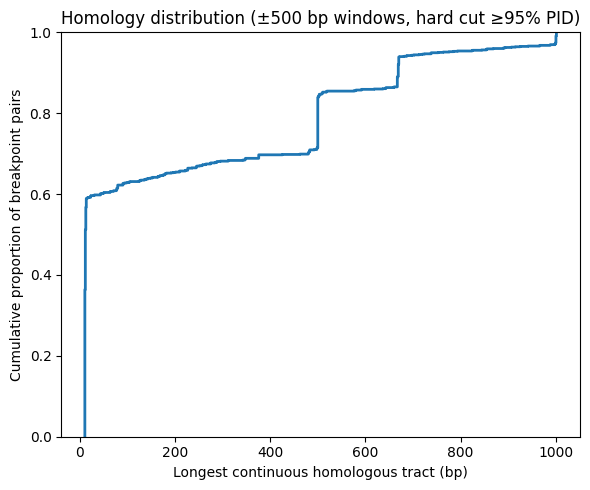

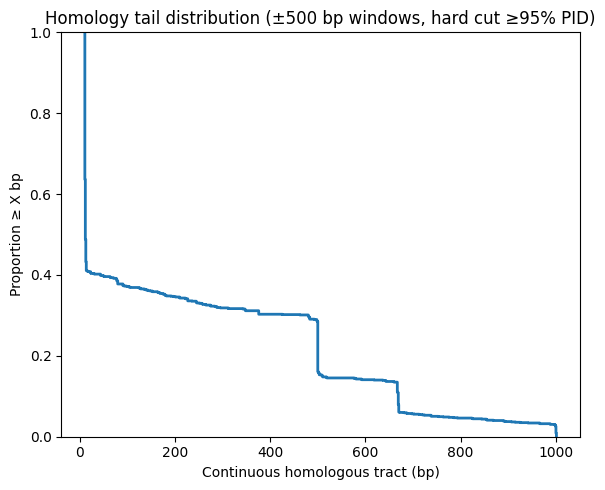


Summary of best tract length per pair:
count    1149.000000
mean      215.450827
std       292.565226
min        11.000000
25%        11.000000
50%        12.000000
75%       500.000000
max      1001.000000
Name: best_len, dtype: float64

Top 20 longest tracts:
     pair_id  best_len  best_pident
356      414    1001.0         99.8
354      411    1001.0         99.8
346      400    1001.0         99.8
572      737    1001.0         99.8
511      626    1001.0         99.8
658      866    1001.0         99.8
568      730    1001.0         99.8
325      371    1001.0         99.8
97       106    1001.0         99.8
965     1251    1001.0         99.8
472      548    1000.0        100.0
546      691    1000.0        100.0
548      693    1000.0        100.0
351      407    1000.0        100.0
510      622    1000.0        100.0
597      778    1000.0        100.0
502      611    1000.0        100.0
343      393    1000.0        100.0
481      558    1000.0         99.9
14        14    1

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# INPUTS
# ============================================================

TRACEABLE_HITS = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/pairwise_hits.tsv"
hw = 500
min_len = 0  # opcional; en hardcut_95pid el corte duro ya es por identidad, no por longitud

# ============================================================
# 1. LOAD
# ============================================================

df = pd.read_csv(TRACEABLE_HITS, sep="\t")

df = df[
    df["length"].notna() &
    (df["status"] == "ok")
].copy()

df["length"] = pd.to_numeric(df["length"], errors="coerce")
df["pident"] = pd.to_numeric(df["pident"], errors="coerce")

if min_len > 0:
    df = df[df["length"] >= min_len].copy()

# mejor HSP por pair
best = (
    df.groupby("pair_id", as_index=False)
      .agg(
          best_len=("length", "max"),
          best_pident=("pident", "max")
      )
)

print("N pairs with at least one BLAST hit:", len(best))

# ============================================================
# 2. ECDF
# ============================================================

plt.figure(figsize=(6, 5))

sns.ecdfplot(
    data=best,
    x="best_len",
    linewidth=2
)

plt.xlabel("Longest continuous homologous tract (bp)")
plt.ylabel("Cumulative proportion of breakpoint pairs")
plt.title(f"Homology distribution (±{hw} bp windows, hard cut ≥95% PID)")
plt.tight_layout()
plt.show()

# ============================================================
# 3. TAIL ECDF
# ============================================================

plt.figure(figsize=(6, 5))

sns.ecdfplot(
    data=best,
    x="best_len",
    complementary=True,
    linewidth=2
)

plt.xlabel("Continuous homologous tract (bp)")
plt.ylabel("Proportion ≥ X bp")
plt.title(f"Homology tail distribution (±{hw} bp windows, hard cut ≥95% PID)")
plt.tight_layout()
plt.show()

# ============================================================
# 4. QUICK NUMERIC CHECK
# ============================================================

print("\nSummary of best tract length per pair:")
print(best["best_len"].describe())

print("\nTop 20 longest tracts:")
print(best.sort_values("best_len", ascending=False).head(20))

Cluster: 29
N tracts: 281

Summary:
count    281.000000
mean     518.548043
std      136.189805
min       28.000000
25%      500.000000
50%      500.000000
75%      667.000000
max      825.000000
Name: length, dtype: float64


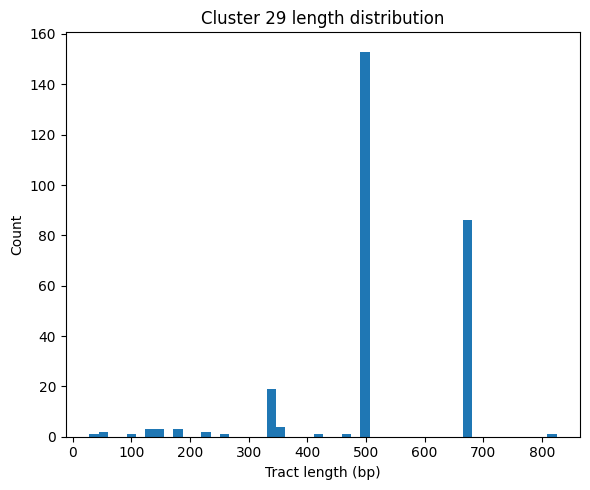

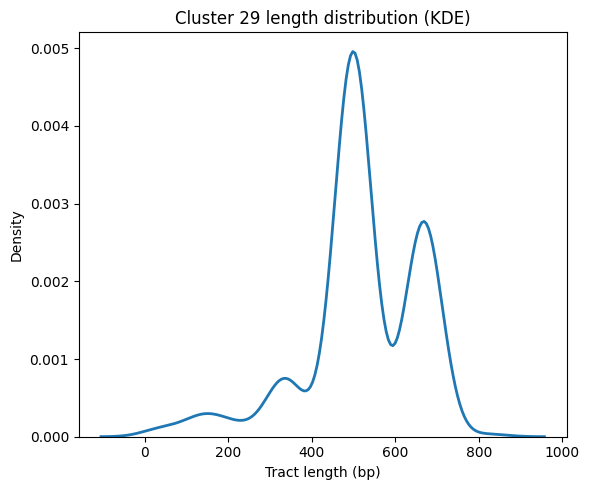


Top 10 longest:
     cluster  tract_id  pair_id        plasmid  length   pident
99        29      1323      868  NZ_ON390812.1     825   99.879
126       29      1392      895  NZ_CP065557.1     672   99.702
115       29      1370      884  NZ_CP032242.1     670  100.000
103       29      1346      873     CP050282.1     670  100.000
105       29      1350      874     CP050286.1     670  100.000
148       29      1437      914  NZ_CP102642.1     670   99.851
139       29      1419      906  NZ_CP095248.1     670  100.000
123       29      1386      893  NZ_CP064260.1     670  100.000
121       29      1382      892  NZ_CP064243.1     670  100.000
128       29      1396      896  NZ_CP066906.1     670  100.000

Top 10 shortest:
     cluster  tract_id  pair_id        plasmid  length   pident
157       29      1455      918  NZ_CP107293.1      28   96.429
177       29      1504      938  NZ_CP141070.1      44  100.000
86        29      1243      832  NZ_CP141070.1      44  100.000
272  

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# INPUTS
# ============================================================

TRACTS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/homologous_tracts.tsv"
CLUSTERS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/clusters_members.tsv"

CLUSTER_ID = 29

# ============================================================
# LOAD
# ============================================================

tracts = pd.read_csv(TRACTS_FILE, sep="\t")
cl = pd.read_csv(CLUSTERS_FILE, sep="\t")

# ============================================================
# SUBSET CLUSTER
# ============================================================

cl_sel = cl[cl["cluster"] == CLUSTER_ID].copy()

df = cl_sel.merge(
    tracts[["tract_id", "pair_id", "plasmid", "length", "pident"]],
    on=["tract_id", "pair_id", "plasmid"],
    how="left"
)

print("Cluster:", CLUSTER_ID)
print("N tracts:", len(df))

# ============================================================
# SUMMARY
# ============================================================

print("\nSummary:")
print(df["length"].describe())

# ============================================================
# HISTOGRAM
# ============================================================

plt.figure(figsize=(6, 5))
plt.hist(df["length"].dropna(), bins=50)

plt.xlabel("Tract length (bp)")
plt.ylabel("Count")
plt.title(f"Cluster {CLUSTER_ID} length distribution")
plt.tight_layout()
plt.show()

# ============================================================
# KDE
# ============================================================

if df["length"].notna().sum() > 1:
    plt.figure(figsize=(6, 5))

    sns.kdeplot(
        data=df,
        x="length",
        linewidth=2
    )

    plt.xlabel("Tract length (bp)")
    plt.ylabel("Density")
    plt.title(f"Cluster {CLUSTER_ID} length distribution (KDE)")
    plt.tight_layout()
    plt.show()

# ============================================================
# VER EJEMPLOS
# ============================================================

print("\nTop 10 longest:")
print(df.sort_values("length", ascending=False).head(10))

print("\nTop 10 shortest:")
print(df.sort_values("length", ascending=True).head(10))

Cluster usado: 29
N tracts: 281
Length range: 28 - 825

Summary:
count    281.000000
mean     518.548043
std      136.189805
min       28.000000
25%      500.000000
50%      500.000000
75%      667.000000
max      825.000000
Name: length, dtype: float64

Top 10 longest:
     cluster  tract_id  pair_id        plasmid  length   pident
99        29      1323      868  NZ_ON390812.1     825   99.879
126       29      1392      895  NZ_CP065557.1     672   99.702
115       29      1370      884  NZ_CP032242.1     670  100.000
103       29      1346      873     CP050282.1     670  100.000
105       29      1350      874     CP050286.1     670  100.000
148       29      1437      914  NZ_CP102642.1     670   99.851
139       29      1419      906  NZ_CP095248.1     670  100.000
123       29      1386      893  NZ_CP064260.1     670  100.000
121       29      1382      892  NZ_CP064243.1     670  100.000
128       29      1396      896  NZ_CP066906.1     670  100.000

Top 10 shortest:
     cl

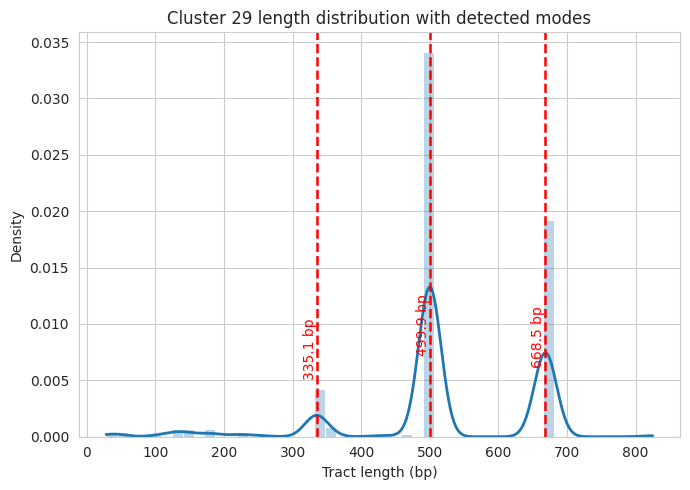


Representatives per mode:
   mode_id  mode_length_bp  tract_id  pair_id        plasmid  length   pident  \
0        0           499.9       287      140     AP022086.1     500  100.000   
1        1           668.5       217       96  NZ_CP017086.1     669  100.000   
2        2           335.1      1371      884  NZ_CP032242.1     334   99.701   

   dist_to_mode  
0          0.06  
1          0.45  
2          1.12  

Top candidates per mode:

--- Mode 0 (~499.9 bp) ---
   tract_id  pair_id      plasmid  length  pident  dist_to_mode
0       287      140   AP022086.1     500   100.0      0.058015
1       291      142   CP027485.1     500   100.0      0.058015
2       301      147   CP052139.1     500   100.0      0.058015
3       311      153   CP082572.1     500   100.0      0.058015
4       326      160   CP101349.1     500   100.0      0.058015
5       328      161   CP110735.1     500   100.0      0.058015
6       340      167   JX127248.1     500   100.0      0.058015
7       34

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

# ============================================================
# INPUTS
# ============================================================

TRACTS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/homologous_tracts.tsv"
CLUSTERS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/clusters_members.tsv"

CLUSTER_ID = 29

# parámetros de detección de picos
BW_METHOD = 0.12
PROMINENCE_FRAC = 0.08
MIN_PEAK_DISTANCE_GRID = 150
TOP_N_MODES = None   # por ejemplo 2 si quieres forzar solo las 2 modas principales

# ============================================================
# LOAD
# ============================================================

tracts = pd.read_csv(TRACTS_FILE, sep="\t")
cl = pd.read_csv(CLUSTERS_FILE, sep="\t")

# ============================================================
# REBUILD CLUSTER-SPECIFIC TABLE DESDE CERO
# ============================================================

cl_sel = cl[cl["cluster"] == CLUSTER_ID].copy()

df_cluster = cl_sel.merge(
    tracts[["tract_id", "pair_id", "plasmid", "length", "pident"]],
    on=["tract_id", "pair_id", "plasmid"],
    how="left"
)

# quitar entradas sin longitud
df_cluster = df_cluster.dropna(subset=["length"]).copy()
df_cluster["length"] = pd.to_numeric(df_cluster["length"], errors="coerce")
df_cluster = df_cluster.dropna(subset=["length"]).copy()

print("Cluster usado:", CLUSTER_ID)
print("N tracts:", len(df_cluster))
print("Length range:", df_cluster["length"].min(), "-", df_cluster["length"].max())

print("\nSummary:")
print(df_cluster["length"].describe())

print("\nTop 10 longest:")
print(df_cluster.sort_values("length", ascending=False).head(10))

print("\nTop 10 shortest:")
print(df_cluster.sort_values("length", ascending=True).head(10))

# ============================================================
# KDE EN ESCALA REAL
# ============================================================

lengths = df_cluster["length"].values

if len(lengths) < 3:
    raise ValueError("Muy pocos datos para estimar modas en este cluster.")

grid = np.linspace(lengths.min(), lengths.max(), 4000)
kde = gaussian_kde(lengths, bw_method=BW_METHOD)
density = kde(grid)

# ============================================================
# DETECCIÓN DE PICOS
# ============================================================

peaks, props = find_peaks(
    density,
    prominence=density.max() * PROMINENCE_FRAC,
    distance=MIN_PEAK_DISTANCE_GRID
)

if len(peaks) == 0:
    raise ValueError(
        "No se detectaron picos. Prueba a bajar PROMINENCE_FRAC o ajustar BW_METHOD."
    )

mode_lengths = grid[peaks]
peak_heights = density[peaks]
prominences = props["prominences"]

# ordenar por altura del pico
order = np.argsort(peak_heights)[::-1]
mode_lengths = mode_lengths[order]
peak_heights = peak_heights[order]
prominences = prominences[order]

# opcional: quedarse solo con top N
if TOP_N_MODES is not None:
    mode_lengths = mode_lengths[:TOP_N_MODES]
    peak_heights = peak_heights[:TOP_N_MODES]
    prominences = prominences[:TOP_N_MODES]

print("\nDetected modes (bp):", np.round(mode_lengths, 1))

modes_table = pd.DataFrame({
    "mode_id": range(len(mode_lengths)),
    "mode_length_bp": np.round(mode_lengths, 1),
    "peak_height": peak_heights,
    "prominence": prominences
})

print("\nModes table:")
print(modes_table)

# ============================================================
# PLOT
# ============================================================

sns.set_style("whitegrid")

plt.figure(figsize=(7, 5))
sns.histplot(lengths, bins=50, stat="density", alpha=0.3)
plt.plot(grid, density, linewidth=2)

for i, m in enumerate(mode_lengths):
    plt.axvline(m, color="red", linestyle="--", linewidth=1.8)
    plt.text(
        m,
        density.max() * (0.95 - i * 0.08),
        f"{m:.1f} bp",
        rotation=90,
        color="red",
        ha="right",
        va="top"
    )

plt.xlabel("Tract length (bp)")
plt.ylabel("Density")
plt.title(f"Cluster {CLUSTER_ID} length distribution with detected modes")
plt.tight_layout()
plt.show()

# ============================================================
# ASIGNAR CADA TRACT AL MODO MÁS CERCANO
# ============================================================

representatives = []

work = df_cluster.copy()

for i, mode in enumerate(mode_lengths):
    tmp = work.copy()
    tmp["dist_to_mode"] = np.abs(tmp["length"] - mode)

    best = tmp.sort_values(
        ["dist_to_mode", "pident", "length"],
        ascending=[True, False, False]
    ).iloc[0]

    representatives.append({
        "mode_id": i,
        "mode_length_bp": round(mode, 1),
        "tract_id": best["tract_id"],
        "pair_id": best["pair_id"],
        "plasmid": best["plasmid"],
        "length": best["length"],
        "pident": best["pident"],
        "dist_to_mode": round(best["dist_to_mode"], 2)
    })

rep_df = pd.DataFrame(representatives)

print("\nRepresentatives per mode:")
print(rep_df)

# ============================================================
# OPCIONAL: VER TODOS LOS TRACTS ORDENADOS POR CERCANÍA A CADA MODO
# ============================================================

all_assignments = []

for i, mode in enumerate(mode_lengths):
    tmp = work.copy()
    tmp["mode_id"] = i
    tmp["mode_length_bp"] = round(mode, 1)
    tmp["dist_to_mode"] = np.abs(tmp["length"] - mode)
    tmp = tmp.sort_values(["dist_to_mode", "pident"], ascending=[True, False])

    all_assignments.append(tmp)

assignments_df = pd.concat(all_assignments, ignore_index=True)

print("\nTop candidates per mode:")
for i in range(len(mode_lengths)):
    print(f"\n--- Mode {i} (~{mode_lengths[i]:.1f} bp) ---")
    print(
        assignments_df[assignments_df["mode_id"] == i][
            ["tract_id", "pair_id", "plasmid", "length", "pident", "dist_to_mode"]
        ].head(10)
    )

    cluster  n_sequences  cluster_rank
0        29          281             1
1        73           21             2
2        87           20             3
3        71           12             4
4        60           12             5
5        77           11             6
6        61           10             7
7        10           10             8
8        69            8             9
9        74            6            10
10       55            6            11
11       86            5            12
12       97            5            13
13       72            4            14
14       17            4            15
15       16            4            16
16       79            4            17
17       22            3            18
18        1            3            19
19       12            3            20


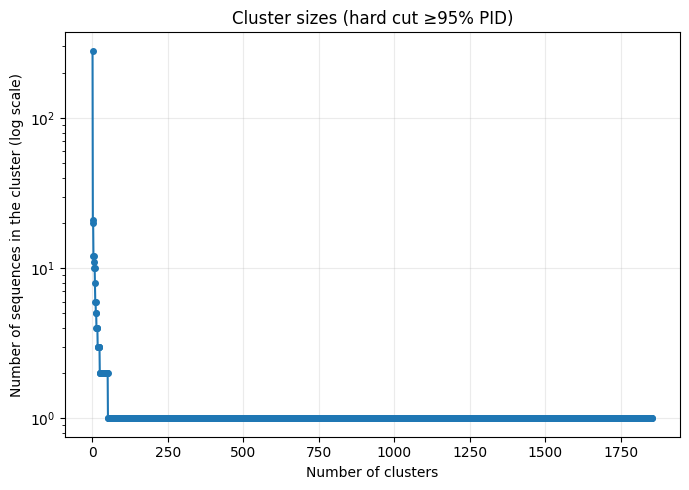

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

CLUSTERS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/clusters_members.tsv"

cl = pd.read_csv(CLUSTERS_FILE, sep="\t")

# tamaño de cada cluster
cluster_sizes = (
    cl.groupby("cluster")
      .size()
      .reset_index(name="n_sequences")
      .sort_values("n_sequences", ascending=False)
      .reset_index(drop=True)
)

cluster_sizes["cluster_rank"] = range(1, len(cluster_sizes) + 1)

print(cluster_sizes.head(20))

plt.figure(figsize=(7, 5))
plt.plot(
    cluster_sizes["cluster_rank"],
    cluster_sizes["n_sequences"],
    marker="o",
    linewidth=1.5,
    markersize=4
)

plt.yscale("log")
plt.xlabel("Number of clusters")
plt.ylabel("Number of sequences in the cluster (log scale)")
plt.title("Cluster sizes (hard cut ≥95% PID)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


Distance-to-breakpoint summary by cluster:
   cluster  count        mean         std    min    25%    50%    75%    max
0       10   20.0    0.000000    0.000000    0.0    0.0    0.0    0.0    0.0
1       29  562.0   22.297153   76.637296    0.0    0.0    1.0    1.0  473.0
2       60   24.0    9.625000    9.876685    0.0    0.0    9.0   18.5   21.0
3       61   20.0   62.500000   64.123647    0.0    0.0   62.5  125.0  125.0
4       71   24.0  367.083333   66.197936  255.0  291.0  393.0  423.0  430.0
5       73   42.0   66.190476  107.050760    0.0    1.0    7.0   68.0  359.0
6       77   22.0  366.636364   51.645813  309.0  326.0  348.0  398.5  457.0
7       87   40.0  169.250000  139.360030    0.0   42.0  121.5  373.0  424.0

Fraction of tracts overlapping the breakpoint:
   cluster  fraction_overlapping_breakpoint
0       10                         1.000000
1       29                         0.389680
2       60                         0.500000
3       61                         0.50

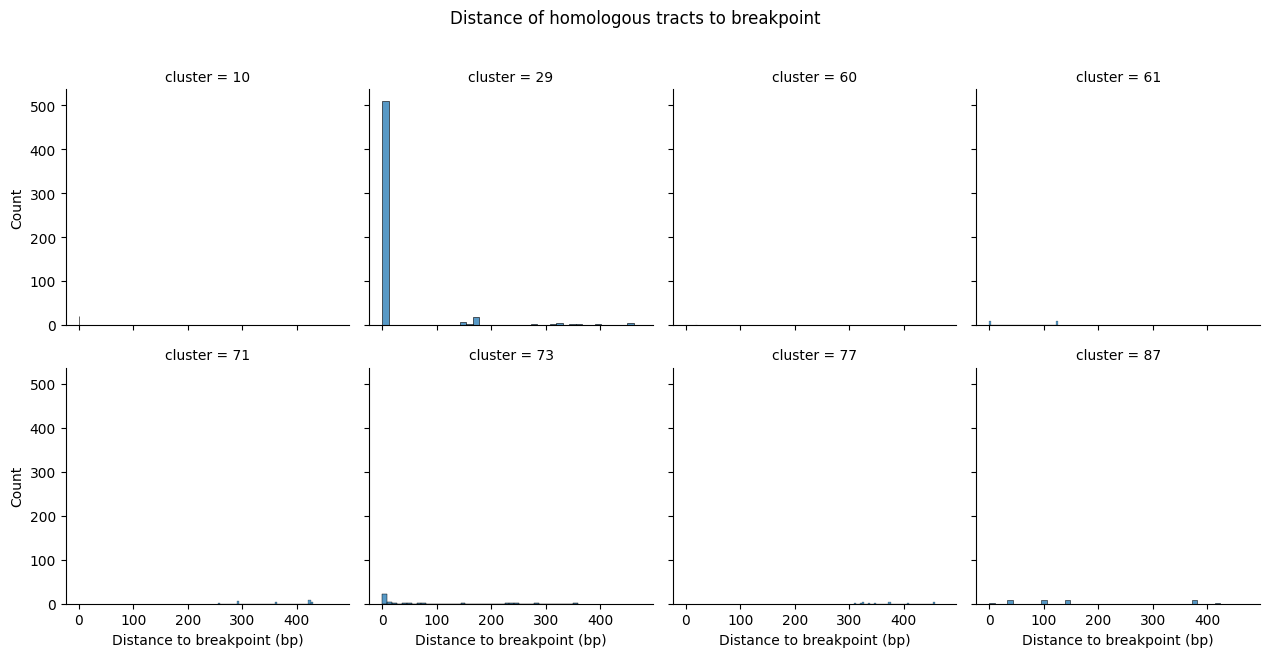

/home/nacho/.local/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)


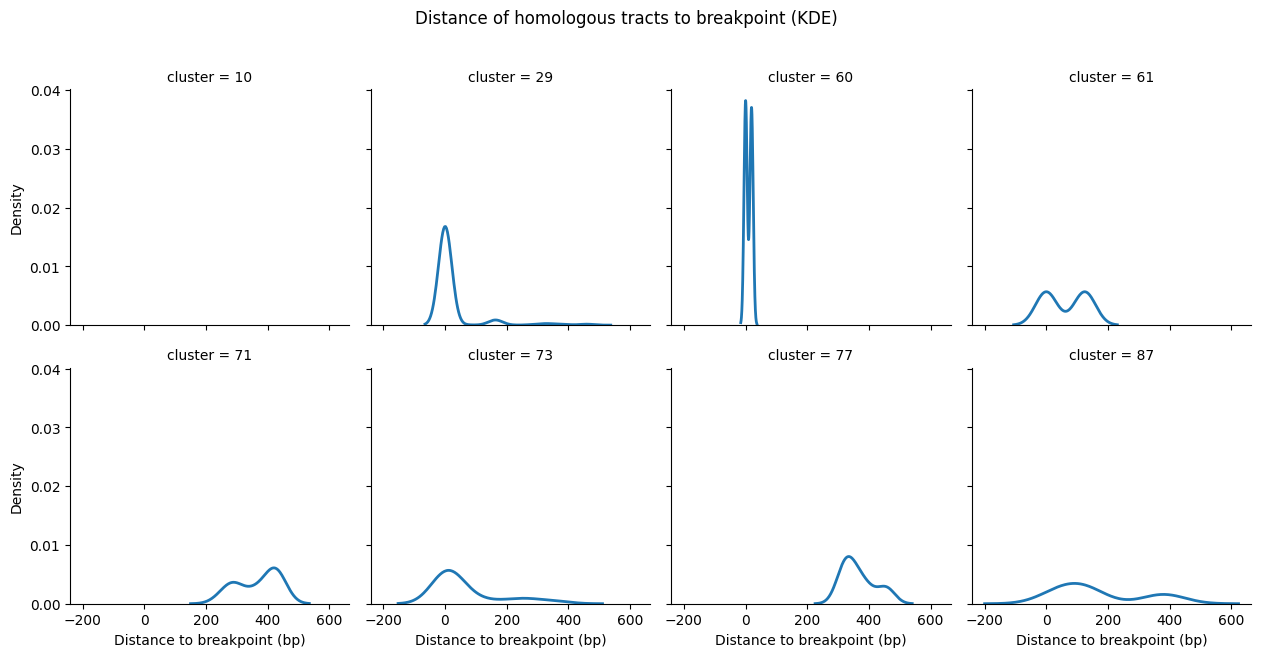

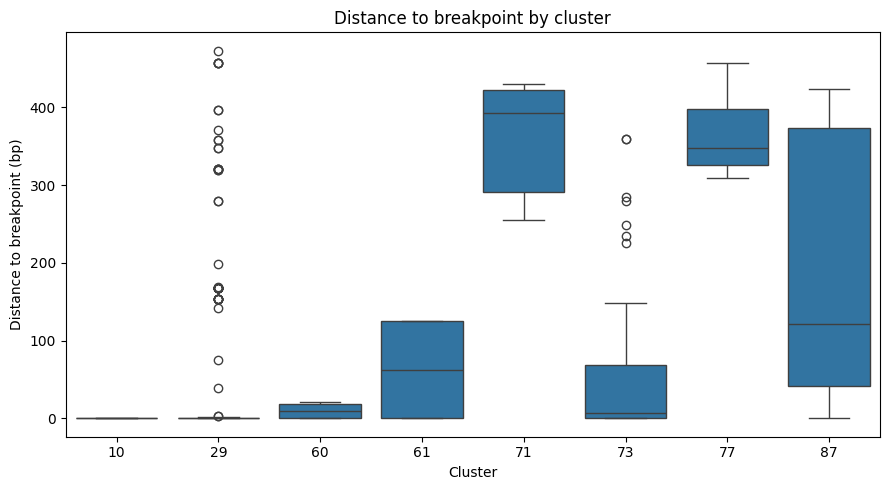

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# INPUTS
# ============================================================

TRACTS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/homologous_tracts.tsv"
CLUSTERS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/clusters_members.tsv"

WINDOW_HW = 500
BREAKPOINT_WINPOS = WINDOW_HW + 1

TARGET_CLUSTERS = [29, 73, 87, 71, 60, 77, 61, 10]

# ============================================================
# HELPERS
# ============================================================

def interval_to_breakpoint_metrics(start, end, bp):
    start = int(start)
    end = int(end)
    inside = (start <= bp <= end)
    min_dist = 0 if inside else min(abs(start - bp), abs(end - bp))
    center = (start + end) / 2
    center_signed = center - bp
    return {
        "bp_inside": inside,
        "dist_min_to_bp": min_dist,
        "dist_start_to_bp": start - bp,
        "dist_end_to_bp": end - bp,
        "dist_center_to_bp": center_signed,
    }

# ============================================================
# LOAD
# ============================================================

tracts = pd.read_csv(TRACTS_FILE, sep="\t")
cl = pd.read_csv(CLUSTERS_FILE, sep="\t")

# ============================================================
# SUBSET + MERGE
# ============================================================

cl_sel = cl[cl["cluster"].isin(TARGET_CLUSTERS)].copy()

x = cl_sel.merge(
    tracts,
    on=["tract_id", "pair_id", "plasmid"],
    how="left"
)

# métricas respecto al breakpoint de la ventana start
start_metrics = x.apply(
    lambda r: pd.Series(interval_to_breakpoint_metrics(r["qstart"], r["qend"], BREAKPOINT_WINPOS)),
    axis=1
).add_prefix("start_")

# métricas respecto al breakpoint de la ventana end
end_metrics = x.apply(
    lambda r: pd.Series(interval_to_breakpoint_metrics(r["sstart"], r["send"], BREAKPOINT_WINPOS)),
    axis=1
).add_prefix("end_")

dist = pd.concat([x, start_metrics, end_metrics], axis=1)

# formato largo para plotear ambas arms juntas
plot_df = pd.concat([
    dist[["cluster", "tract_id", "pair_id", "plasmid", "length", "pident", "start_dist_min_to_bp"]]
        .rename(columns={"start_dist_min_to_bp": "dist_min_to_bp"})
        .assign(side="start"),
    dist[["cluster", "tract_id", "pair_id", "plasmid", "length", "pident", "end_dist_min_to_bp"]]
        .rename(columns={"end_dist_min_to_bp": "dist_min_to_bp"})
        .assign(side="end")
], ignore_index=True)

# ============================================================
# SUMMARY
# ============================================================

summary = (
    plot_df.groupby("cluster")["dist_min_to_bp"]
    .describe()
    .reset_index()
)

print("\nDistance-to-breakpoint summary by cluster:")
print(summary)

inside_summary = (
    pd.concat([
        dist[["cluster", "start_bp_inside"]].rename(columns={"start_bp_inside": "bp_inside"}),
        dist[["cluster", "end_bp_inside"]].rename(columns={"end_bp_inside": "bp_inside"})
    ], ignore_index=True)
    .groupby("cluster")["bp_inside"]
    .mean()
    .reset_index(name="fraction_overlapping_breakpoint")
)

print("\nFraction of tracts overlapping the breakpoint:")
print(inside_summary)

# ============================================================
# HISTOGRAMS
# ============================================================

g = sns.FacetGrid(
    plot_df,
    col="cluster",
    col_wrap=4,
    sharex=True,
    sharey=True,
    height=3.2
)

g.map_dataframe(
    sns.histplot,
    x="dist_min_to_bp",
    bins=40
)

for ax in g.axes.flatten():
    ax.set_xlabel("Distance to breakpoint (bp)")
    ax.set_ylabel("Count")

g.fig.suptitle("Distance of homologous tracts to breakpoint", y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# KDE
# ============================================================

g = sns.FacetGrid(
    plot_df,
    col="cluster",
    col_wrap=4,
    sharex=True,
    sharey=True,
    height=3.2
)

g.map_dataframe(
    sns.kdeplot,
    x="dist_min_to_bp",
    linewidth=2
)

for ax in g.axes.flatten():
    ax.set_xlabel("Distance to breakpoint (bp)")
    ax.set_ylabel("Density")

g.fig.suptitle("Distance of homologous tracts to breakpoint (KDE)", y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# BOXPLOT COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=plot_df,
    x="cluster",
    y="dist_min_to_bp"
)

plt.xlabel("Cluster")
plt.ylabel("Distance to breakpoint (bp)")
plt.title("Distance to breakpoint by cluster")
plt.tight_layout()
plt.show()

Cluster: 73
N tracts: 21

Summary:
count     21.000000
mean      42.523810
std       61.885878
min       18.000000
25%       23.000000
50%       23.000000
75%       24.000000
max      236.000000
Name: length, dtype: float64


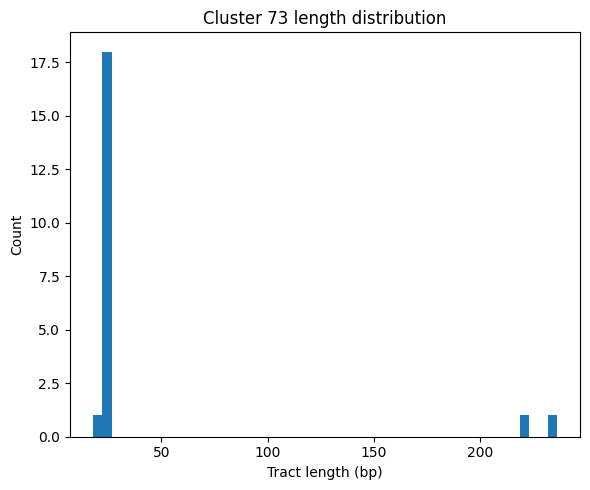

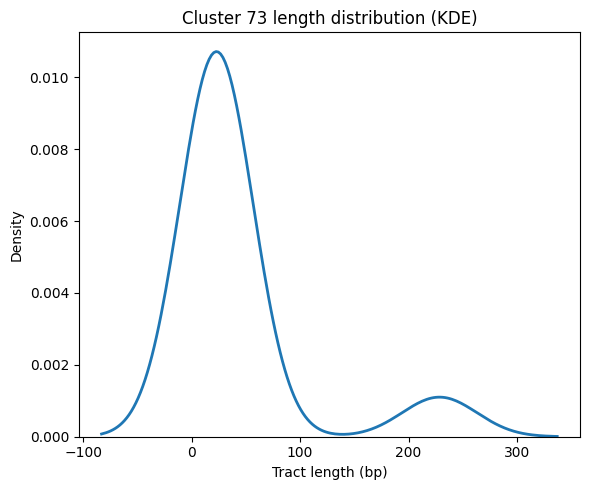


Top 10 longest:
    cluster  tract_id  pair_id        plasmid  length  pident
17       73      2195     1439  NZ_CP092545.1     236   100.0
18       73      2196     1439  NZ_CP092545.1     221   100.0
5        73       983      562  NZ_CP016166.1      24   100.0
6        73       987      563  NZ_CP066571.1      24   100.0
10       73      1091      677    NC_004669.1      24   100.0
9        73      1088      676     LR962104.1      24   100.0
4        73       979      561     CP063577.1      23   100.0
2        73       679      356     LR962022.1      23   100.0
1        73        13        7  NZ_OR095737.1      23   100.0
0        73         8        4  NZ_CP096212.1      23   100.0

Top 10 shortest:
    cluster  tract_id  pair_id        plasmid  length  pident
8        73      1011      578  NZ_PP589663.1      18   100.0
0        73         8        4  NZ_CP096212.1      23   100.0
2        73       679      356     LR962022.1      23   100.0
1        73        13        7  NZ_

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# INPUTS
# ============================================================

TRACTS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/homologous_tracts.tsv"
CLUSTERS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/clusters_members.tsv"

CLUSTER_ID = 73

# ============================================================
# LOAD
# ============================================================

tracts = pd.read_csv(TRACTS_FILE, sep="\t")
cl = pd.read_csv(CLUSTERS_FILE, sep="\t")

# ============================================================
# SUBSET CLUSTER
# ============================================================

cl_sel = cl[cl["cluster"] == CLUSTER_ID].copy()

df = cl_sel.merge(
    tracts[["tract_id", "pair_id", "plasmid", "length", "pident"]],
    on=["tract_id", "pair_id", "plasmid"],
    how="left"
)

print("Cluster:", CLUSTER_ID)
print("N tracts:", len(df))

# ============================================================
# SUMMARY
# ============================================================

print("\nSummary:")
print(df["length"].describe())

# ============================================================
# HISTOGRAM
# ============================================================

plt.figure(figsize=(6, 5))
plt.hist(df["length"].dropna(), bins=50)

plt.xlabel("Tract length (bp)")
plt.ylabel("Count")
plt.title(f"Cluster {CLUSTER_ID} length distribution")
plt.tight_layout()
plt.show()

# ============================================================
# KDE
# ============================================================

if df["length"].notna().sum() > 1:
    plt.figure(figsize=(6, 5))

    sns.kdeplot(
        data=df,
        x="length",
        linewidth=2
    )

    plt.xlabel("Tract length (bp)")
    plt.ylabel("Density")
    plt.title(f"Cluster {CLUSTER_ID} length distribution (KDE)")
    plt.tight_layout()
    plt.show()

# ============================================================
# VER EJEMPLOS
# ============================================================

print("\nTop 10 longest:")
print(df.sort_values("length", ascending=False).head(10))

print("\nTop 10 shortest:")
print(df.sort_values("length", ascending=True).head(10))

In [49]:
import pandas as pd
from Bio import SeqIO

# ============================================================
# INPUTS
# ============================================================

CLUSTERS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/clusters_members.tsv"
TRACTS_FASTA = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500/tracts_unique.fa"

CLUSTER_ID = 73

# ============================================================
# LOAD CLUSTER MEMBERS
# ============================================================

cl = pd.read_csv(CLUSTERS_FILE, sep="\t")
cl73 = cl[cl["cluster"] == CLUSTER_ID].copy()

print("N members in cluster:", len(cl73))
print(cl73.head())

# coger el primer tract_id del cluster
target_tract_id = int(cl73.iloc[0]["tract_id"])
print("\nRepresentative tract_id:", target_tract_id)

# ============================================================
# FIND SEQUENCE IN FASTA
# ============================================================

target_record = None

for rec in SeqIO.parse(TRACTS_FASTA, "fasta"):
    if f"tract={target_tract_id}|" in rec.id:
        target_record = rec
        break

if target_record is None:
    print("No sequence found for tract_id", target_tract_id)
else:
    print("\nHeader:")
    print(target_record.id)
    print("\nLength:")
    print(len(target_record.seq))
    print("\nSequence:")
    print(str(target_record.seq))

N members in cluster: 21
     cluster  tract_id  pair_id        plasmid
450       73         8        4  NZ_CP096212.1
451       73        13        7  NZ_OR095737.1
452       73       679      356     LR962022.1
453       73       767      412     CP130848.1
454       73       979      561     CP063577.1

Representative tract_id: 8

Header:
tract=8|pair=4|plasmid=NZ_CP096212.1|bp_start=8|bp_end=9|len=23|pid=100.000

Length:
23

Sequence:
ATTTAAAACTTTGCAACAGAACC


# V3 #

In [53]:
#!/usr/bin/env python3

import os
import re
import csv
import shutil
import subprocess
from multiprocessing import Pool, cpu_count

import pandas as pd
from Bio import SeqIO
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
NUCMER_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/containment_mm2/nucmer"
GRAPH_DIR = os.path.join(NUCMER_DIR, "graph_cov90_noclose")
CONTAINMENT_FILE = os.path.join(GRAPH_DIR, "containment_NUC_levelup_strictlen.tsv")

PLASMID_FASTA_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/raw_fastas"
SAMTOOLS = "/home/nacho/mambaforge/envs/samtools/bin/samtools"
BLASTN = "/home/nacho/mambaforge/envs/blast/bin/blastn"
CDHITEST = "/home/nacho/mambaforge/envs/cd-hit/bin/cd-hit-est"

WINDOW_HW = 500
BREAKPOINT_WINPOS = WINDOW_HW + 1

MIN_PID = 95.0
TOP_N = 3
CDHIT_ID = 0.95
CDHIT_WORD = 10

N_CORES = max(1, cpu_count() - 2)

OUTDIR = os.path.join(BASE_DIR, f"TRACEABLE_hardcut_95pid_{WINDOW_HW}_onebest_per_pair")
WINDOWS_DIR = os.path.join(OUTDIR, "windows")
BLAST_DIR = os.path.join(OUTDIR, "pairwise_blast")

MASTER_TSV = os.path.join(OUTDIR, "breakpoints_master.tsv")
MULTIFASTA = os.path.join(OUTDIR, "breakpoints_windows.fa")
PAIRWISE_TSV = os.path.join(OUTDIR, "pairwise_hits.tsv")
TRACTS_TSV = os.path.join(OUTDIR, "homologous_tracts.tsv")
TRACTS_FASTA = os.path.join(OUTDIR, "homologous_tracts.fa")
TRACTS_UNIQUE_FASTA = os.path.join(OUTDIR, "tracts_unique.fa")

CDHIT_OUT_FASTA = os.path.join(OUTDIR, "homologous_tracts_cdhit_95.fa")
CDHIT_OUT_CLSTR = CDHIT_OUT_FASTA + ".clstr"

CLUSTERS_MEMBERS_TSV = os.path.join(OUTDIR, "clusters_members.tsv")
CLUSTERS_SIZES_TSV = os.path.join(OUTDIR, "clusters_sizes.tsv")
TOP_DIST_TSV = os.path.join(OUTDIR, "top3_clusters_distance_to_breakpoint.tsv")
TOP_DIST_PNG = os.path.join(OUTDIR, "top3_clusters_distance_to_breakpoint.png")

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(WINDOWS_DIR, exist_ok=True)
os.makedirs(BLAST_DIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def parse_cov90_line(line):
    toks = re.split(r"\s+", line.strip())
    if len(toks) < 14:
        return None
    try:
        return {
            "s1": int(toks[0]),
            "e1": int(toks[1]),
            "s2": int(toks[2]),
            "e2": int(toks[3]),
            "len1": int(toks[4]),
            "len2": int(toks[5]),
            "lenR": int(toks[7]),
            "lenQ": int(toks[8]),
            "ref": toks[11],
            "qry": toks[12],
            "raw": line.strip(),
        }
    except Exception:
        return None

def get_cov90_path(src):
    p1 = os.path.join(NUCMER_DIR, src)
    if os.path.exists(p1):
        return p1
    p2 = os.path.join(GRAPH_DIR, os.path.basename(src))
    if os.path.exists(p2):
        return p2
    raise FileNotFoundError(f"No encuentro cov90 para: {src}")

def get_fasta_path(chrom):
    for fname in os.listdir(PLASMID_FASTA_DIR):
        if fname.endswith((".fna", ".fa", ".fasta")) and fname.startswith(chrom):
            return os.path.join(PLASMID_FASTA_DIR, fname)
    return None

def get_length_from_fasta(fasta):
    fai = fasta + ".fai"
    if not os.path.exists(fai):
        subprocess.run([SAMTOOLS, "faidx", fasta], check=True)
    with open(fai) as f:
        return int(f.readline().split("\t")[1])

def circular_window(center, L, hw):
    start = center - hw
    end = center + hw

    if start >= 1 and end <= L:
        return [(start, end)]
    if start < 1:
        return [(L + start + 1, L), (1, end)]
    if end > L:
        return [(start, L), (1, end - L)]
    return None

def fetch_sequence(fasta, chrom, parts):
    seq = []
    for s, e in parts:
        region = f"{chrom}:{s}-{e}"
        out = subprocess.check_output([SAMTOOLS, "faidx", fasta, region]).decode()
        seq.append("".join(out.split("\n")[1:]))
    return "".join(seq)

def run_blast_job(job):
    pair_id, plasmid, fa_start, fa_end, start_header, end_header, bp_start, bp_end = job
    out_file = os.path.join(BLAST_DIR, f"pair_{pair_id:05d}.blast.tsv")

    cmd = [
        BLASTN,
        "-query", fa_start,
        "-subject", fa_end,
        "-task", "blastn",
        "-dust", "no",
        "-soft_masking", "false",
        "-perc_identity", str(MIN_PID),
        "-outfmt", "6 qseqid sseqid qstart qend sstart send length pident mismatch gapopen evalue bitscore",
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        return [{
            "pair_id": pair_id,
            "plasmid": plasmid,
            "bp_start_index": bp_start,
            "bp_end_index": bp_end,
            "start_header": start_header,
            "end_header": end_header,
            "status": "error",
            "qseqid": None,
            "sseqid": None,
            "qstart": None,
            "qend": None,
            "sstart": None,
            "send": None,
            "length": None,
            "pident": None,
            "mismatch": None,
            "gapopen": None,
            "evalue": None,
            "bitscore": None,
            "blast_file": out_file,
            "stderr": result.stderr.strip(),
        }]

    with open(out_file, "w") as f:
        f.write(result.stdout)

    rows = []
    if result.stdout.strip():
        for line in result.stdout.strip().split("\n"):
            toks = line.split("\t")
            rows.append({
                "pair_id": pair_id,
                "plasmid": plasmid,
                "bp_start_index": bp_start,
                "bp_end_index": bp_end,
                "start_header": start_header,
                "end_header": end_header,
                "status": "ok",
                "qseqid": toks[0],
                "sseqid": toks[1],
                "qstart": int(toks[2]),
                "qend": int(toks[3]),
                "sstart": int(toks[4]),
                "send": int(toks[5]),
                "length": int(toks[6]),
                "pident": float(toks[7]),
                "mismatch": int(toks[8]),
                "gapopen": int(toks[9]),
                "evalue": toks[10],
                "bitscore": float(toks[11]),
                "blast_file": out_file,
                "stderr": "",
            })
    else:
        rows.append({
            "pair_id": pair_id,
            "plasmid": plasmid,
            "bp_start_index": bp_start,
            "bp_end_index": bp_end,
            "start_header": start_header,
            "end_header": end_header,
            "status": "ok",
            "qseqid": None,
            "sseqid": None,
            "qstart": None,
            "qend": None,
            "sstart": None,
            "send": None,
            "length": None,
            "pident": None,
            "mismatch": None,
            "gapopen": None,
            "evalue": None,
            "bitscore": None,
            "blast_file": out_file,
            "stderr": "",
        })
    return rows

def interval_to_breakpoint_metrics(start, end, bp):
    start = int(start)
    end = int(end)
    inside = (start <= bp <= end)
    min_dist = 0 if inside else min(abs(start - bp), abs(end - bp))
    center = (start + end) / 2
    center_signed = center - bp
    return {
        "bp_inside": inside,
        "dist_min_to_bp": min_dist,
        "dist_start_to_bp": start - bp,
        "dist_end_to_bp": end - bp,
        "dist_center_to_bp": center_signed,
    }

def parse_cluster_header(header):
    tract = re.search(r"tract=(\d+)", header)
    pair = re.search(r"pair=(\d+)", header)
    plasmid = re.search(r"plasmid=([^|]+)", header)
    return {
        "tract_id": int(tract.group(1)) if tract else None,
        "pair_id": int(pair.group(1)) if pair else None,
        "plasmid": plasmid.group(1) if plasmid else None,
    }

# ============================================================
# 1. BUILD TRACEABLE WINDOWS
# ============================================================

print("\n[1/7] Building traceable windows...")

rows = []
pair_id = 0
bp_index = 0

with open(CONTAINMENT_FILE) as f:
    rdr = csv.DictReader(f, delimiter="\t")
    for row in rdr:
        big_len = int(row["big_len"])
        cov_path = get_cov90_path(row["source_file"])

        found = False
        with open(cov_path) as fh:
            for lineno, line in enumerate(fh, 1):
                parsed = parse_cov90_line(line)
                if not parsed:
                    continue

                if parsed["lenR"] == big_len:
                    chrom = parsed["ref"]
                    s = min(parsed["s1"], parsed["e1"])
                    e = max(parsed["s1"], parsed["e1"])
                elif parsed["lenQ"] == big_len:
                    chrom = parsed["qry"]
                    s = min(parsed["s2"], parsed["e2"])
                    e = max(parsed["s2"], parsed["e2"])
                else:
                    continue

                fasta = get_fasta_path(chrom)
                if fasta is None:
                    print(f"[WARN] No FASTA for {chrom}")
                    break

                real_L = get_length_from_fasta(fasta)

                for bp_kind, pos in [("start", s), ("end", e)]:
                    parts = circular_window(pos, real_L, WINDOW_HW)
                    if not parts:
                        continue

                    seq = fetch_sequence(fasta, chrom, parts)
                    header = f"pair={pair_id}|bp={bp_index}|plasmid={chrom}|kind={bp_kind}|pos={pos}|hw={WINDOW_HW}"

                    fa_path = os.path.join(WINDOWS_DIR, f"bp_{bp_index}.fa")
                    with open(fa_path, "w") as out:
                        out.write(f">{header}\n{seq}\n")

                    rows.append({
                        "pair_id": pair_id,
                        "bp_index": bp_index,
                        "plasmid": chrom,
                        "breakpoint_pos": pos,
                        "bp_kind": bp_kind,
                        "plasmid_len": real_L,
                        "window_hw": WINDOW_HW,
                        "source_file": row["source_file"],
                        "containment_query": row["query_id"],
                        "containment_target": row["target_id"],
                        "cov_line_number": lineno,
                        "fasta_header": header,
                        "fasta_path": fa_path,
                    })
                    bp_index += 1

                pair_id += 1
                found = True
                break

        if not found:
            print(f"[WARN] No valid alignment for {row['query_id']} vs {row['target_id']}")

master = pd.DataFrame(rows)
master.to_csv(MASTER_TSV, sep="\t", index=False)

with open(MULTIFASTA, "w") as out:
    for _, r in master.sort_values("bp_index").iterrows():
        with open(r["fasta_path"]) as f:
            out.write(f.read())

print(f"Breakpoints: {len(master)} | Pairs: {master['pair_id'].nunique()}")
print(f"Wrote: {MASTER_TSV}")
print(f"Wrote: {MULTIFASTA}")

# ============================================================
# 2. BLAST START VS END FOR EACH PAIR
# ============================================================

print("\n[2/7] Running pairwise BLAST...")

m_start = master[master["bp_kind"] == "start"].copy()
m_end = master[master["bp_kind"] == "end"].copy()

pairs = m_start.merge(
    m_end,
    on=["pair_id", "plasmid"],
    suffixes=("_start", "_end")
)

jobs = []
for _, r in pairs.iterrows():
    jobs.append((
        int(r["pair_id"]),
        r["plasmid"],
        r["fasta_path_start"],
        r["fasta_path_end"],
        r["fasta_header_start"],
        r["fasta_header_end"],
        int(r["bp_index_start"]),
        int(r["bp_index_end"]),
    ))

all_rows = []
with Pool(N_CORES) as pool:
    for res in pool.map(run_blast_job, jobs):
        all_rows.extend(res)

pairwise = pd.DataFrame(all_rows)
pairwise.to_csv(PAIRWISE_TSV, sep="\t", index=False)

print(pairwise["status"].value_counts(dropna=False))
print(f"Wrote: {PAIRWISE_TSV}")

# ============================================================
# 3. KEEP ONLY THE LONGEST HIT PER BREAKPOINT PAIR
# ============================================================

print("\n[3/7] Extracting longest homologous tract per breakpoint pair...")

hits = pairwise[
    pairwise["length"].notna() &
    (pairwise["pident"] >= MIN_PID)
].copy()

hits["length"] = hits["length"].astype(int)
hits["qstart"] = hits["qstart"].astype(int)
hits["qend"] = hits["qend"].astype(int)
hits["sstart"] = hits["sstart"].astype(int)
hits["send"] = hits["send"].astype(int)
hits["pident"] = hits["pident"].astype(float)
hits["bitscore"] = hits["bitscore"].astype(float)

hits_best = (
    hits.sort_values(
        ["pair_id", "plasmid", "length", "pident", "bitscore"],
        ascending=[True, True, False, False, False]
    )
    .drop_duplicates(subset=["pair_id", "plasmid"], keep="first")
    .copy()
)

bp_meta = master.set_index("bp_index").to_dict(orient="index")
seq_cache = {}

def load_seq(path):
    if path not in seq_cache:
        rec = next(SeqIO.parse(path, "fasta"))
        seq_cache[path] = str(rec.seq)
    return seq_cache[path]

rows = []
fasta_records = []
tract_id = 0

for _, r in hits_best.iterrows():
    bp_start = int(r["bp_start_index"])
    bp_end = int(r["bp_end_index"])

    meta_start = bp_meta[bp_start]
    meta_end = bp_meta[bp_end]

    seq_start_full = load_seq(meta_start["fasta_path"])
    seq_end_full = load_seq(meta_end["fasta_path"])

    q1, q2 = sorted([int(r["qstart"]), int(r["qend"])])
    s1, s2 = sorted([int(r["sstart"]), int(r["send"])])

    seq_start = seq_start_full[q1-1:q2]
    seq_end = seq_end_full[s1-1:s2]

    tract_name = (
        f"tract={tract_id}|pair={int(r['pair_id'])}|plasmid={r['plasmid']}"
        f"|bp_start={bp_start}|bp_end={bp_end}|len={int(r['length'])}|pid={r['pident']:.3f}"
    )

    rows.append({
        "tract_id": tract_id,
        "pair_id": int(r["pair_id"]),
        "plasmid": r["plasmid"],
        "bp_start_index": bp_start,
        "bp_end_index": bp_end,
        "bp_start_pos": meta_start["breakpoint_pos"],
        "bp_end_pos": meta_end["breakpoint_pos"],
        "qstart": q1,
        "qend": q2,
        "sstart": s1,
        "send": s2,
        "length": int(r["length"]),
        "pident": float(r["pident"]),
        "bitscore": float(r["bitscore"]),
        "seq_start": seq_start,
        "seq_end": seq_end,
        "start_header": r["start_header"],
        "end_header": r["end_header"],
        "tract_name": tract_name,
    })

    fasta_records.append(f">{tract_name}|side=start\n{seq_start}\n")
    fasta_records.append(f">{tract_name}|side=end\n{seq_end}\n")

    tract_id += 1

tracts = pd.DataFrame(rows)
tracts.to_csv(TRACTS_TSV, sep="\t", index=False)

with open(TRACTS_FASTA, "w") as f:
    for rec in fasta_records:
        f.write(rec)

print(f"Longest tracts retained: {len(tracts)}")
print(f"Unique breakpoint pairs retained: {tracts[['pair_id', 'plasmid']].drop_duplicates().shape[0]}")
print(f"Wrote: {TRACTS_TSV}")
print(f"Wrote: {TRACTS_FASTA}")

# ============================================================
# 4. UNIQUE TRACTS FASTA + CD-HIT
# ============================================================

print("\n[4/7] Preparing unique tract FASTA and clustering...")

with open(TRACTS_UNIQUE_FASTA, "w") as out:
    for _, r in tracts.iterrows():
        out.write(f">{r['tract_name']}\n{r['seq_start']}\n")

if not shutil.which(CDHITEST) and not os.path.exists(CDHITEST):
    raise FileNotFoundError(f"No encuentro cd-hit-est en {CDHITEST}")

subprocess.run([
    CDHITEST,
    "-i", TRACTS_UNIQUE_FASTA,
    "-o", CDHIT_OUT_FASTA,
    "-c", str(CDHIT_ID),
    "-n", str(CDHIT_WORD),
    "-d", "0",
    "-M", "0",
    "-T", str(N_CORES),
], check=True)

print(f"Wrote: {CDHIT_OUT_FASTA}")
print(f"Wrote: {CDHIT_OUT_CLSTR}")

# ============================================================
# 5. PARSE CLUSTERS
# ============================================================

print("\n[5/7] Parsing clusters...")

cluster_rows = []
cluster_id = None

with open(CDHIT_OUT_CLSTR) as f:
    for line in f:
        line = line.strip()
        if line.startswith(">Cluster"):
            cluster_id = int(line.split()[1])
            continue

        m = re.search(r">(.+?)\.\.\.", line)
        if not m:
            continue

        header = m.group(1)
        info = parse_cluster_header(header)
        cluster_rows.append({
            "cluster": cluster_id,
            "tract_id": info["tract_id"],
            "pair_id": info["pair_id"],
            "plasmid": info["plasmid"],
        })

cl = pd.DataFrame(cluster_rows)
cl.to_csv(CLUSTERS_MEMBERS_TSV, sep="\t", index=False)

cluster_sizes = (
    cl.groupby("cluster")
      .size()
      .sort_values(ascending=False)
      .reset_index(name="n")
)
cluster_sizes.to_csv(CLUSTERS_SIZES_TSV, sep="\t", index=False)

print(cluster_sizes.head(10))
print(f"Wrote: {CLUSTERS_MEMBERS_TSV}")
print(f"Wrote: {CLUSTERS_SIZES_TSV}")

# ============================================================
# 6. DISTANCE TO BREAKPOINT FOR TOP 3 CLUSTERS
# ============================================================

print("\n[6/7] Computing distance to breakpoint for top 3 clusters...")

top_clusters = cluster_sizes.head(TOP_N)["cluster"].tolist()
cl_top = cl[cl["cluster"].isin(top_clusters)].copy()

x = cl_top.merge(
    tracts,
    on=["tract_id", "pair_id", "plasmid"],
    how="left"
)

start_metrics = x.apply(
    lambda r: pd.Series(interval_to_breakpoint_metrics(r["qstart"], r["qend"], BREAKPOINT_WINPOS)),
    axis=1
).add_prefix("start_")

end_metrics = x.apply(
    lambda r: pd.Series(interval_to_breakpoint_metrics(r["sstart"], r["send"], BREAKPOINT_WINPOS)),
    axis=1
).add_prefix("end_")

dist = pd.concat([x, start_metrics, end_metrics], axis=1)

top_dist = dist[[
    "cluster", "tract_id", "pair_id", "plasmid", "length", "pident",
    "qstart", "qend", "sstart", "send",
    "start_bp_inside", "start_dist_min_to_bp", "start_dist_start_to_bp", "start_dist_end_to_bp", "start_dist_center_to_bp",
    "end_bp_inside", "end_dist_min_to_bp", "end_dist_start_to_bp", "end_dist_end_to_bp", "end_dist_center_to_bp"
]].copy()

top_dist.to_csv(TOP_DIST_TSV, sep="\t", index=False)
print(f"Wrote: {TOP_DIST_TSV}")

# ============================================================
# 7. HISTOGRAM BY CLUSTER
# ============================================================

print("\n[7/7] Plotting histograms...")

plot_df = pd.concat([
    top_dist[["cluster", "start_dist_min_to_bp"]].rename(columns={"start_dist_min_to_bp": "dist"}),
    top_dist[["cluster", "end_dist_min_to_bp"]].rename(columns={"end_dist_min_to_bp": "dist"}),
], ignore_index=True)

g = sns.FacetGrid(plot_df, col="cluster", col_wrap=3, sharex=True, sharey=True)
g.map_dataframe(sns.histplot, x="dist", bins=50)

for ax in g.axes.flatten():
    ax.set_xlabel("Distance to breakpoint (bp)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(TOP_DIST_PNG, dpi=300, bbox_inches="tight")
plt.close()

print(f"Wrote: {TOP_DIST_PNG}")

print("\nDONE.")
print(f"Output directory: {OUTDIR}")


[1/7] Building traceable windows...
Breakpoints: 3234 | Pairs: 1617
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/breakpoints_master.tsv
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/breakpoints_windows.fa

[2/7] Running pairwise BLAST...
status
ok    2768
Name: count, dtype: int64
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/pairwise_hits.tsv

[3/7] Extracting longest homologous tract per breakpoint pair...
Longest tracts retained: 1149
Unique breakpoint pairs retained: 1149
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/homologous_tracts.tsv
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/homologous_tracts.fa

[4/7] Preparing 

N breakpoint pairs with retained homologous tract: 1149
Unique pair_id: 1149
Duplicated pair_id rows: 0


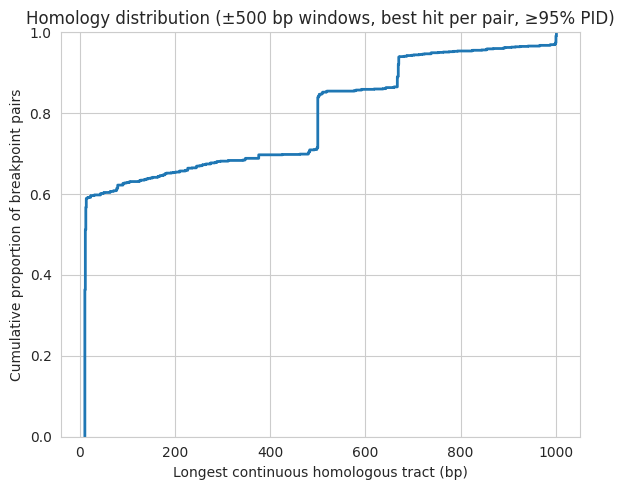

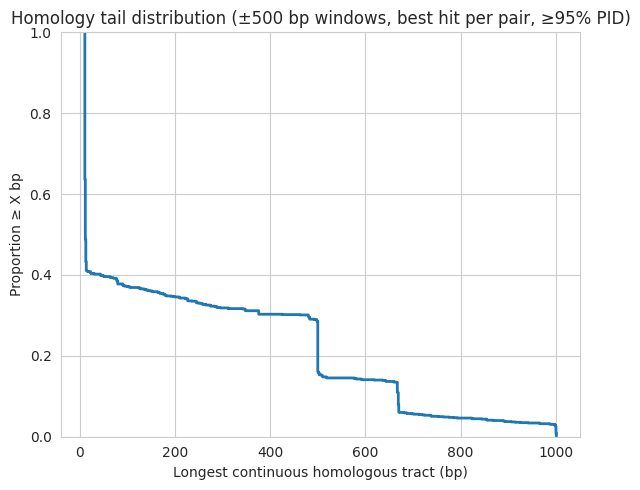


Summary of longest tract length per breakpoint pair:
count    1149.000000
mean      215.450827
std       292.565226
min        11.000000
25%        11.000000
50%        12.000000
75%       500.000000
max      1001.000000
Name: length, dtype: float64

Top 20 longest tracts:
     pair_id        plasmid  length  pident  qstart  qend  sstart  send
356      414  NZ_CP134665.1    1001    99.8       1   999       1  1001
354      411  NZ_CP134665.1    1001    99.8       1   999       1  1001
346      400  NZ_CP134665.1    1001    99.8       1   999       1  1001
572      737  NZ_CP134665.1    1001    99.8       1   999       1  1001
511      626  NZ_CP134665.1    1001    99.8       1   999       1  1001
658      866  NZ_CP134665.1    1001    99.8       1   999       1  1001
568      730  NZ_CP134665.1    1001    99.8       1   999       1  1001
325      371  NZ_CP134665.1    1001    99.8       1   999       1  1001
97       106  NZ_CP134665.1    1001    99.8       1   999       1  1001
965  

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# INPUTS
# ============================================================

TRACTS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/homologous_tracts.tsv"
hw = 500

# ============================================================
# 1. LOAD
# ============================================================

best = pd.read_csv(TRACTS_FILE, sep="\t")

best = best[
    best["length"].notna()
].copy()

best["length"] = pd.to_numeric(best["length"], errors="coerce")
best["pident"] = pd.to_numeric(best["pident"], errors="coerce")
best = best.dropna(subset=["length"]).copy()

print("N breakpoint pairs with retained homologous tract:", len(best))
print("Unique pair_id:", best["pair_id"].nunique())

# sanity check: debería haber una fila por pair_id
dup_pairs = best["pair_id"].duplicated().sum()
print("Duplicated pair_id rows:", dup_pairs)

# ============================================================
# 2. ECDF
# ============================================================

plt.figure(figsize=(6, 5))

sns.ecdfplot(
    data=best,
    x="length",
    linewidth=2
)

plt.xlabel("Longest continuous homologous tract (bp)")
plt.ylabel("Cumulative proportion of breakpoint pairs")
plt.title(f"Homology distribution (±{hw} bp windows, best hit per pair, ≥95% PID)")
plt.tight_layout()
plt.show()

# ============================================================
# 3. TAIL ECDF
# ============================================================

plt.figure(figsize=(6, 5))

sns.ecdfplot(
    data=best,
    x="length",
    complementary=True,
    linewidth=2
)

plt.xlabel("Longest continuous homologous tract (bp)")
plt.ylabel("Proportion ≥ X bp")
plt.title(f"Homology tail distribution (±{hw} bp windows, best hit per pair, ≥95% PID)")
plt.tight_layout()
plt.show()

# ============================================================
# 4. QUICK NUMERIC CHECK
# ============================================================

print("\nSummary of longest tract length per breakpoint pair:")
print(best["length"].describe())

print("\nTop 20 longest tracts:")
print(
    best.sort_values("length", ascending=False)[
        ["pair_id", "plasmid", "length", "pident", "qstart", "qend", "sstart", "send"]
    ].head(20)
)
# ============================================================
# 5. SMALLEST TRACT
# ============================================================

min_len = best["length"].min()
print("Smallest homologous tract detected (bp):", min_len)

# ver la(s) fila(s) correspondiente(s)
smallest = best[best["length"] == min_len]

print("\nEntries with smallest tract:")
print(
    smallest[
        ["pair_id", "plasmid", "length", "pident", "qstart", "qend", "sstart", "send"]
    ]
)

  category  n_pairs  percentage  fraction
0        0      468   28.942486  0.289425
1     1–15      677   41.867656  0.418677
2   16–450      125    7.730365  0.077304
3  451–650      190   11.750155  0.117502
4     >650      157    9.709338  0.097093


/tmp/ipykernel_936126/1136628537.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


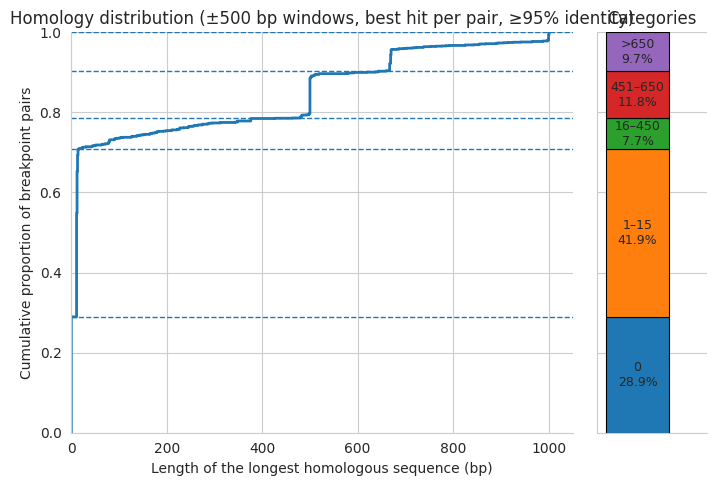

Saved figure to: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/ecdf_plus_vertical_stacked_bar.png


In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ============================================================
# INPUTS
# ============================================================

PAIRWISE_TSV = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/pairwise_hits.tsv"
OUT_PNG = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/ecdf_plus_vertical_stacked_bar.png"

# Tunea aquí los thresholds
THRESHOLDS = [15, 450,650 ]
HW = 500

# ============================================================
# 1. LOAD
# ============================================================

pairwise = pd.read_csv(PAIRWISE_TSV, sep="\t")

pairwise["length"] = pd.to_numeric(pairwise["length"], errors="coerce")
pairwise["pident"] = pd.to_numeric(pairwise["pident"], errors="coerce")
pairwise["bitscore"] = pd.to_numeric(pairwise["bitscore"], errors="coerce")

total_pairs = pairwise["pair_id"].nunique()

# ============================================================
# 2. BEST HIT PER PAIR
# ============================================================

hits = pairwise[pairwise["length"].notna()].copy()

best = (
    hits.sort_values(
        ["pair_id", "length", "pident", "bitscore"],
        ascending=[True, False, False, False]
    )
    .drop_duplicates(subset=["pair_id"], keep="first")
    .copy()
)

best_lengths = dict(zip(best["pair_id"], best["length"]))

rows = []
for pid in sorted(pairwise["pair_id"].unique()):
    if pid in best_lengths:
        rows.append({"pair_id": pid, "best_length": int(best_lengths[pid])})
    else:
        rows.append({"pair_id": pid, "best_length": 0})

df = pd.DataFrame(rows)

# ============================================================
# 3. CATEGORIES
# ============================================================

def make_labels(thresholds):
    labels = ["0"]
    prev = 0
    for t in thresholds:
        labels.append(f"{prev+1}–{t}")
        prev = t
    labels.append(f">{thresholds[-1]}")
    return labels

def categorize_length(x, thresholds):
    if x == 0:
        return "0"
    prev = 0
    for t in thresholds:
        if prev < x <= t:
            return f"{prev+1}–{t}"
        prev = t
    return f">{thresholds[-1]}"

labels = make_labels(THRESHOLDS)
df["category"] = df["best_length"].apply(lambda x: categorize_length(x, THRESHOLDS))

summary = (
    df["category"]
    .value_counts()
    .reindex(labels, fill_value=0)
    .reset_index()
)

summary.columns = ["category", "n_pairs"]
summary["percentage"] = 100 * summary["n_pairs"] / total_pairs
summary["fraction"] = summary["n_pairs"] / total_pairs

print(summary)o

# ============================================================
# 4. FIGURE: ECDF + VERTICAL STACKED BAR
# ============================================================

sns.set_style("whitegrid")

fig = plt.figure(figsize=(8.2, 5.2))
gs = GridSpec(1, 2, width_ratios=[5.5, 1.2], wspace=0.08)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)

# ----------------------------
# LEFT: ECDF
# ----------------------------
sns.ecdfplot(
    data=df,
    x="best_length",
    linewidth=2,
    ax=ax1
)

ax1.set_xlabel("Length of the longest homologous sequence (bp)")
ax1.set_ylabel("Cumulative proportion of breakpoint pairs")
ax1.set_title(f"Homology distribution (±{HW} bp windows, best hit per pair, ≥95% identity)")
ax1.set_xlim(left=0)
ax1.set_ylim(0, 1)

# líneas horizontales en los cortes acumulados
cum = 0
for _, row in summary.iterrows():
    cum += row["fraction"]
    ax1.axhline(cum, linestyle="--", linewidth=1)

# ----------------------------
# RIGHT: vertical stacked bar
# ----------------------------
bottom = 0
for _, row in summary.iterrows():
    h = row["fraction"]
    ax2.bar(
        x=0,
        height=h,
        bottom=bottom,
        width=0.85,
        edgecolor="black",
        linewidth=0.8
    )

    ymid = bottom + h / 2

    if h >= 0.035:
        ax2.text(
            0,
            ymid,
            f"{row['category']}\n{row['percentage']:.1f}%",
            ha="center",
            va="center",
            fontsize=9
        )
    else:
        ax2.text(
            0.52,
            ymid,
            f"{row['category']} ({row['percentage']:.1f}%)",
            ha="left",
            va="center",
            fontsize=8
        )

    bottom += h

ax2.set_xlim(-0.55, 0.95)
ax2.set_xticks([])
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_title("Categories")

# quitar ticks duplicados en el eje y de la barra
plt.setp(ax2.get_yticklabels(), visible=False)

# limpiar spines
for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {OUT_PNG}")

In [68]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

TRACTS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/homologous_tracts.tsv"

best = pd.read_csv(TRACTS_FILE, sep="\t")
best = best[best["length"].notna()].copy()
best["length"] = pd.to_numeric(best["length"], errors="coerce")
best = best.dropna(subset=["length"]).copy()

N = len(best)

slider = widgets.IntSlider(
    value=10,
    min=1,
    max=int(best["length"].max()),
    step=1,
    description="X (bp):",
    continuous_update=True
)

out = widgets.Output()

def update(change=None):
    x = slider.value
    n = (best["length"] < x).sum()
    pct = 100 * n / N
    with out:
        out.clear_output(wait=True)
        print(f"Threshold: < {x} bp")
        print(f"Count: {n} / {N}")
        print(f"Percentage: {pct:.2f}%")

slider.observe(update, names="value")

display(slider, out)
update()

IntSlider(value=10, description='X (bp):', max=1001, min=1)

Output()

    cluster  n_sequences  cluster_rank
0        29          260             1
1        71           12             2
2        60           12             3
3        77           11             4
4        10           10             5
5        61           10             6
6        87            9             7
7        73            7             8
8        55            6             9
9        74            6            10
10       86            5            11
11       69            4            12
12       72            4            13
13       16            4            14
14       22            3            15
15       19            3            16
16        1            3            17
17       47            3            18
18        5            3            19
19       36            2            20


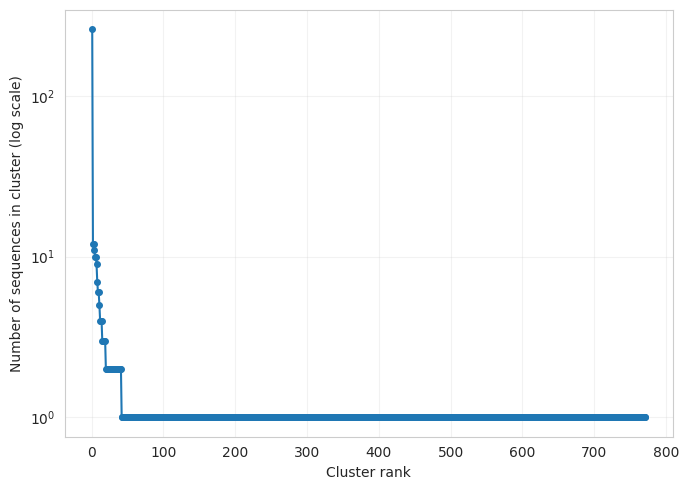

Saved figure to: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/cluster_sizes_plot.png


In [62]:
import pandas as pd
import matplotlib.pyplot as plt

CLUSTERS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/clusters_members.tsv"
OUT_PNG = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/cluster_sizes_plot.png"

# ===============================
# LOAD
# ===============================
cl = pd.read_csv(CLUSTERS_FILE, sep="\t")

# ===============================
# CLUSTER SIZES
# ===============================
cluster_sizes = (
    cl.groupby("cluster")
      .size()
      .reset_index(name="n_sequences")
      .sort_values("n_sequences", ascending=False)
      .reset_index(drop=True)
)

cluster_sizes["cluster_rank"] = range(1, len(cluster_sizes) + 1)

print(cluster_sizes.head(20))

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(7, 5))

plt.plot(
    cluster_sizes["cluster_rank"],
    cluster_sizes["n_sequences"],
    marker="o",
    linewidth=1.5,
    markersize=4
)

plt.yscale("log")
plt.xlabel("Cluster rank")
plt.ylabel("Number of sequences in cluster (log scale)")

plt.grid(True, alpha=0.25)
plt.tight_layout()

# ===============================
# SAVE
# ===============================
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {OUT_PNG}")

In [71]:
import pandas as pd

PAIRWISE_TSV = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/pairwise_hits.tsv"

pairwise = pd.read_csv(PAIRWISE_TSV, sep="\t")

# ============================================================
# 1. TOTAL PAIRS
# ============================================================

total_pairs = pairwise["pair_id"].nunique()

# ============================================================
# 2. BEST HIT PER PAIR (como en tu pipeline)
# ============================================================

hits = pairwise[
    pairwise["length"].notna()
].copy()

hits["length"] = pd.to_numeric(hits["length"], errors="coerce")
hits = hits.dropna(subset=["length"])

best = (
    hits.sort_values(
        ["pair_id", "length", "pident", "bitscore"],
        ascending=[True, False, False, False]
    )
    .drop_duplicates(subset=["pair_id"], keep="first")
    .copy()
)

pairs_with_hits = best["pair_id"].nunique()
pairs_no_hits = total_pairs - pairs_with_hits

# ============================================================
# 3. PRINT GLOBAL NUMBERS
# ============================================================

print("\n=== GLOBAL ===")
print(f"Total pairs: {total_pairs}")
print(f"With homology: {pairs_with_hits} ({pairs_with_hits/total_pairs:.2%})")
print(f"No homology: {pairs_no_hits} ({pairs_no_hits/total_pairs:.2%})")

# ============================================================
# 4. DISTRIBUTION FOR DIFFERENT THRESHOLDS
# ============================================================

thresholds = [5, 10, 15, 20, 25, 30, 50, 100, 200]

print("\n=== LENGTH DISTRIBUTION ===")
for x in thresholds:
    n = (best["length"] <= x).sum()
    print(f"≤ {x} bp: {n} ({n/total_pairs:.2%} of ALL pairs, {n/pairs_with_hits:.2%} of pairs with homology)")


=== GLOBAL ===
Total pairs: 1617
With homology: 1149 (71.06%)
No homology: 468 (28.94%)

=== LENGTH DISTRIBUTION ===
≤ 5 bp: 0 (0.00% of ALL pairs, 0.00% of pairs with homology)
≤ 10 bp: 0 (0.00% of ALL pairs, 0.00% of pairs with homology)
≤ 15 bp: 677 (41.87% of ALL pairs, 58.92% of pairs with homology)
≤ 20 bp: 680 (42.05% of ALL pairs, 59.18% of pairs with homology)
≤ 25 bp: 685 (42.36% of ALL pairs, 59.62% of pairs with homology)
≤ 30 bp: 686 (42.42% of ALL pairs, 59.70% of pairs with homology)
≤ 50 bp: 692 (42.80% of ALL pairs, 60.23% of pairs with homology)
≤ 100 bp: 722 (44.65% of ALL pairs, 62.84% of pairs with homology)
≤ 200 bp: 751 (46.44% of ALL pairs, 65.36% of pairs with homology)


In [72]:
import pandas as pd

PAIRWISE_TSV = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/pairwise_hits.tsv"

pairwise = pd.read_csv(PAIRWISE_TSV, sep="\t")

# ============================================================
# 1. BEST HIT PER PAIR
# ============================================================

hits = pairwise[pairwise["length"].notna()].copy()
hits["length"] = pd.to_numeric(hits["length"], errors="coerce")
hits["pident"] = pd.to_numeric(hits["pident"], errors="coerce")
hits["bitscore"] = pd.to_numeric(hits["bitscore"], errors="coerce")
hits = hits.dropna(subset=["length"])

best = (
    hits.sort_values(
        ["pair_id", "length", "pident", "bitscore"],
        ascending=[True, False, False, False]
    )
    .drop_duplicates(subset=["pair_id"], keep="first")
    .copy()
)

total_pairs = pairwise["pair_id"].nunique()

# ============================================================
# 2. TUNEABLE X
# ============================================================

X = 100  # cambia esto

# ============================================================
# 3. COUNT PAIRS WITH HOMOLOGY > X
# ============================================================

n_gt_x = (best["length"] > X).sum()
pct_all = 100 * n_gt_x / total_pairs
pct_with_homology = 100 * n_gt_x / len(best)

print(f"Threshold: > {X} bp")
print(f"Pairs with homology > {X} bp: {n_gt_x}")
print(f"Percentage of all pairs: {pct_all:.2f}%")
print(f"Percentage of pairs with detectable homology: {pct_with_homology:.2f}%")

Threshold: > 100 bp
Pairs with homology > 100 bp: 427
Percentage of all pairs: 26.41%
Percentage of pairs with detectable homology: 37.16%


   cluster  n_sequences  rank
0       29          260     1
1       71           12     2
2       60           12     3
3       77           11     4
4       10           10     5
5       61           10     6
6       87            9     7
7       73            7     8
8       55            6     9
9       74            6    10

Largest cluster: 29
Size: 260
Fraction of all sequences: 22.628%


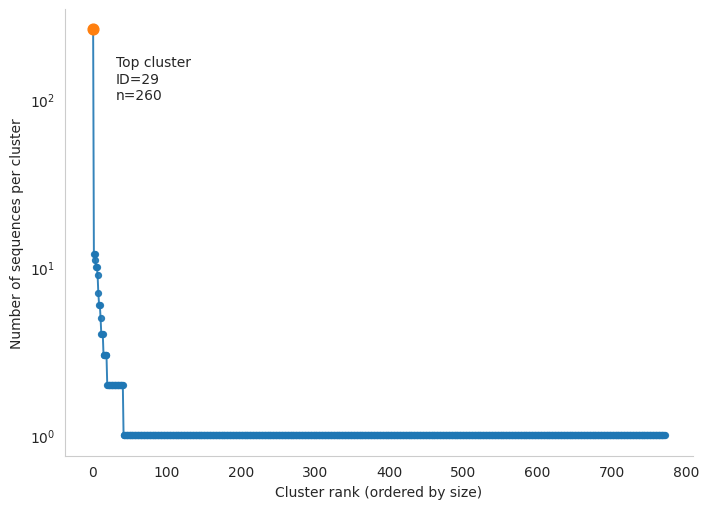

Saved to: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/cluster_rank_abundance.png


In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# INPUT
# ============================================================
CLUSTERS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/clusters_members.tsv"
OUT_PNG = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/cluster_rank_abundance.png"

# ============================================================
# LOAD
# ============================================================
cl = pd.read_csv(CLUSTERS_FILE, sep="\t")

# ============================================================
# CLUSTER SIZE TABLE
# ============================================================
cluster_sizes = (
    cl.groupby("cluster")
      .size()
      .reset_index(name="n_sequences")
      .sort_values("n_sequences", ascending=False)
      .reset_index(drop=True)
)

cluster_sizes["rank"] = range(1, len(cluster_sizes) + 1)

# info del cluster más grande
top_cluster = cluster_sizes.iloc[0]
top_rank = int(top_cluster["rank"])
top_size = int(top_cluster["n_sequences"])
top_cluster_id = top_cluster["cluster"]

print(cluster_sizes.head(10))
print()
print(f"Largest cluster: {top_cluster_id}")
print(f"Size: {top_size}")
print(f"Fraction of all sequences: {top_size / cluster_sizes['n_sequences'].sum():.3%}")

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(7.2, 5.2))

# todos los clusters
ax.plot(
    cluster_sizes["rank"],
    cluster_sizes["n_sequences"],
    linewidth=1.4,
    alpha=0.9
)

ax.scatter(
    cluster_sizes["rank"],
    cluster_sizes["n_sequences"],
    s=18,
    alpha=0.9
)

# resaltar el cluster más grande
ax.scatter(
    [top_rank],
    [top_size],
    s=60,
    zorder=5
)

ax.annotate(
    f"Top cluster\nID={top_cluster_id}\nn={top_size}",
    xy=(top_rank, top_size),
    xytext=(top_rank + max(8, len(cluster_sizes) * 0.04), top_size * 0.7),
    arrowprops=dict(arrowstyle="-", lw=1),
    fontsize=10,
    ha="left",
    va="top"
)

# formato
ax.set_yscale("log")
ax.set_xlabel("Cluster rank (ordered by size)")
ax.set_ylabel("Number of sequences per cluster")

# limpiar estilo
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=400, bbox_inches="tight")
plt.show()

print(f"Saved to: {OUT_PNG}")

Cluster usado: 29
N tracts: 260
Unique pair_id: 260
Unique plasmids: 172
Length range: 44 - 825

Summary:
count    260.000000
mean     535.480769
std      125.421373
min       44.000000
25%      500.000000
50%      500.000000
75%      667.000000
max      825.000000
Name: length, dtype: float64

Top 10 longest:
     tract_id  pair_id        plasmid  length   pident
99        659      868  NZ_ON390812.1     825   99.879
120       682      895  NZ_CP065557.1     672   99.702
102       664      873     CP050282.1     670  100.000
130       693      906  NZ_CP095248.1     670  100.000
101       663      872     CP050278.1     670  100.000
112       674      884  NZ_CP032242.1     670  100.000
117       679      892  NZ_CP064243.1     670  100.000
118       680      893  NZ_CP064260.1     670  100.000
121       683      896  NZ_CP066906.1     670  100.000
127       689      902  NZ_CP078123.1     670  100.000

Top 10 shortest:
     tract_id  pair_id        plasmid  length  pident
158       7

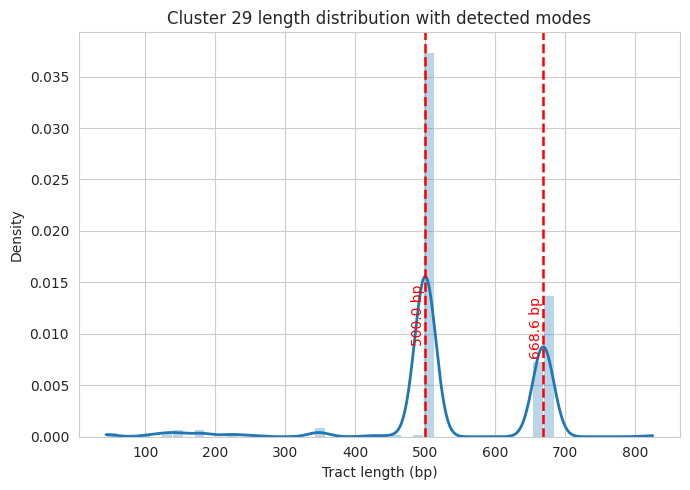


Representatives per mode:
   mode_id  mode_length_bp  tract_id  pair_id        plasmid  length  pident  \
0        0           500.0       122      140     AP022086.1     500   100.0   
1        1           668.6        90       96  NZ_CP017086.1     669   100.0   

   dist_to_mode  
0          0.02  
1          0.43  

Top candidates per mode:

--- Mode 0 (~500.0 bp) ---
   tract_id  pair_id      plasmid  length  pident  dist_to_mode
0       122      140   AP022086.1     500   100.0      0.022756
1       124      142   CP027485.1     500   100.0      0.022756
2       129      147   CP052139.1     500   100.0      0.022756
3       134      153   CP082572.1     500   100.0      0.022756
4       141      160   CP101349.1     500   100.0      0.022756
5       142      161   CP110735.1     500   100.0      0.022756
6       148      167   JX127248.1     500   100.0      0.022756
7       150      169   LC613142.1     500   100.0      0.022756
8       151      170   LC744469.1     500   100.

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

# ============================================================
# INPUTS
# ============================================================

TRACTS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/homologous_tracts.tsv"
CLUSTERS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/clusters_members.tsv"

CLUSTER_ID = 29

# parámetros de detección de picos
BW_METHOD = 0.12
PROMINENCE_FRAC = 0.08
MIN_PEAK_DISTANCE_GRID = 150
TOP_N_MODES = None   # por ejemplo 2 si quieres forzar solo las 2 modas principales

# ============================================================
# LOAD
# ============================================================

tracts = pd.read_csv(TRACTS_FILE, sep="\t")
cl = pd.read_csv(CLUSTERS_FILE, sep="\t")

# ============================================================
# REBUILD CLUSTER-SPECIFIC TABLE DESDE CERO
# ============================================================

cl_sel = cl[cl["cluster"] == CLUSTER_ID].copy()

df_cluster = cl_sel.merge(
    tracts[["tract_id", "pair_id", "plasmid", "length", "pident"]],
    on=["tract_id", "pair_id", "plasmid"],
    how="left"
)

# quitar entradas sin longitud
df_cluster = df_cluster.dropna(subset=["length"]).copy()
df_cluster["length"] = pd.to_numeric(df_cluster["length"], errors="coerce")
df_cluster["pident"] = pd.to_numeric(df_cluster["pident"], errors="coerce")
df_cluster = df_cluster.dropna(subset=["length"]).copy()

print("Cluster usado:", CLUSTER_ID)
print("N tracts:", len(df_cluster))
print("Unique pair_id:", df_cluster["pair_id"].nunique())
print("Unique plasmids:", df_cluster["plasmid"].nunique())
print("Length range:", df_cluster["length"].min(), "-", df_cluster["length"].max())

print("\nSummary:")
print(df_cluster["length"].describe())

print("\nTop 10 longest:")
print(
    df_cluster.sort_values("length", ascending=False)[
        ["tract_id", "pair_id", "plasmid", "length", "pident"]
    ].head(10)
)

print("\nTop 10 shortest:")
print(
    df_cluster.sort_values("length", ascending=True)[
        ["tract_id", "pair_id", "plasmid", "length", "pident"]
    ].head(10)
)

# ============================================================
# KDE EN ESCALA REAL
# ============================================================

lengths = df_cluster["length"].values

if len(lengths) < 3:
    raise ValueError("Muy pocos datos para estimar modas en este cluster.")

grid = np.linspace(lengths.min(), lengths.max(), 4000)
kde = gaussian_kde(lengths, bw_method=BW_METHOD)
density = kde(grid)

# ============================================================
# DETECCIÓN DE PICOS
# ============================================================

peaks, props = find_peaks(
    density,
    prominence=density.max() * PROMINENCE_FRAC,
    distance=MIN_PEAK_DISTANCE_GRID
)

if len(peaks) == 0:
    raise ValueError(
        "No se detectaron picos. Prueba a bajar PROMINENCE_FRAC o ajustar BW_METHOD."
    )

mode_lengths = grid[peaks]
peak_heights = density[peaks]
prominences = props["prominences"]

# ordenar por altura del pico
order = np.argsort(peak_heights)[::-1]
mode_lengths = mode_lengths[order]
peak_heights = peak_heights[order]
prominences = prominences[order]

# opcional: quedarse solo con top N
if TOP_N_MODES is not None:
    mode_lengths = mode_lengths[:TOP_N_MODES]
    peak_heights = peak_heights[:TOP_N_MODES]
    prominences = prominences[:TOP_N_MODES]

print("\nDetected modes (bp):", np.round(mode_lengths, 1))

modes_table = pd.DataFrame({
    "mode_id": range(len(mode_lengths)),
    "mode_length_bp": np.round(mode_lengths, 1),
    "peak_height": peak_heights,
    "prominence": prominences
})

print("\nModes table:")
print(modes_table)

# ============================================================
# PLOT
# ============================================================

sns.set_style("whitegrid")

plt.figure(figsize=(7, 5))
sns.histplot(lengths, bins=50, stat="density", alpha=0.3)
plt.plot(grid, density, linewidth=2)

for i, m in enumerate(mode_lengths):
    plt.axvline(m, color="red", linestyle="--", linewidth=1.8)
    plt.text(
        m,
        density.max() * max(0.2, (0.95 - i * 0.08)),
        f"{m:.1f} bp",
        rotation=90,
        color="red",
        ha="right",
        va="top"
    )

plt.xlabel("Tract length (bp)")
plt.ylabel("Density")
plt.title(f"Cluster {CLUSTER_ID} length distribution with detected modes")
plt.tight_layout()
plt.show()

# ============================================================
# REPRESENTATIVE TRACT PER MODE
# ============================================================

representatives = []
work = df_cluster.copy()

for i, mode in enumerate(mode_lengths):
    tmp = work.copy()
    tmp["dist_to_mode"] = np.abs(tmp["length"] - mode)

    best = tmp.sort_values(
        ["dist_to_mode", "pident", "length"],
        ascending=[True, False, False]
    ).iloc[0]

    representatives.append({
        "mode_id": i,
        "mode_length_bp": round(mode, 1),
        "tract_id": best["tract_id"],
        "pair_id": best["pair_id"],
        "plasmid": best["plasmid"],
        "length": best["length"],
        "pident": best["pident"],
        "dist_to_mode": round(best["dist_to_mode"], 2)
    })

rep_df = pd.DataFrame(representatives)

print("\nRepresentatives per mode:")
print(rep_df)

# ============================================================
# OPTIONAL: TOP CANDIDATES PER MODE
# ============================================================

all_assignments = []

for i, mode in enumerate(mode_lengths):
    tmp = work.copy()
    tmp["mode_id"] = i
    tmp["mode_length_bp"] = round(mode, 1)
    tmp["dist_to_mode"] = np.abs(tmp["length"] - mode)
    tmp = tmp.sort_values(
        ["dist_to_mode", "pident", "length"],
        ascending=[True, False, False]
    )

    all_assignments.append(tmp)

assignments_df = pd.concat(all_assignments, ignore_index=True)

print("\nTop candidates per mode:")
for i in range(len(mode_lengths)):
    print(f"\n--- Mode {i} (~{mode_lengths[i]:.1f} bp) ---")
    print(
        assignments_df[assignments_df["mode_id"] == i][
            ["tract_id", "pair_id", "plasmid", "length", "pident", "dist_to_mode"]
        ].head(10)
    )

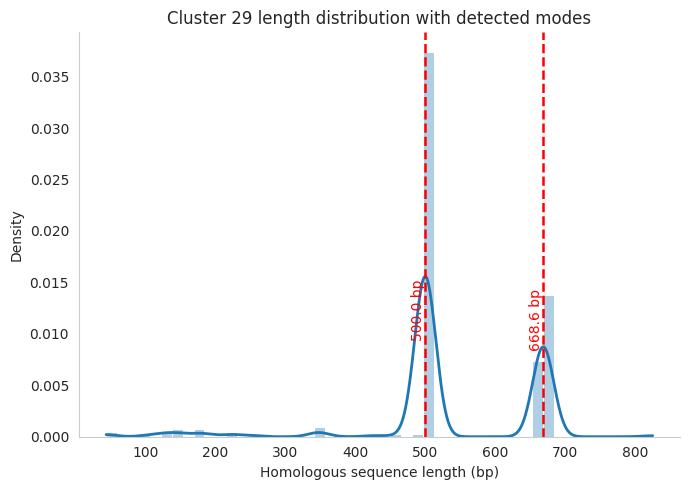

Saved figure to: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/cluster_29_length_modes.svg


In [67]:
# ============================================================
# PLOT
# ============================================================

OUTFIG = f"/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/cluster_{CLUSTER_ID}_length_modes.svg"

plt.figure(figsize=(7, 5))

# histograma relleno con transparencia
sns.histplot(
    lengths,
    bins=50,
    stat="density",
    alpha=0.35,
    edgecolor=None
)

# curva KDE
plt.plot(grid, density, linewidth=2)

# altura máxima para colocar etiquetas
ymax = density.max()

for i, m in enumerate(mode_lengths):
    plt.axvline(m, color="red", linestyle="--", linewidth=1.8)
    plt.text(
        m,
        ymax * max(0.72, 0.98 - i * 0.06),
        f"{m:.1f} bp",
        rotation=90,
        color="red",
        ha="right",
        va="top"
    )

plt.xlabel("Homologous sequence length (bp)")
plt.ylabel("Density")
plt.title(f"Cluster {CLUSTER_ID} length distribution with detected modes")

# sin rejilla de fondo
ax = plt.gca()
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTFIG, bbox_inches="tight", format="svg")
plt.show()

print(f"Saved figure to: {OUTFIG}")

In [57]:
import pandas as pd

TRACTS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/homologous_tracts.tsv"

df = pd.read_csv(TRACTS_FILE, sep="\t")

targets = [
    ("NZ_CP017086.1", 96),
    ("AP022086.1", 140)
]

for plasmid, pair_id in targets:
    sub = df[
        (df["plasmid"] == plasmid) &
        (df["pair_id"] == pair_id)
    ]

    print(f"\n=== {plasmid} | pair {pair_id} ===")

    if sub.empty:
        print("❌ No encontrado")
        continue

    r = sub.iloc[0]

    print("\nBreakpoints (genomic coordinates):")
    print(f" - Breakpoint 1 (start): {int(r['bp_start_pos'])}")
    print(f" - Breakpoint 2 (end)  : {int(r['bp_end_pos'])}")

    print("\nSanity:")
    print("Length:", r["length"])
    print("PID:", r["pident"])


=== NZ_CP017086.1 | pair 96 ===

Breakpoints (genomic coordinates):
 - Breakpoint 1 (start): 31672
 - Breakpoint 2 (end)  : 41434

Sanity:
Length: 669
PID: 100.0

=== AP022086.1 | pair 140 ===

Breakpoints (genomic coordinates):
 - Breakpoint 1 (start): 40114
 - Breakpoint 2 (end)  : 44499

Sanity:
Length: 500
PID: 100.0


In [58]:
import pandas as pd
from Bio import SeqIO

# ============================================================
# INPUTS
# ============================================================

TRACTS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/homologous_tracts.tsv"
FASTA_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/raw_fastas"

targets = [
    ("NZ_CP017086.1", 96),
    ("AP022086.1", 140)
]

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(TRACTS_FILE, sep="\t")

def get_fasta(plasmid):
    for f in os.listdir(FASTA_DIR):
        if f.startswith(plasmid) and f.endswith((".fna", ".fa", ".fasta")):
            return os.path.join(FASTA_DIR, f)
    raise FileNotFoundError(f"No FASTA for {plasmid}")

def extract_seq(seq, start, end):
    return seq[start-1:end]

# ============================================================
# EXTRACTION
# ============================================================

for plasmid, pair_id in targets:

    sub = df[
        (df["plasmid"] == plasmid) &
        (df["pair_id"] == pair_id)
    ]

    print(f"\n=== {plasmid} | pair {pair_id} ===")

    if sub.empty:
        print("❌ Not found")
        continue

    r = sub.iloc[0]

    fasta_path = get_fasta(plasmid)
    record = next(SeqIO.parse(fasta_path, "fasta"))
    genome_seq = str(record.seq)

    # reconstruir coordenadas reales del tract
    def real_coords(bp_pos, start, end, hw=500):
        offset_start = start - (hw + 1)
        offset_end = end - (hw + 1)
        return int(bp_pos + offset_start), int(bp_pos + offset_end)

    q_real_start, q_real_end = real_coords(
        r["bp_start_pos"], r["qstart"], r["qend"]
    )

    s_real_start, s_real_end = real_coords(
        r["bp_end_pos"], r["sstart"], r["send"]
    )

    seq1 = extract_seq(genome_seq, q_real_start, q_real_end)
    seq2 = extract_seq(genome_seq, s_real_start, s_real_end)

    print("\n--- Coordinates ---")
    print("Region 1:", q_real_start, "-", q_real_end)
    print("Region 2:", s_real_start, "-", s_real_end)

    print("\n--- Sequence 1 ---")
    print(seq1)

    print("\n--- Sequence 2 ---")
    print(seq2)

    print("\n--- Identity check ---")
    print("Same sequence:", seq1 == seq2)


=== NZ_CP017086.1 | pair 96 ===

--- Coordinates ---
Region 1: 31503 - 32171
Region 2: 41266 - 41934

--- Sequence 1 ---
TTGGCACTGTTGCAAAGTTAGCGATGAGGCAGCCTTTTGTCTTATTCAAAGGCCTTACATTTCAAAAACTCTGCTTACCAGGCGCATTTCGCCCAGGGGATCACCATAATAAAATGCTGAGGCCTGGCCTTTGCGTAGTGCACGCATCACCTCAATACCTTTGATGGTGGCGTAAGCCGTCTTCATGGATTTAAATCCCAGCGTGGCGCCGATTATCCGTTTCAGTTTGCCATGATCGCATTCAATCACGTTGTTCCGGTACTTAATCTGTCGGTGTTCAACGTCAGACGGGCACCGGCCTTCGCGTTTGAGCAGAGCAAGCGCGCGACCATAGGCGGGCGCTTTATCCGTGTTGATGAATCGCGGGATCTGCCACTTCTTCACGTTGTTGAGGATTTTACCCAGAAACCGGTATGCAGCTTTGCTGTTACGACGGGAGGAGAGATAAAAATCGACAGTGCGGCCCCGGCTGTCGACGGCCCGGTACAGATACGCCCAGCGGCCATTGACCTTCACGTAGGTTTCATCCATGTGCCACGGGCAAAGATCGGAAGGGTTACGCCAGTACCAGCGCAGCCGTTTTTCCATTTCAGGCGCATAACGCTGAACCCAGCGGTAAATCGTGGAGTGATCGACATTCACTCCGCGTTCAGCCAGCATCTCCTGCAG

--- Sequence 2 ---
TTGGCACTGTTGCAAAGTTAGCGATGAGGCAGCCTTTTGTCTTATTCAAAGGCCTTACATTTCAAAAACTCTGCTTACCAGGCGCATTTCGCCCAGGGGATCACCATAATAAAATGCTGAGGCCTGGCCTTTGCGTAGTGCACGCATCACCTCAATACCTTTGATGGTGGCGTAAGCCGTCTTCATGG

In [59]:
import os
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq

# ============================================================
# INPUTS
# ============================================================

TRACTS_FILE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/homologous_tracts.tsv"
FASTA_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/raw_fastas"

# Casos a inspeccionar
targets = [
    ("CP027485.1", 142),   # otro caso del pico ~500
    ("NZ_CP023942.1", 879) # otro caso del pico ~669
]

# Si quieres guardar FASTAs
WRITE_FASTA = True
OUTDIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/manual_examples_breakpoints"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def get_fasta(plasmid, fasta_dir):
    for fname in os.listdir(fasta_dir):
        if fname.startswith(plasmid) and fname.endswith((".fna", ".fa", ".fasta")):
            return os.path.join(fasta_dir, fname)
    raise FileNotFoundError(f"No FASTA found for {plasmid}")

def extract_seq(seq, start, end):
    start = int(start)
    end = int(end)
    return seq[start-1:end]

def real_coords_from_window(bp_pos, aln_start, aln_end, hw=500):
    """
    Convierte coordenadas dentro de la ventana (1..1001) a coordenadas reales del plásmido.
    La posición del breakpoint dentro de la ventana es hw + 1.
    """
    bp_pos = int(bp_pos)
    aln_start = int(aln_start)
    aln_end = int(aln_end)

    offset_start = aln_start - (hw + 1)
    offset_end   = aln_end   - (hw + 1)

    real_start = bp_pos + offset_start
    real_end   = bp_pos + offset_end
    return int(real_start), int(real_end)

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(TRACTS_FILE, sep="\t")

# ============================================================
# EXTRACT EVERYTHING
# ============================================================

summary_rows = []

for plasmid, pair_id in targets:
    sub = df[
        (df["plasmid"] == plasmid) &
        (df["pair_id"] == pair_id)
    ].copy()

    print(f"\n{'='*80}")
    print(f"{plasmid} | pair {pair_id}")
    print(f"{'='*80}")

    if sub.empty:
        print("❌ No encontrado")
        continue

    r = sub.iloc[0]

    fasta_path = get_fasta(plasmid, FASTA_DIR)
    record = next(SeqIO.parse(fasta_path, "fasta"))
    genome_seq = str(record.seq)

    # breakpoints exactos
    bp1 = int(r["bp_start_pos"])
    bp2 = int(r["bp_end_pos"])

    # coordenadas reales del tract homólogo a cada lado
    reg1_start, reg1_end = real_coords_from_window(bp1, r["qstart"], r["qend"], hw=500)
    reg2_start, reg2_end = real_coords_from_window(bp2, r["sstart"], r["send"], hw=500)

    seq1 = extract_seq(genome_seq, reg1_start, reg1_end)
    seq2 = extract_seq(genome_seq, reg2_start, reg2_end)
    seq2_rc = str(Seq(seq2).reverse_complement())

    same_orientation = (seq1 == seq2)
    reverse_complement = (seq1 == seq2_rc)

    print("\n--- Breakpoints exactos ---")
    print(f"Breakpoint 1: {bp1}")
    print(f"Breakpoint 2: {bp2}")

    print("\n--- Coordenadas reales de las dos copias homólogas ---")
    print(f"Homology copy 1: {reg1_start}-{reg1_end}")
    print(f"Homology copy 2: {reg2_start}-{reg2_end}")

    print("\n--- Resumen del tracto ---")
    print(f"Length : {int(r['length'])}")
    print(f"PID    : {float(r['pident'])}")
    print(f"Same orientation     : {same_orientation}")
    print(f"Reverse complement   : {reverse_complement}")

    print("\n--- Secuencia homóloga copy 1 ---")
    print(seq1)

    print("\n--- Secuencia homóloga copy 2 ---")
    print(seq2)

    if reverse_complement:
        print("\n--- Copy 2 reverse-complemented (para comparar con copy 1) ---")
        print(seq2_rc)

    summary_rows.append({
        "plasmid": plasmid,
        "pair_id": int(pair_id),
        "breakpoint_1": bp1,
        "breakpoint_2": bp2,
        "homology_1_start": reg1_start,
        "homology_1_end": reg1_end,
        "homology_2_start": reg2_start,
        "homology_2_end": reg2_end,
        "length": int(r["length"]),
        "pident": float(r["pident"]),
        "same_orientation": same_orientation,
        "reverse_complement": reverse_complement
    })

    if WRITE_FASTA:
        fasta_out = os.path.join(OUTDIR, f"{plasmid}_pair{pair_id}_homology.fa")
        with open(fasta_out, "w") as out:
            out.write(
                f">{plasmid}|pair={pair_id}|copy=1|bp={bp1}|coords={reg1_start}-{reg1_end}\n{seq1}\n"
            )
            out.write(
                f">{plasmid}|pair={pair_id}|copy=2|bp={bp2}|coords={reg2_start}-{reg2_end}\n{seq2}\n"
            )
            if reverse_complement:
                out.write(
                    f">{plasmid}|pair={pair_id}|copy=2_rc|bp={bp2}|coords={reg2_start}-{reg2_end}\n{seq2_rc}\n"
                )
        print(f"\nFASTA escrito en: {fasta_out}")

# ============================================================
# SUMMARY TABLE
# ============================================================

summary_df = pd.DataFrame(summary_rows)

print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print(summary_df)

if WRITE_FASTA and not summary_df.empty:
    summary_tsv = os.path.join(OUTDIR, "selected_examples_summary.tsv")
    summary_df.to_csv(summary_tsv, sep="\t", index=False)
    print(f"\nSummary TSV escrito en: {summary_tsv}")


CP027485.1 | pair 142

--- Breakpoints exactos ---
Breakpoint 1: 67632
Breakpoint 2: 72017

--- Coordenadas reales de las dos copias homólogas ---
Homology copy 1: 67132-67631
Homology copy 2: 72018-72517

--- Resumen del tracto ---
Length : 500
PID    : 100.0
Same orientation     : False
Reverse complement   : True

--- Secuencia homóloga copy 1 ---
CCGCTGGGCGTATCTGTACCGGGCCGTCGACAGCCGGGGCCGCACTGTCGATTTTTATCTCTCCTCCCGTCGTAACAGCAAAGCTGCATACCGGTTTCTGGGTAAAATCCTCAACAACGTGAAGAAGTGGCAGATCCCGCGATTCATCAACACGGATAAAGCGCCCGCCTATGGTCGCGCGCTTGCTCTGCTCAAACGCGAAGGCCGGTGCCCGTCTGACGTTGAACACCGACAGATTAAGTACCGGAACAACGTGATTGAATGCGATCATGGCAAACTGAAACGGATAATCGGCGCCACGCTGGGATTTAAATCCATGAAGACGGCTTACGCCACCATCAAAGGTATTGAGGTGATGCGTGCACTACGCAAAGGCCAGGCCTCAGCATTTTATTATGGTGATCCCCTGGGCGAAATGCGCCTGGTAAGCAGAGTTTTTGAAATGTAAGGCCTTTGAATAAGACAAAAGGCTGCCTCATCGCTAACTTTGCAACAGTGCC

--- Secuencia homóloga copy 2 ---
GGCACTGTTGCAAAGTTAGCGATGAGGCAGCCTTTTGTCTTATTCAAAGGCCTTACATTTCAAAAACTCTGCTTACCAGGCGCATTTCGCCCAGGGGATCACCATAATAA

# add control curva y stackbar #


In [80]:
#!/usr/bin/env python3

import os
import subprocess
import random
from multiprocessing import Pool, cpu_count

import pandas as pd

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3"
PLASMID_FASTA_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/raw_fastas"

SAMTOOLS = "/home/nacho/mambaforge/envs/samtools/bin/samtools"
BLASTN = "/home/nacho/mambaforge/envs/blast/bin/blastn"

# OJO:
# WINDOW_HW=500 => ventanas de 1000 bp totales (±500), igual que el análisis real
WINDOW_HW = 500
MIN_PID = 95.0
N_CORES = max(1, cpu_count() - 2)
RANDOM_SEED = 12345
MAX_TRIES = 500

REAL_DIR = os.path.join(BASE_DIR, f"TRACEABLE_hardcut_95pid_{WINDOW_HW}_onebest_per_pair")
MASTER_TSV = os.path.join(REAL_DIR, "breakpoints_master.tsv")
REAL_PAIRWISE_TSV = os.path.join(REAL_DIR, "pairwise_hits.tsv")

CONTROL_DIR = os.path.join(REAL_DIR, "random_control_two_random_points")
RANDOM_WINDOWS_DIR = os.path.join(CONTROL_DIR, "windows")
RANDOM_BLAST_DIR = os.path.join(CONTROL_DIR, "pairwise_blast")

RANDOM_MASTER_TSV = os.path.join(CONTROL_DIR, "random_windows_master.tsv")
RANDOM_PAIRWISE_TSV = os.path.join(CONTROL_DIR, "random_pairwise_hits.tsv")
RANDOM_BEST_TSV = os.path.join(CONTROL_DIR, "random_best_lengths.tsv")
REAL_BEST_TSV = os.path.join(CONTROL_DIR, "real_best_lengths.tsv")
MERGED_TSV = os.path.join(CONTROL_DIR, "real_vs_random_merged.tsv")

os.makedirs(CONTROL_DIR, exist_ok=True)
os.makedirs(RANDOM_WINDOWS_DIR, exist_ok=True)
os.makedirs(RANDOM_BLAST_DIR, exist_ok=True)

rng = random.Random(RANDOM_SEED)

# ============================================================
# HELPERS
# ============================================================

def get_fasta_path(chrom):
    for fname in os.listdir(PLASMID_FASTA_DIR):
        if fname.endswith((".fna", ".fa", ".fasta")) and fname.startswith(chrom):
            return os.path.join(PLASMID_FASTA_DIR, fname)
    return None

def normalize_circular_pos(pos, L):
    return ((int(pos) - 1) % int(L)) + 1

def circular_window(center, L, hw):
    """
    Devuelve una o dos regiones 1-based cerradas válidas.
    """
    L = int(L)
    hw = int(hw)
    center = normalize_circular_pos(center, L)

    start = center - hw
    end = center + hw

    if start >= 1 and end <= L:
        return [(start, end)]

    parts = []

    if start < 1:
        left_start = L + start + 1
        left_end = L
        right_start = 1
        right_end = end

        if 1 <= left_start <= left_end <= L:
            parts.append((left_start, left_end))
        if 1 <= right_start <= right_end <= L:
            parts.append((right_start, right_end))
        return parts if parts else None

    if end > L:
        left_start = start
        left_end = L
        right_start = 1
        right_end = end - L

        if 1 <= left_start <= left_end <= L:
            parts.append((left_start, left_end))
        if 1 <= right_start <= right_end <= L:
            parts.append((right_start, right_end))
        return parts if parts else None

    return None

def fetch_sequence(fasta, chrom, parts):
    seq = []
    for s, e in parts:
        s = int(s)
        e = int(e)

        if not (1 <= s <= e):
            raise ValueError(f"Invalid interval before faidx: {chrom}:{s}-{e}")

        region = f"{chrom}:{s}-{e}"
        out = subprocess.check_output([SAMTOOLS, "faidx", fasta, region]).decode()
        seq.append("".join(out.split("\n")[1:]))

    return "".join(seq)

def circular_dist(a, b, L):
    d = abs(int(a) - int(b))
    return min(d, int(L) - d)

def run_blast_job(job):
    pair_id, plasmid, fa_start, fa_end = job
    out_file = os.path.join(RANDOM_BLAST_DIR, f"pair_{pair_id:05d}.blast.tsv")

    cmd = [
        BLASTN,
        "-query", fa_start,
        "-subject", fa_end,
        "-task", "blastn",
        "-dust", "no",
        "-soft_masking", "false",
        "-perc_identity", str(MIN_PID),
        "-outfmt", "6 qseqid sseqid qstart qend sstart send length pident mismatch gapopen evalue bitscore",
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        return [{
            "pair_id": pair_id,
            "plasmid": plasmid,
            "status": "error",
            "qseqid": None,
            "sseqid": None,
            "qstart": None,
            "qend": None,
            "sstart": None,
            "send": None,
            "length": None,
            "pident": None,
            "mismatch": None,
            "gapopen": None,
            "evalue": None,
            "bitscore": None,
            "blast_file": out_file,
            "stderr": result.stderr.strip(),
        }]

    with open(out_file, "w") as f:
        f.write(result.stdout)

    rows = []
    if result.stdout.strip():
        for line in result.stdout.strip().split("\n"):
            toks = line.split("\t")
            rows.append({
                "pair_id": pair_id,
                "plasmid": plasmid,
                "status": "ok",
                "qseqid": toks[0],
                "sseqid": toks[1],
                "qstart": int(toks[2]),
                "qend": int(toks[3]),
                "sstart": int(toks[4]),
                "send": int(toks[5]),
                "length": int(toks[6]),
                "pident": float(toks[7]),
                "mismatch": int(toks[8]),
                "gapopen": int(toks[9]),
                "evalue": toks[10],
                "bitscore": float(toks[11]),
                "blast_file": out_file,
                "stderr": "",
            })
    else:
        rows.append({
            "pair_id": pair_id,
            "plasmid": plasmid,
            "status": "ok",
            "qseqid": None,
            "sseqid": None,
            "qstart": None,
            "qend": None,
            "sstart": None,
            "send": None,
            "length": None,
            "pident": None,
            "mismatch": None,
            "gapopen": None,
            "evalue": None,
            "bitscore": None,
            "blast_file": out_file,
            "stderr": "",
        })
    return rows

def summarize_best_lengths(pairwise_df, all_pair_ids):
    pairwise_df = pairwise_df.copy()
    pairwise_df["length"] = pd.to_numeric(pairwise_df["length"], errors="coerce")
    pairwise_df["pident"] = pd.to_numeric(pairwise_df["pident"], errors="coerce")
    pairwise_df["bitscore"] = pd.to_numeric(pairwise_df["bitscore"], errors="coerce")

    hits = pairwise_df[pairwise_df["length"].notna()].copy()

    best = (
        hits.sort_values(
            ["pair_id", "length", "pident", "bitscore"],
            ascending=[True, False, False, False]
        )
        .drop_duplicates(subset=["pair_id"], keep="first")
        .copy()
    )

    best_lengths = dict(zip(best["pair_id"], best["length"]))

    rows = []
    for pid in sorted(all_pair_ids):
        rows.append({
            "pair_id": pid,
            "best_length": int(best_lengths[pid]) if pid in best_lengths else 0
        })

    return pd.DataFrame(rows)

# ============================================================
# 1. LOAD REAL PAIR UNIVERSE
# ============================================================

print("[1/5] Loading real breakpoint pairs...")

master = pd.read_csv(MASTER_TSV, sep="\t")

m_start = (
    master[master["bp_kind"] == "start"]
    [["pair_id", "plasmid", "breakpoint_pos", "plasmid_len"]]
    .rename(columns={"breakpoint_pos": "bp_start_pos"})
)

m_end = (
    master[master["bp_kind"] == "end"]
    [["pair_id", "plasmid", "breakpoint_pos", "plasmid_len"]]
    .rename(columns={"breakpoint_pos": "bp_end_pos"})
)

pairs = m_start.merge(
    m_end,
    on=["pair_id", "plasmid", "plasmid_len"],
    how="inner"
).copy()

pairs["fasta_plasmid"] = pairs["plasmid"].apply(get_fasta_path)

if pairs["fasta_plasmid"].isna().any():
    missing = pairs.loc[pairs["fasta_plasmid"].isna(), "plasmid"].unique().tolist()
    raise FileNotFoundError(f"No FASTA found for plasmids: {missing[:10]}")

all_pair_ids = sorted(pairs["pair_id"].unique())
print(f"Real pairs loaded: {len(all_pair_ids)}")

# ============================================================
# 2. GENERATE RANDOM CONTROL WINDOWS
# ============================================================

print("[2/5] Generating random control windows...")

random_rows = []

for _, r in pairs.iterrows():
    pair_id = int(r["pair_id"])
    plasmid = r["plasmid"]
    L = int(r["plasmid_len"])
    bp_start_real = int(r["bp_start_pos"])
    bp_end_real = int(r["bp_end_pos"])
    fasta = r["fasta_plasmid"]

    chosen = None
    for _ in range(MAX_TRIES):
        rand_start = rng.randint(1, L)
        rand_end = rng.randint(1, L)

        # opcional pero recomendable: no caer dentro de las ventanas reales
        cond = (
            circular_dist(rand_start, bp_start_real, L) > WINDOW_HW and
            circular_dist(rand_start, bp_end_real, L) > WINDOW_HW and
            circular_dist(rand_end, bp_start_real, L) > WINDOW_HW and
            circular_dist(rand_end, bp_end_real, L) > WINDOW_HW
        )

        if cond:
            chosen = (rand_start, rand_end)
            break

    if chosen is None:
        print(f"[WARN] no random positions found for pair_id={pair_id}")
        continue

    rand_start, rand_end = chosen

    for kind, pos in [("start", rand_start), ("end", rand_end)]:
        parts = circular_window(pos, L, WINDOW_HW)
        if not parts:
            print(f"[WARN] no window parts for pair_id={pair_id}, kind={kind}, pos={pos}, L={L}")
            continue

        try:
            seq = fetch_sequence(fasta, plasmid, parts)
        except Exception as ex:
            print(f"[WARN] failed extracting random window for pair_id={pair_id}, kind={kind}, pos={pos}, L={L}: {ex}")
            continue

        header = f"pair={pair_id}|plasmid={plasmid}|kind={kind}|pos={pos}|hw={WINDOW_HW}"
        fa_path = os.path.join(RANDOM_WINDOWS_DIR, f"pair_{pair_id:05d}_{kind}.fa")

        with open(fa_path, "w") as out:
            out.write(f">{header}\n{seq}\n")

        random_rows.append({
            "pair_id": pair_id,
            "plasmid": plasmid,
            "bp_kind": kind,
            "random_center": pos,
            "plasmid_len": L,
            "fasta_header": header,
            "fasta_path": fa_path,
        })

random_master = pd.DataFrame(random_rows)
random_master.to_csv(RANDOM_MASTER_TSV, sep="\t", index=False)

print(f"Random windows generated: {len(random_master)}")
print(f"Wrote: {RANDOM_MASTER_TSV}")

# ============================================================
# 3. BLAST RANDOM START VS RANDOM END
# ============================================================

print("[3/5] Running BLAST on random controls...")

rm_start = (
    random_master[random_master["bp_kind"] == "start"]
    [["pair_id", "plasmid", "fasta_path"]]
    .rename(columns={"fasta_path": "fa_start"})
)

rm_end = (
    random_master[random_master["bp_kind"] == "end"]
    [["pair_id", "plasmid", "fasta_path"]]
    .rename(columns={"fasta_path": "fa_end"})
)

random_pairs = rm_start.merge(
    rm_end,
    on=["pair_id", "plasmid"],
    how="inner"
)

jobs = [
    (int(r["pair_id"]), r["plasmid"], r["fa_start"], r["fa_end"])
    for _, r in random_pairs.iterrows()
]

all_rows = []
with Pool(N_CORES) as pool:
    for res in pool.map(run_blast_job, jobs):
        all_rows.extend(res)

random_pairwise = pd.DataFrame(all_rows)
random_pairwise.to_csv(RANDOM_PAIRWISE_TSV, sep="\t", index=False)

print(random_pairwise["status"].value_counts(dropna=False))
print(f"Wrote: {RANDOM_PAIRWISE_TSV}")

# ============================================================
# 4. SUMMARIZE BEST LENGTHS
# ============================================================

print("[4/5] Summarizing best hit lengths...")

real_pairwise = pd.read_csv(REAL_PAIRWISE_TSV, sep="\t")
df_real = summarize_best_lengths(real_pairwise, all_pair_ids)
df_random = summarize_best_lengths(random_pairwise, all_pair_ids)

df_real = df_real.rename(columns={"best_length": "best_length_real"})
df_random = df_random.rename(columns={"best_length": "best_length_random"})

df_real.to_csv(REAL_BEST_TSV, sep="\t", index=False)
df_random.to_csv(RANDOM_BEST_TSV, sep="\t", index=False)

print(f"Wrote: {REAL_BEST_TSV}")
print(f"Wrote: {RANDOM_BEST_TSV}")

# ============================================================
# 5. MERGE REAL + RANDOM
# ============================================================

print("[5/5] Merging real and random summaries...")

merged = pairs[["pair_id", "plasmid", "plasmid_len", "bp_start_pos", "bp_end_pos"]].copy()
merged = merged.drop_duplicates(subset=["pair_id", "plasmid"])

merged = merged.merge(df_real, on="pair_id", how="left")
merged = merged.merge(df_random, on="pair_id", how="left")

rand_pos = (
    random_master.pivot_table(
        index=["pair_id", "plasmid"],
        columns="bp_kind",
        values="random_center",
        aggfunc="first"
    )
    .reset_index()
    .rename(columns={"start": "random_start_pos", "end": "random_end_pos"})
)

merged = merged.merge(rand_pos, on=["pair_id", "plasmid"], how="left")

merged["best_length_real"] = merged["best_length_real"].fillna(0).astype(int)
merged["best_length_random"] = merged["best_length_random"].fillna(0).astype(int)

merged.to_csv(MERGED_TSV, sep="\t", index=False)

print(f"Wrote: {MERGED_TSV}")
print("\nDONE.")
print(f"Control directory: {CONTROL_DIR}")

[1/5] Loading real breakpoint pairs...
Real pairs loaded: 1617
[2/5] Generating random control windows...
Random windows generated: 3234
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/random_windows_master.tsv
[3/5] Running BLAST on random controls...
status
ok    2179
Name: count, dtype: int64
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/random_pairwise_hits.tsv
[4/5] Summarizing best hit lengths...
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/real_best_lengths.tsv
Wrote: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/random_best_lengths.tsv
[5/5] Merging real and random summ

Real:
  category  n_pairs  percentage  fraction
0        0      468   28.942486  0.289425
1     1–20      680   42.053185  0.420532
2   21–450      122    7.544836  0.075448
3  451–650      190   11.750155  0.117502
4     >650      157    9.709338  0.097093

Random:
  category  n_pairs  percentage  fraction
0        0      779   48.175634  0.481756
1     1–20      688   42.547928  0.425479
2   21–450       69    4.267161  0.042672
3  451–650       27    1.669759  0.016698
4     >650       54    3.339518  0.033395


/tmp/ipykernel_936126/3353175082.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


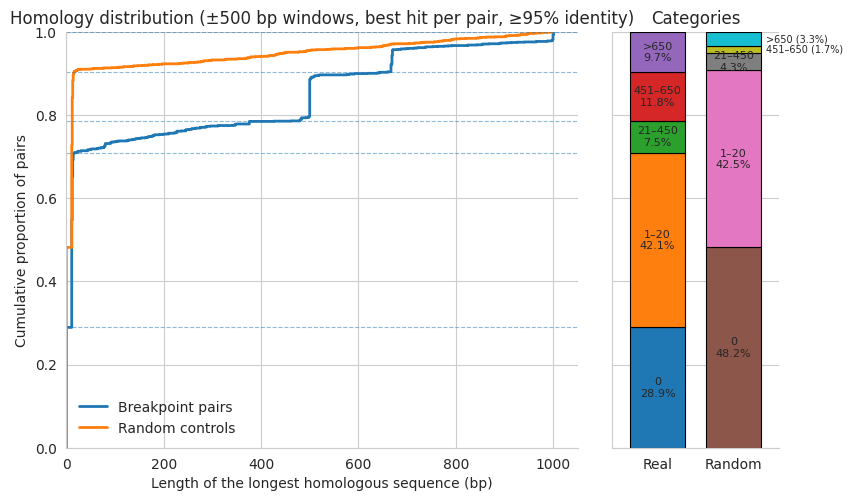

Saved figure to: /home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/ecdf_plus_vertical_stacked_bar_real_vs_random.png


In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ============================================================
# INPUTS
# ============================================================

MERGED_TSV = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/real_vs_random_merged.tsv"
OUT_PNG = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/ecdf_plus_vertical_stacked_bar_real_vs_random.png"

THRESHOLDS = [20, 450, 650]
HW = 500

# ============================================================
# HELPERS
# ============================================================

def make_labels(thresholds):
    labels = ["0"]
    prev = 0
    for t in thresholds:
        labels.append(f"{prev+1}–{t}")
        prev = t
    labels.append(f">{thresholds[-1]}")
    return labels

def categorize_length(x, thresholds):
    x = int(x)
    if x == 0:
        return "0"
    prev = 0
    for t in thresholds:
        if prev < x <= t:
            return f"{prev+1}–{t}"
        prev = t
    return f">{thresholds[-1]}"

def summarize_lengths(lengths, thresholds):
    labels = make_labels(thresholds)
    df = pd.DataFrame({"best_length": lengths})
    df["category"] = df["best_length"].apply(lambda x: categorize_length(x, thresholds))

    summary = (
        df["category"]
        .value_counts()
        .reindex(labels, fill_value=0)
        .reset_index()
    )
    summary.columns = ["category", "n_pairs"]
    summary["percentage"] = 100 * summary["n_pairs"] / len(df)
    summary["fraction"] = summary["n_pairs"] / len(df)
    return df, summary

# ============================================================
# LOAD
# ============================================================

merged = pd.read_csv(MERGED_TSV, sep="\t")

merged["best_length_real"] = pd.to_numeric(
    merged["best_length_real"], errors="coerce"
).fillna(0).astype(int)

merged["best_length_random"] = pd.to_numeric(
    merged["best_length_random"], errors="coerce"
).fillna(0).astype(int)

df_real, summary_real = summarize_lengths(merged["best_length_real"], THRESHOLDS)
df_random, summary_random = summarize_lengths(merged["best_length_random"], THRESHOLDS)

print("Real:")
print(summary_real)
print("\nRandom:")
print(summary_random)

# ============================================================
# PLOT
# ============================================================

sns.set_style("whitegrid")

fig = plt.figure(figsize=(9.2, 5.4))
gs = GridSpec(1, 2, width_ratios=[5.8, 1.9], wspace=0.10)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)

# ------------------------------------------------------------
# LEFT: ECDF real vs random
# ------------------------------------------------------------

sns.ecdfplot(
    data=df_real,
    x="best_length",
    linewidth=2,
    label="Breakpoint pairs",
    ax=ax1
)

sns.ecdfplot(
    data=df_random,
    x="best_length",
    linewidth=2,
    label="Random controls",
    ax=ax1
)

ax1.set_xlabel("Length of the longest homologous sequence (bp)")
ax1.set_ylabel("Cumulative proportion of pairs")
ax1.set_title(f"Homology distribution (±{HW} bp windows, best hit per pair, ≥95% identity)")
ax1.set_xlim(left=0)
ax1.set_ylim(0, 1)
ax1.legend(frameon=False)

cum = 0
for _, row in summary_real.iterrows():
    cum += row["fraction"]
    ax1.axhline(cum, linestyle="--", linewidth=0.8, alpha=0.5)

# ------------------------------------------------------------
# RIGHT: vertical stacked bars, real + random
# ------------------------------------------------------------

x_positions = [0, 1]
bar_names = ["Real", "Random"]

for bar_x, summary in zip(x_positions, [summary_real, summary_random]):
    bottom = 0
    for _, row in summary.iterrows():
        h = row["fraction"]

        ax2.bar(
            x=bar_x,
            height=h,
            bottom=bottom,
            width=0.72,
            edgecolor="black",
            linewidth=0.8
        )

        ymid = bottom + h / 2

        if h >= 0.04:
            ax2.text(
                bar_x,
                ymid,
                f"{row['category']}\n{row['percentage']:.1f}%",
                ha="center",
                va="center",
                fontsize=8
            )
        else:
            ax2.text(
                bar_x + 0.42,
                ymid,
                f"{row['category']} ({row['percentage']:.1f}%)",
                ha="left",
                va="center",
                fontsize=7
            )

        bottom += h

ax2.set_xlim(-0.6, 1.6)
ax2.set_xticks(x_positions)
ax2.set_xticklabels(bar_names)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_title("Categories")

plt.setp(ax2.get_yticklabels(), visible=False)

for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {OUT_PNG}")

In [84]:
import pandas as pd

# ============================================================
# INPUT
# ============================================================

MERGED_TSV = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/real_vs_random_merged.tsv"

OUT_WIDE = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/for_R_wide.tsv"
OUT_LONG = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/for_R_long.tsv"
OUT_CATS = "/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/for_R_categories.tsv"

THRESHOLDS = [20, 450, 650]

# ============================================================
# HELPERS
# ============================================================

def categorize_length(x, thresholds):
    x = int(x)
    if x == 0:
        return "0"
    prev = 0
    for t in thresholds:
        if prev < x <= t:
            return f"{prev+1}–{t}"
        prev = t
    return f">{thresholds[-1]}"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(MERGED_TSV, sep="\t").copy()

df["best_length_real"] = pd.to_numeric(df["best_length_real"], errors="coerce").fillna(0).astype(int)
df["best_length_random"] = pd.to_numeric(df["best_length_random"], errors="coerce").fillna(0).astype(int)

# ============================================================
# WIDE
# ============================================================

wide = df.copy()
wide["category_real"] = wide["best_length_real"].apply(lambda x: categorize_length(x, THRESHOLDS))
wide["category_random"] = wide["best_length_random"].apply(lambda x: categorize_length(x, THRESHOLDS))

wide.to_csv(OUT_WIDE, sep="\t", index=False)

# ============================================================
# LONG
# ============================================================

long = pd.concat([
    wide[[
        "pair_id", "plasmid", "plasmid_len",
        "bp_start_pos", "bp_end_pos",
        "random_start_pos", "random_end_pos",
        "best_length_real"
    ]].rename(columns={"best_length_real": "best_length"}).assign(condition="real"),

    wide[[
        "pair_id", "plasmid", "plasmid_len",
        "bp_start_pos", "bp_end_pos",
        "random_start_pos", "random_end_pos",
        "best_length_random"
    ]].rename(columns={"best_length_random": "best_length"}).assign(condition="random")
], ignore_index=True)

long["category"] = long["best_length"].apply(lambda x: categorize_length(x, THRESHOLDS))
long.to_csv(OUT_LONG, sep="\t", index=False)

# ============================================================
# CATEGORY SUMMARY
# ============================================================

cats = (
    long.groupby(["condition", "category"])
        .size()
        .reset_index(name="n_pairs")
)

totals = (
    long.groupby("condition")
        .size()
        .reset_index(name="total_pairs")
)

cats = cats.merge(totals, on="condition", how="left")
cats["fraction"] = cats["n_pairs"] / cats["total_pairs"]
cats["percentage"] = 100 * cats["fraction"]

cats.to_csv(OUT_CATS, sep="\t", index=False)

print("Wrote:")
print(OUT_WIDE)
print(OUT_LONG)
print(OUT_CATS)

Wrote:
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/for_R_wide.tsv
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/for_R_long.tsv
/home/nacho/HDD16/Nacho/RepliCOOC/derep/uniones_entre_plasmidos/V3/TRACEABLE_hardcut_95pid_500_onebest_per_pair/random_control_two_random_points/for_R_categories.tsv
